# **Imports and Initialization**

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import random

In [63]:
random.seed(0)
np.random.seed(0)

In [64]:
import os
os.environ['PYTHONHASHSEED'] = '0'

In [65]:
import tensorflow as tf
tf.random.set_seed(0)
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [66]:
path = kagglehub.dataset_download("shubhamvashisht/hourly-load-india-electrical-load-forecasting")

In [67]:
hourly_load = pd.read_excel(path+'/hourlyLoadDataIndia.xlsx')

In [68]:
monthly_temp = pd.read_excel(path+'/monthly_temp.xlsx')

# **EDA - Part I**

In [69]:
hourly_load.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46728 entries, 0 to 46727
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   datetime                            46728 non-null  datetime64[ns]
 1   National Hourly Demand              46728 non-null  float64       
 2   Northen Region Hourly Demand        46728 non-null  float64       
 3   Western Region Hourly Demand        46728 non-null  float64       
 4   Eastern Region Hourly Demand        46728 non-null  float64       
 5   Southern Region Hourly Demand       46728 non-null  float64       
 6   North-Eastern Region Hourly Demand  46728 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 2.5 MB


In [70]:
hourly_load.head(2)

,datetime,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand
0,2019-01-01 00:00:00,118690.67,33692.02,38522.22,13128.89,31681.83,1665.72
1,2019-01-01 01:00:00,116029.23,32534.39,38071.09,12737.53,31129.97,1556.24


In [71]:
hourly_load.isnull().sum()

datetime                              0
National Hourly Demand                0
Northen Region Hourly Demand          0
Western Region Hourly Demand          0
Eastern Region Hourly Demand          0
Southern Region Hourly Demand         0
North-Eastern Region Hourly Demand    0
dtype: int64

In [72]:
hourly_load[hourly_load.duplicated()]

,datetime,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand


In [73]:
(hourly_load.drop('datetime',axis=1)).describe()

,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand
count,46728.000000,46728.000000,46728.000000,46728.000000,46728.000000,46728.00000
mean,160487.065667,47914.796244,50402.921233,18572.519716,41589.467904,2007.36047
std,23103.574609,10502.892378,7995.619137,3329.680794,7466.994359,436.58010
min,95336.560000,19217.760000,28111.220000,9259.820000,23188.920000,567.00000
25%,145338.782500,40165.942500,44272.367500,16107.155000,36156.870000,1689.17750
50%,159541.060000,47523.690000,50036.970000,18427.610000,40681.885000,1968.65000
75%,176633.607500,55012.182500,56100.490000,20828.360000,46101.767500,2290.20250
max,237361.970000,80793.890000,73015.180000,28856.630000,68207.940000,3586.43000


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode

a = hourly_load.melt(
    id_vars='datetime',
    value_vars=['National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand'],
    var_name='metric',
    value_name='value'
)

fig = px.line(a, x='datetime', y='value', color='metric', title='Hourly Load by Region')
fig.update_layout(
    xaxis_title='Timestamp',
    yaxis_title='Value',
    legend_title='Metric'
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()


In [265]:
# Feature Engineering to understand seasonal trends
df = hourly_load.copy()
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour']=df['datetime'].dt.hour
df['day of week'] = df['datetime'].dt.dayofweek

def get_season(month):
    if month in [12, 1, 2]: return "Winter"
    elif month in [3, 4, 5]: return "Spring"
    elif month in [6, 7, 8]: return "Summer"
    else: return "Autumn"

df['Season'] = df['month'].apply(get_season)


## **National Trends**

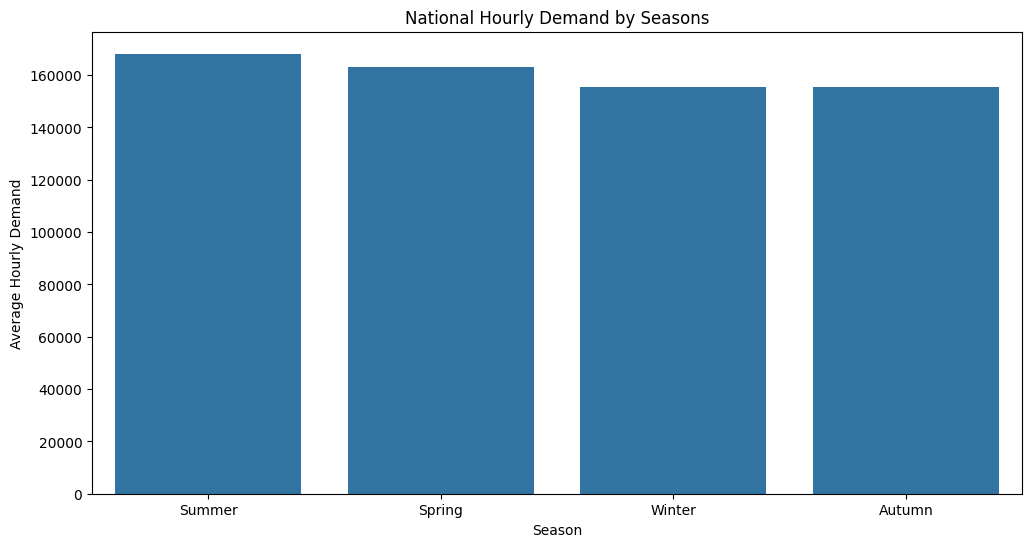

In [76]:
season_poll = df.groupby('Season')['National Hourly Demand'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=season_poll.index, y=season_poll.values)
plt.title('National Hourly Demand by Seasons')
plt.ylabel('Average Hourly Demand')
plt.show()


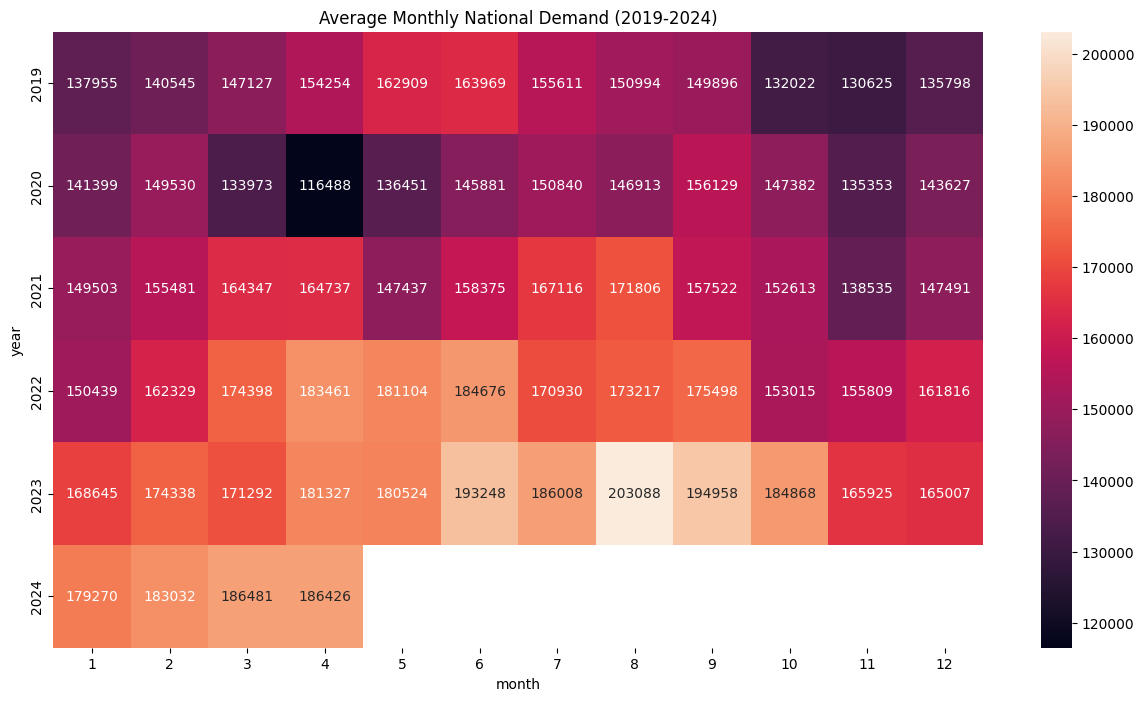

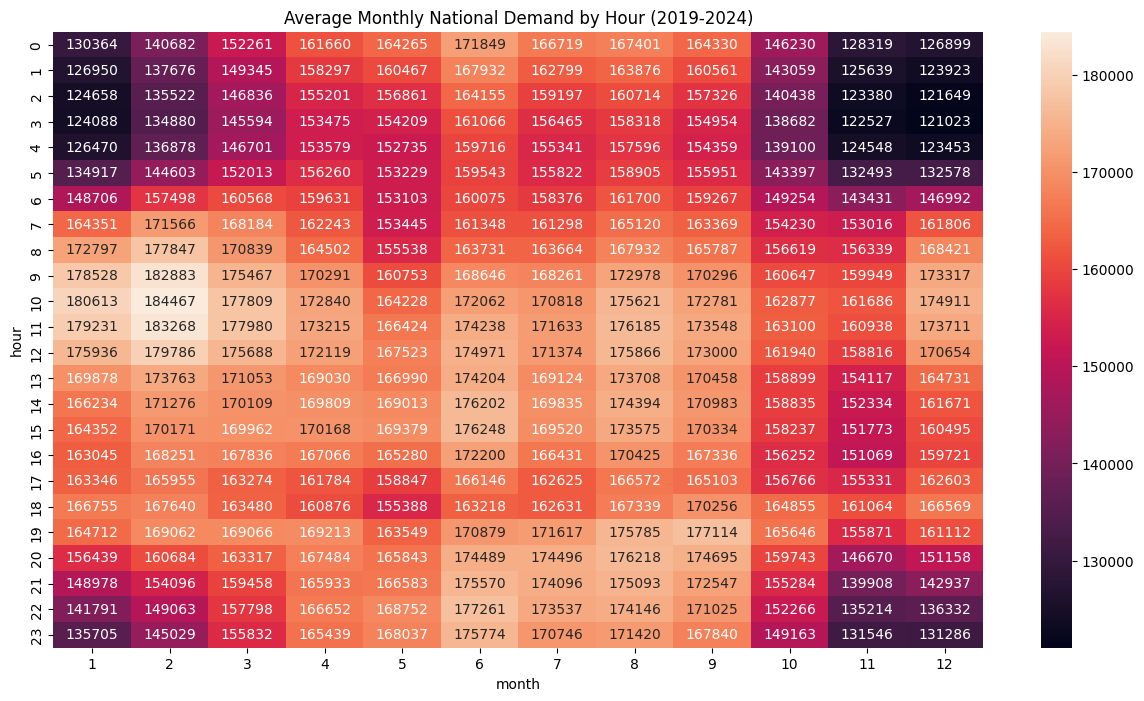

In [77]:
plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['year', 'month'])['National Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly National Demand (2019-2024)')
plt.show()

plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['hour','month'])['National Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly National Demand by Hour (2019-2024)')
plt.show()

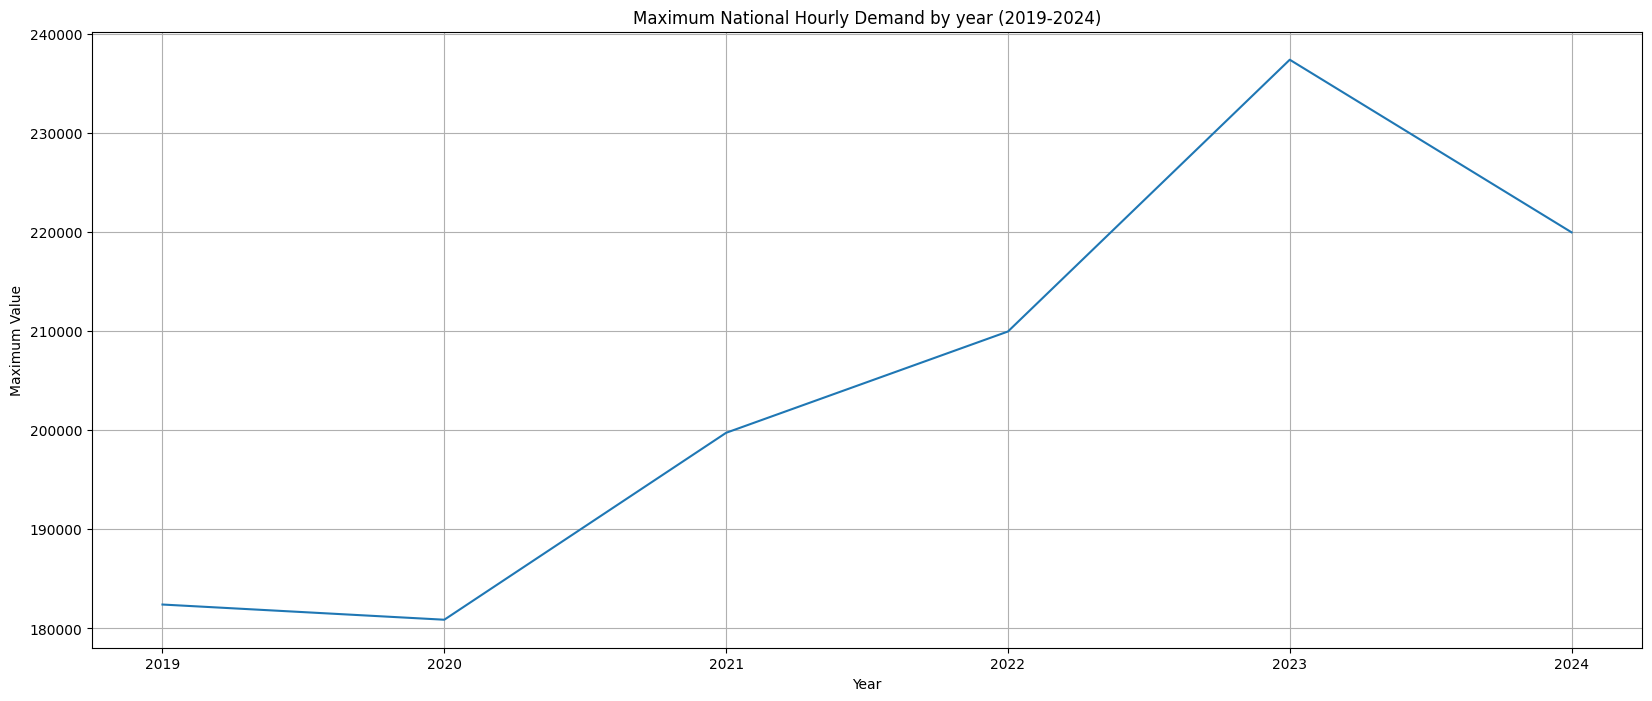

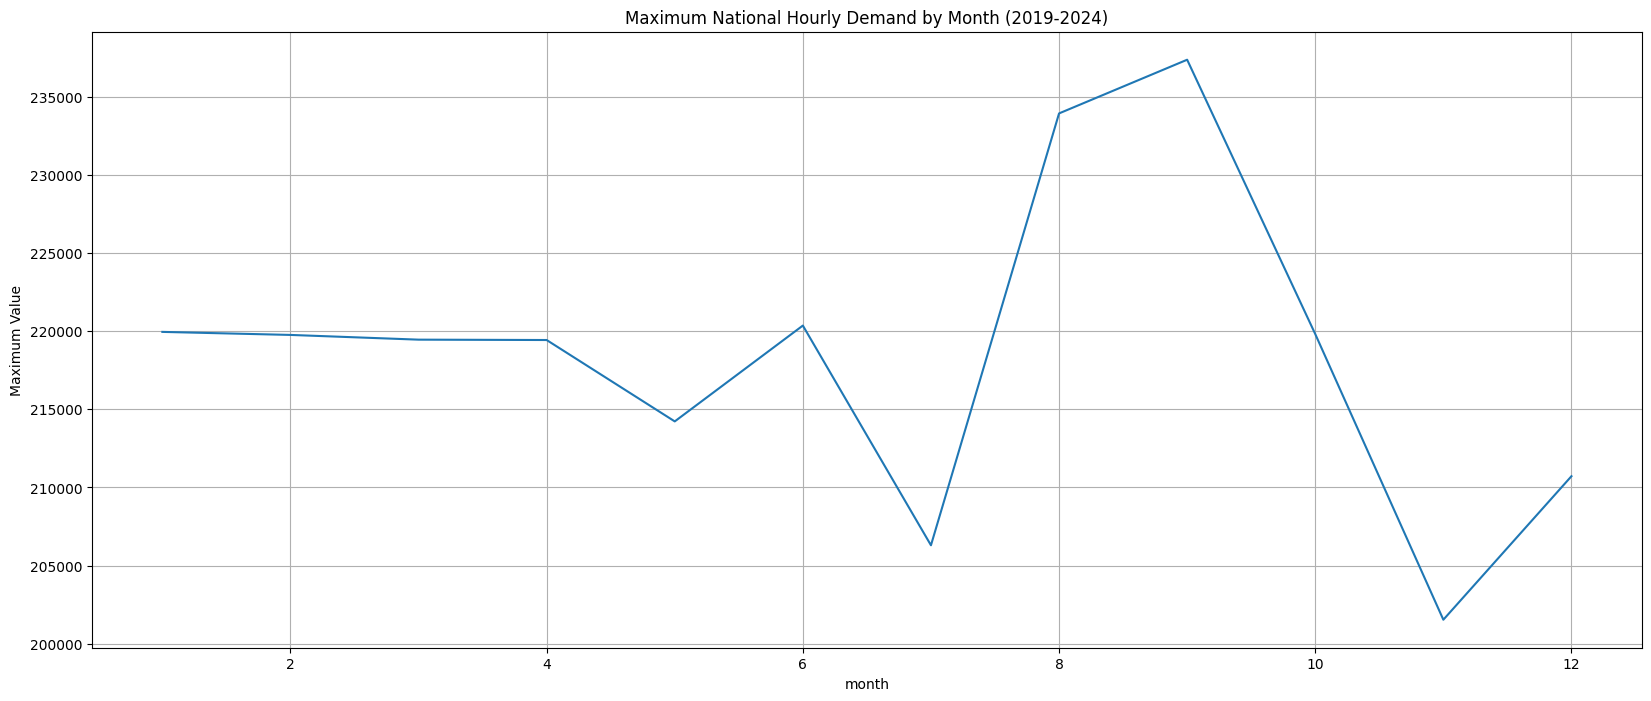

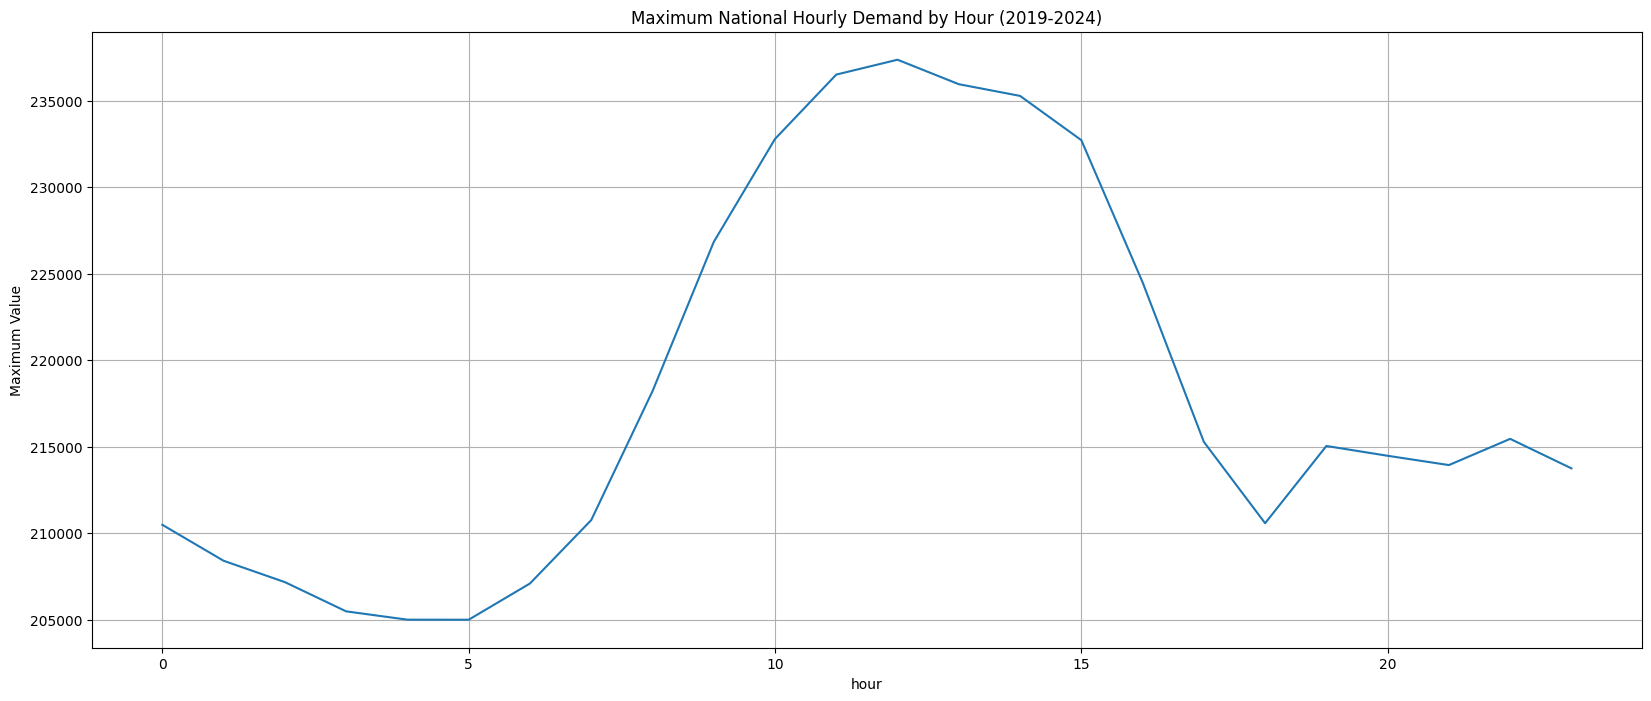

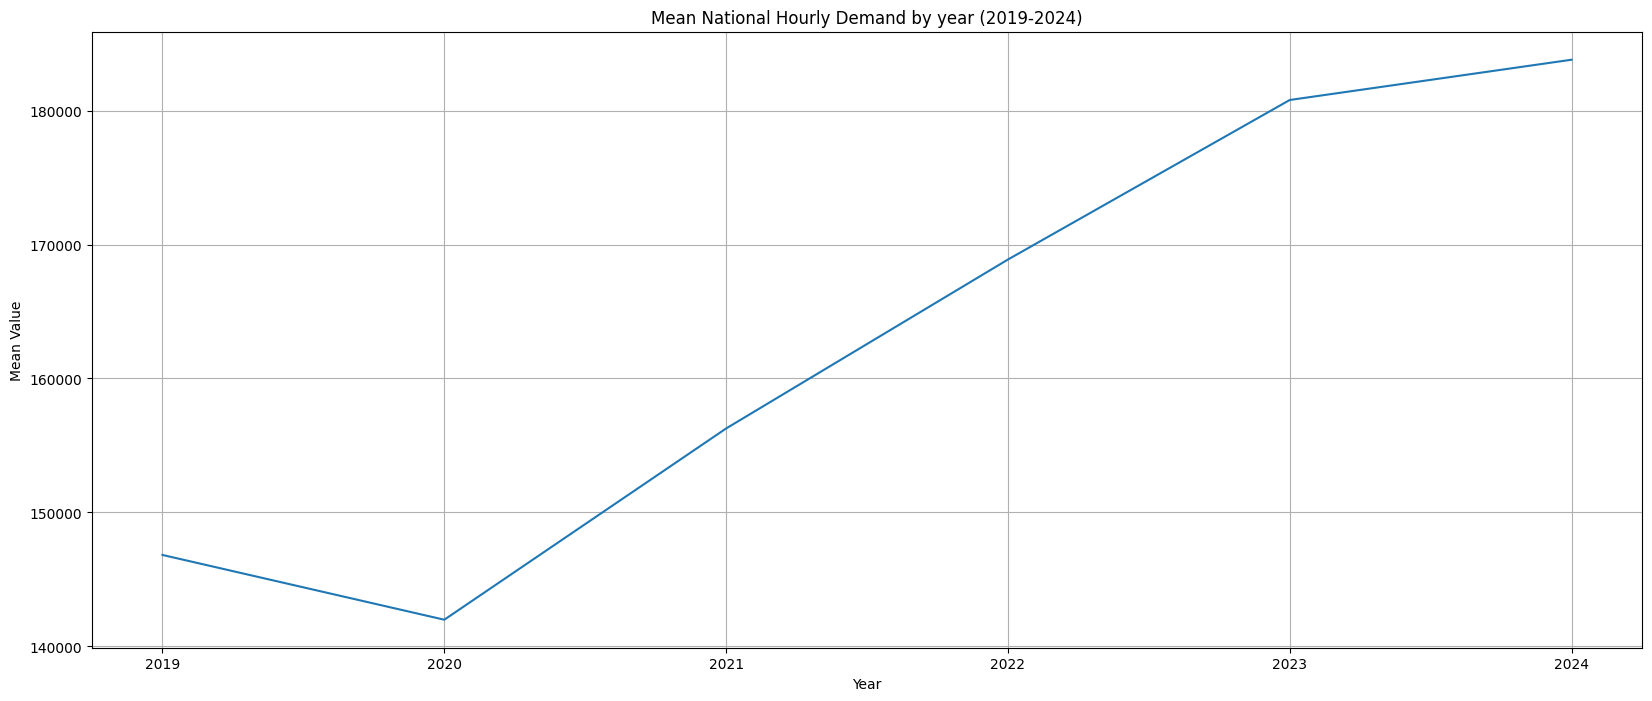

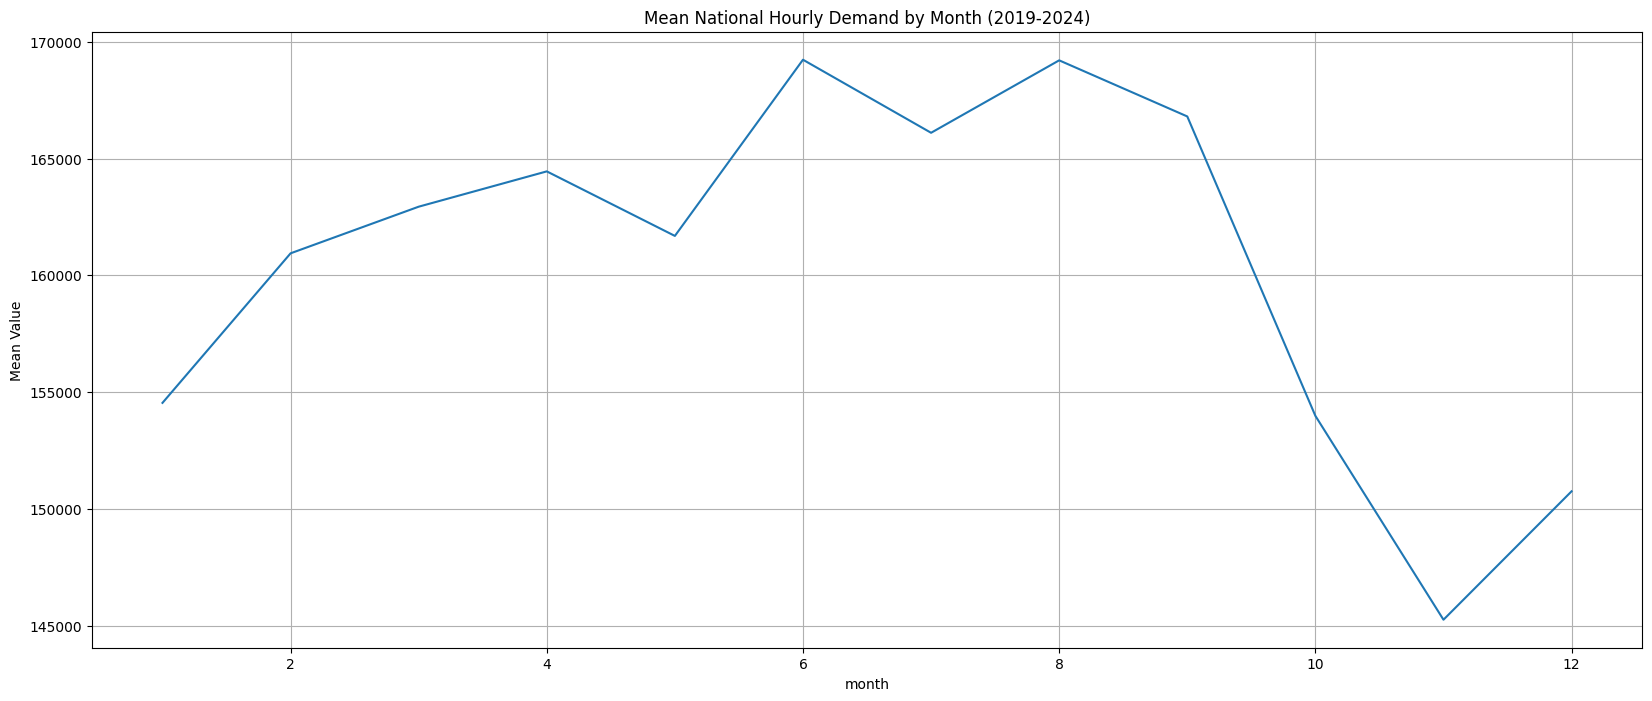

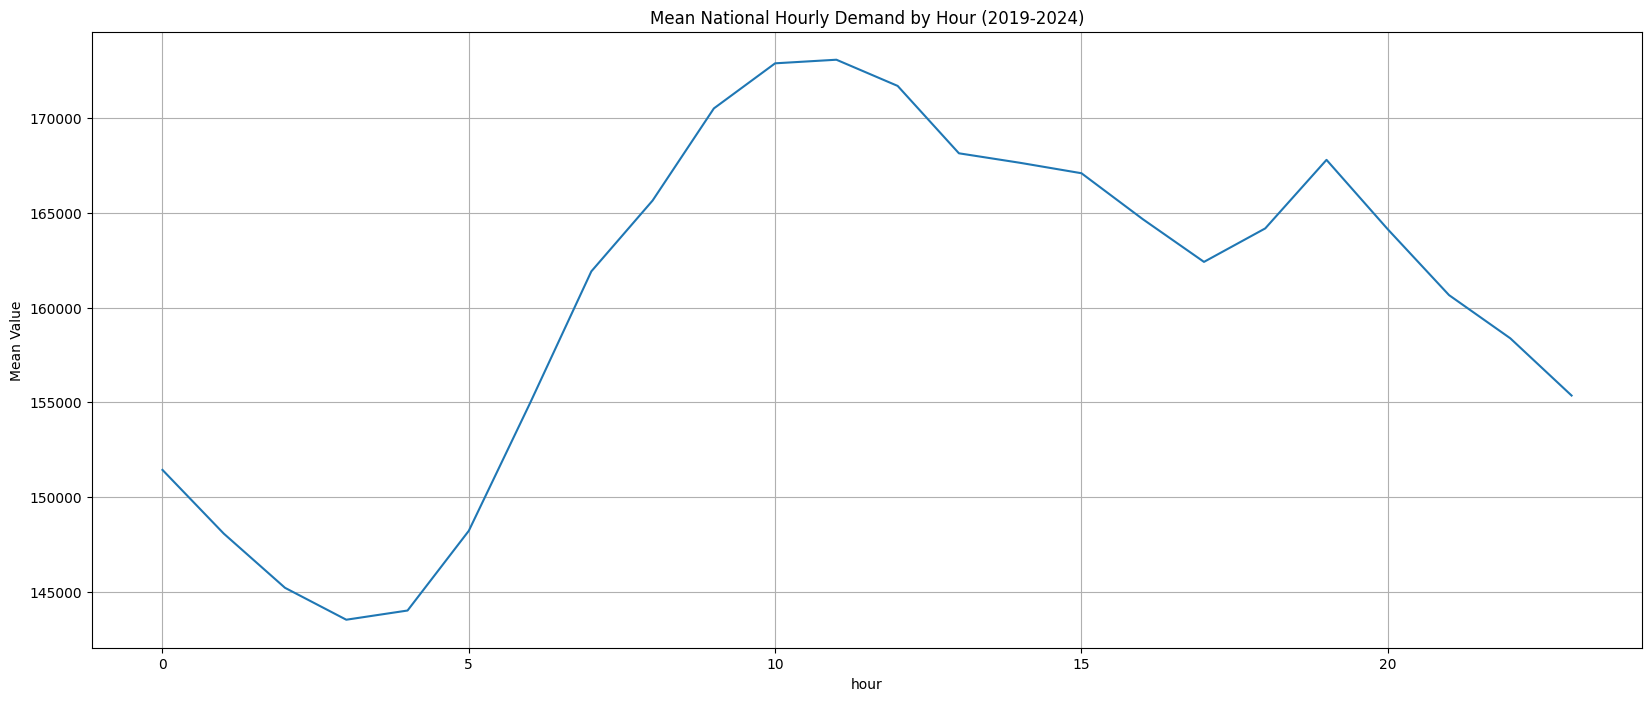

In [78]:
plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['National Hourly Demand'].max())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Maximum Value')
plt.title('Maximum National Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['National Hourly Demand'].max())
plt.grid()
plt.xlabel('month')
plt.ylabel('Maximum Value')
plt.title('Maximum National Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['National Hourly Demand'].max())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Maximum Value')
plt.title('Maximum National Hourly Demand by Hour (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['National Hourly Demand'].mean())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.title('Mean National Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['National Hourly Demand'].mean())
plt.grid()
plt.xlabel('month')
plt.ylabel('Mean Value')
plt.title('Mean National Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['National Hourly Demand'].mean())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Mean Value')
plt.title('Mean National Hourly Demand by Hour (2019-2024)')
plt.show()



## **Northern Region Trends**

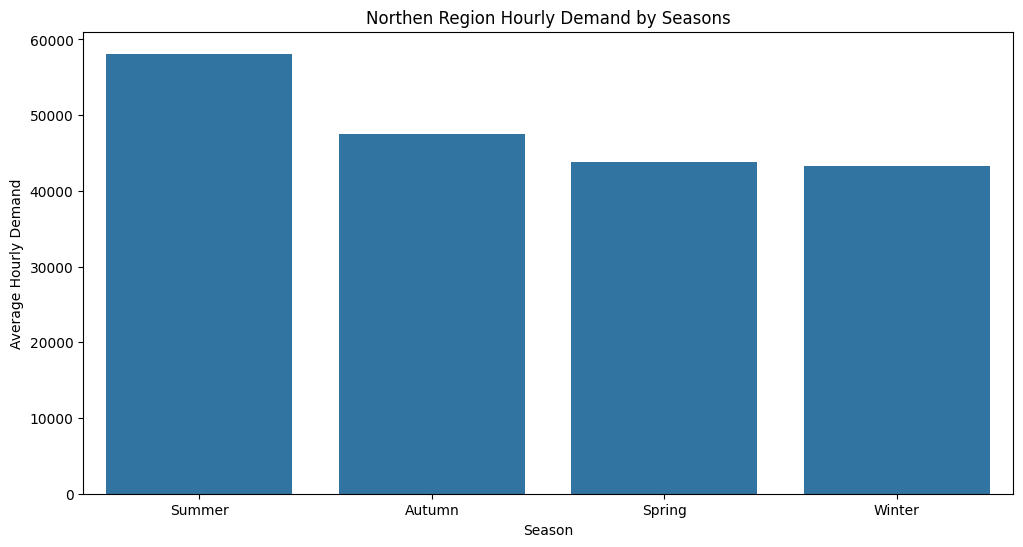

In [79]:
season_poll = df.groupby('Season')['Northen Region Hourly Demand'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=season_poll.index, y=season_poll.values)
plt.title('Northen Region Hourly Demand by Seasons')
plt.ylabel('Average Hourly Demand')
plt.show()


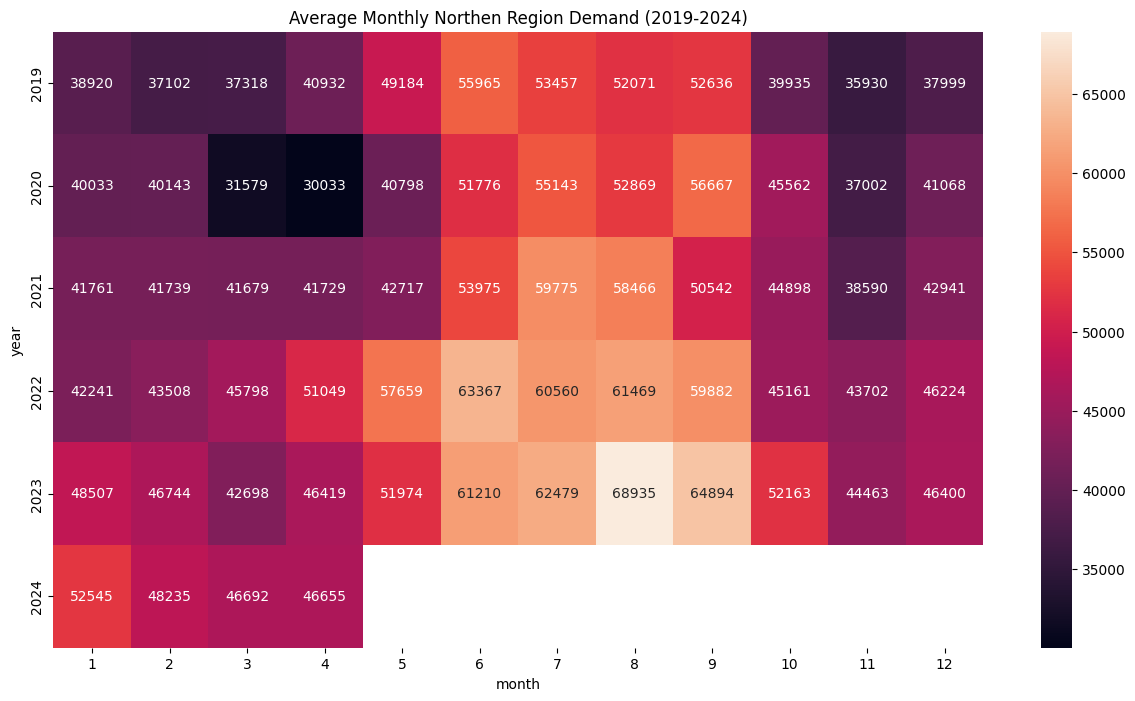

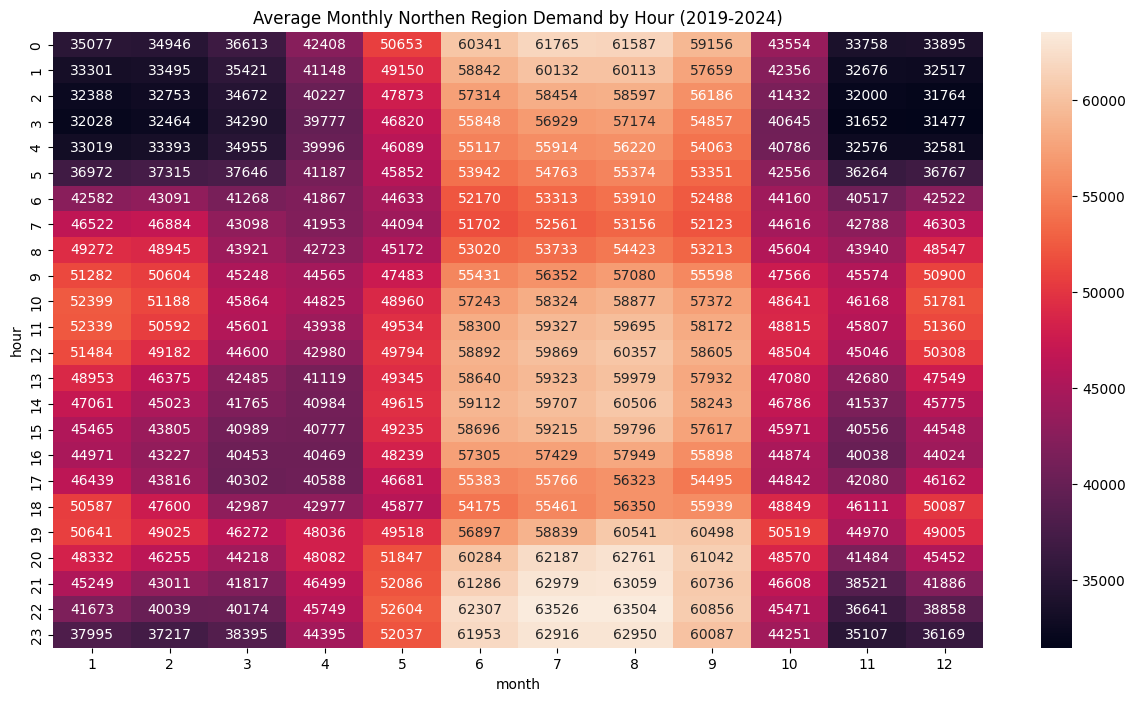

In [80]:
plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['year', 'month'])['Northen Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Northen Region Demand (2019-2024)')
plt.show()

plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['hour','month'])['Northen Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Northen Region Demand by Hour (2019-2024)')
plt.show()

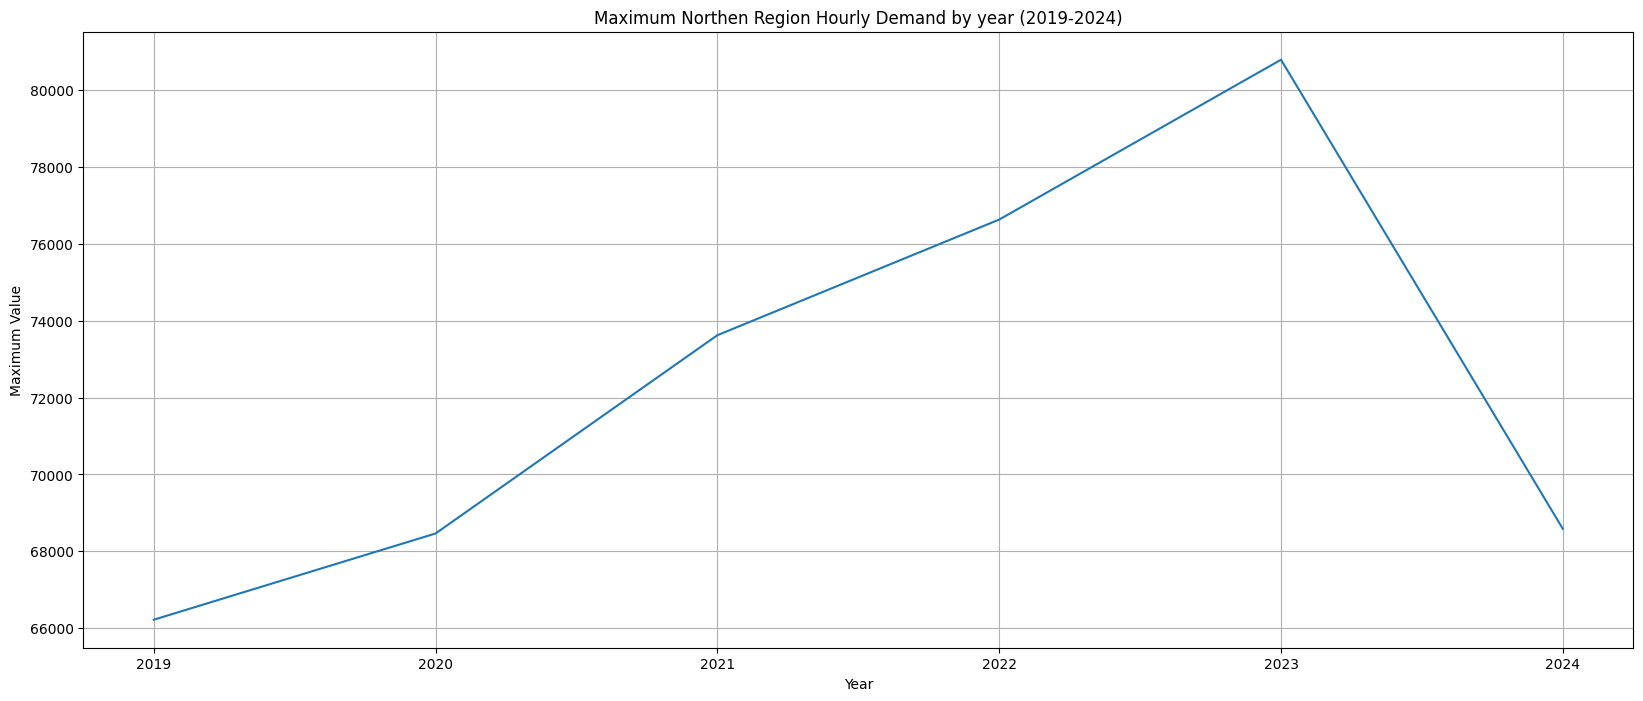

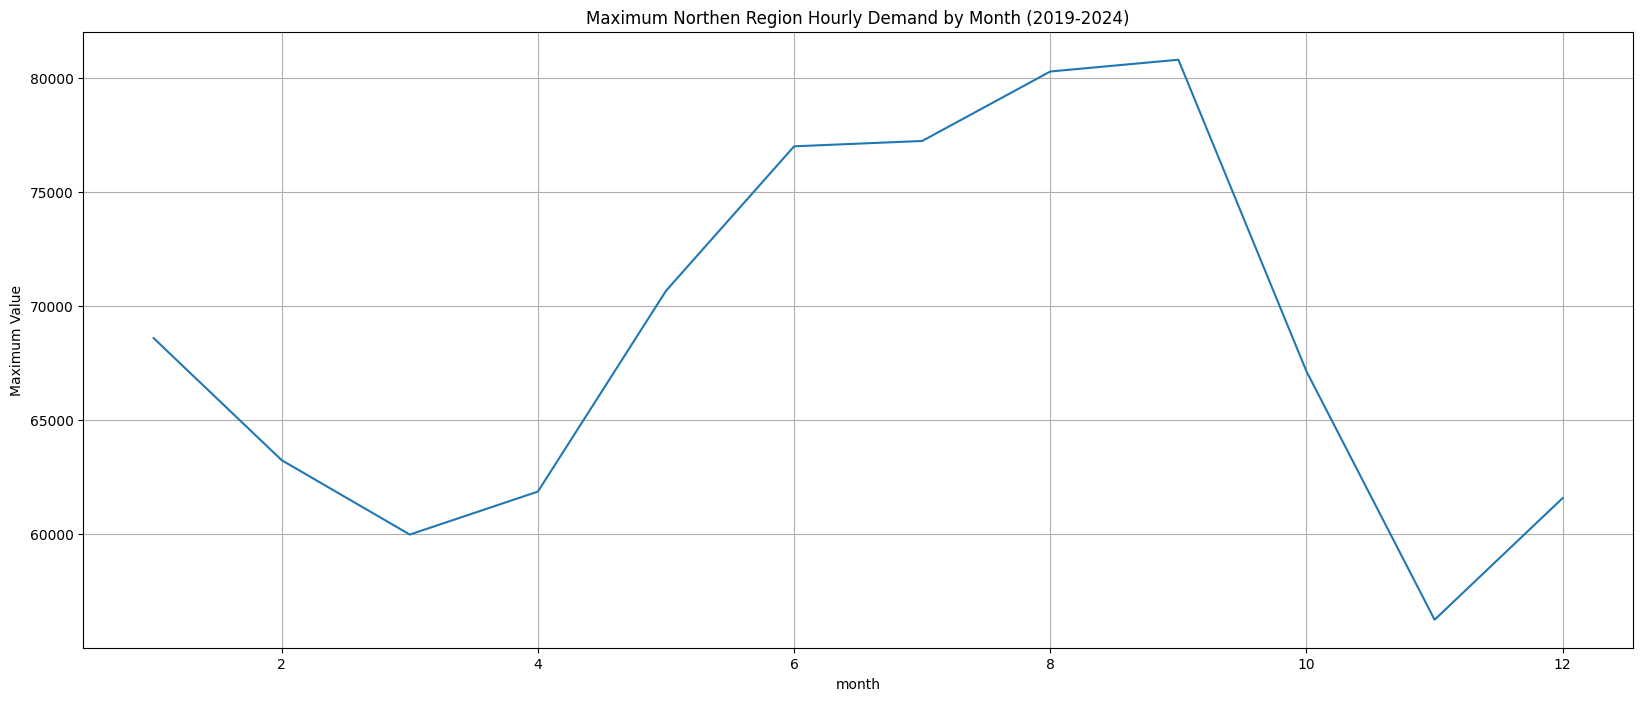

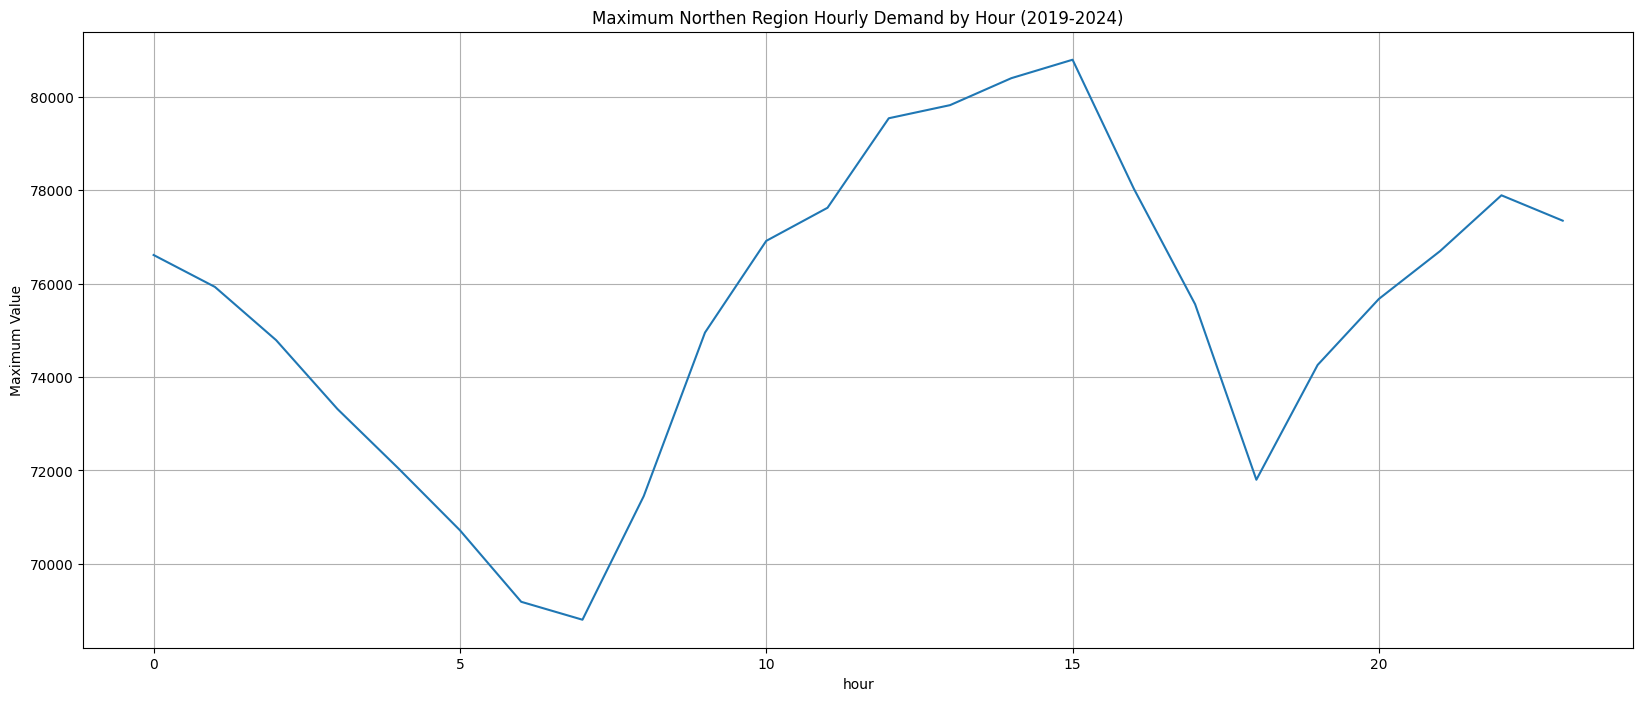

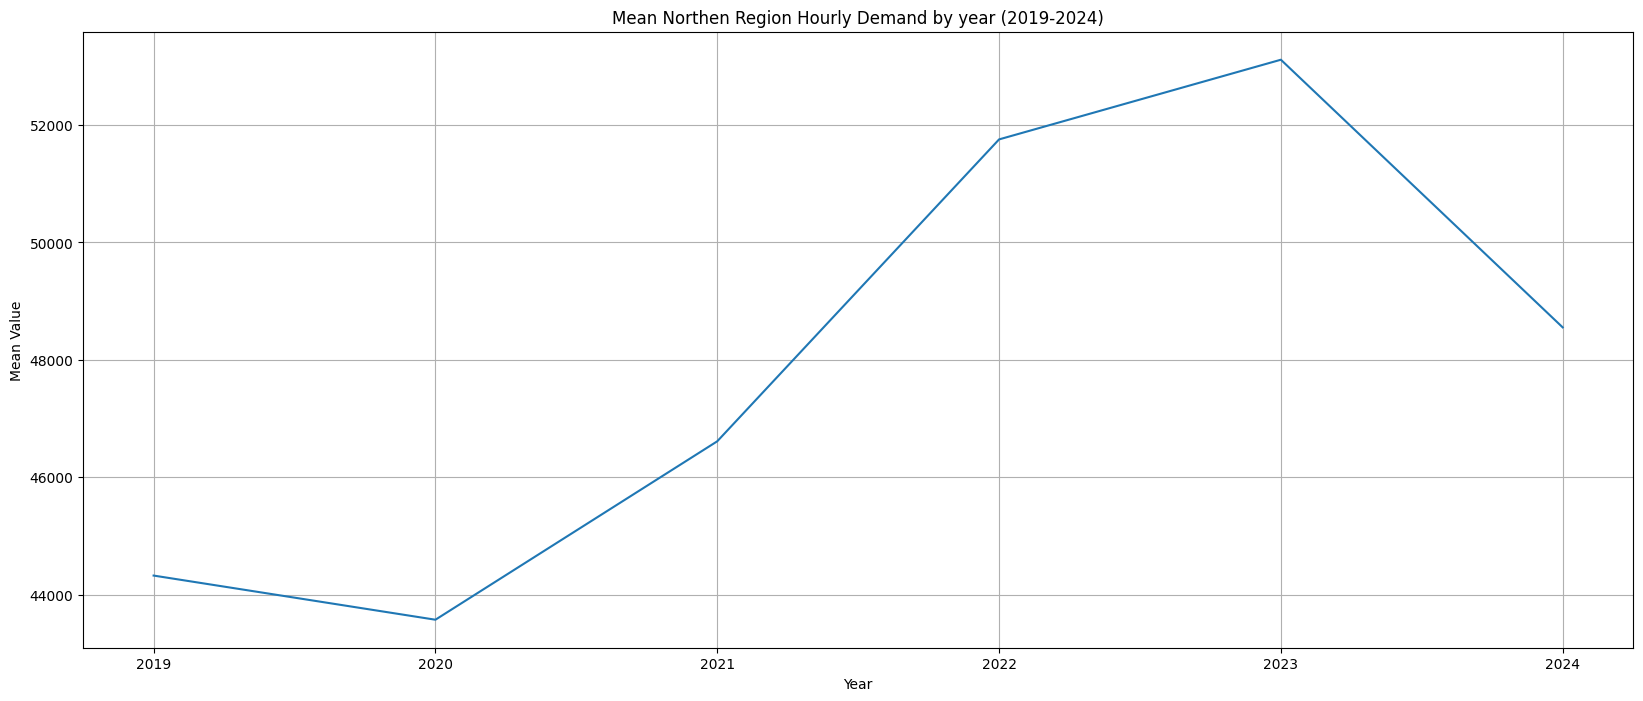

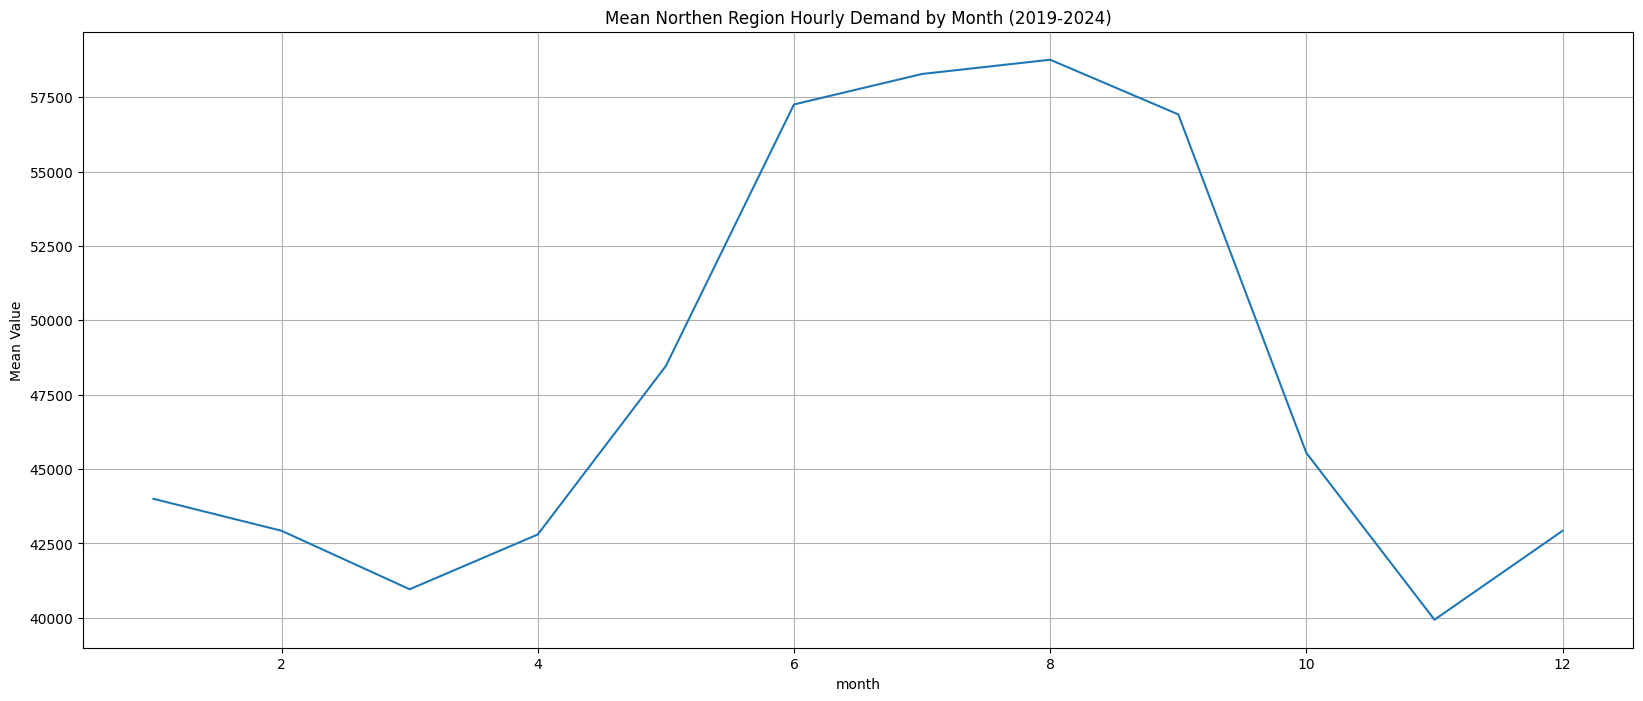

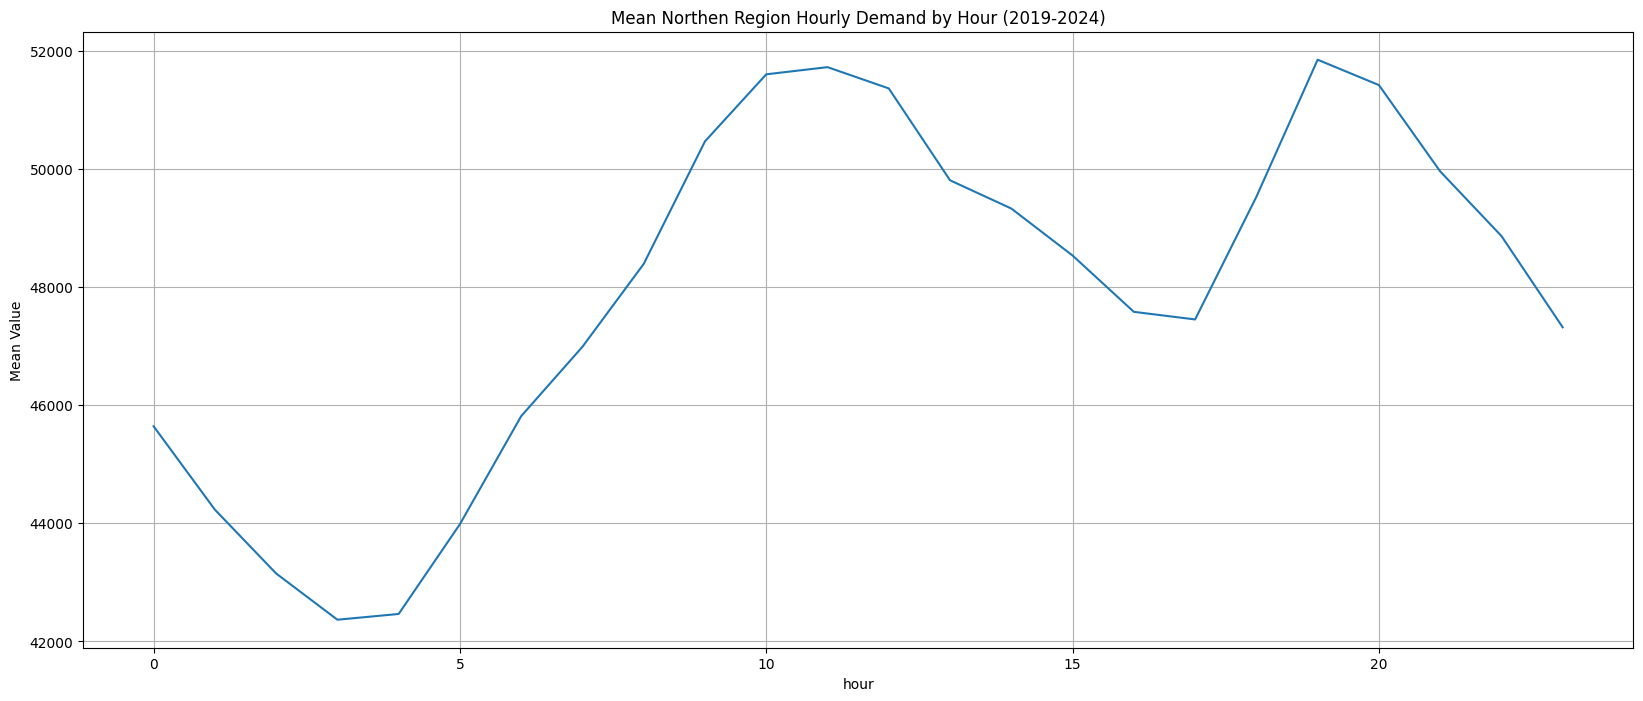

In [81]:
plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Northen Region Hourly Demand'].max())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Maximum Value')
plt.title('Maximum Northen Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Northen Region Hourly Demand'].max())
plt.grid()
plt.xlabel('month')
plt.ylabel('Maximum Value')
plt.title('Maximum Northen Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Northen Region Hourly Demand'].max())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Maximum Value')
plt.title('Maximum Northen Region Hourly Demand by Hour (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Northen Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.title('Mean Northen Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Northen Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('month')
plt.ylabel('Mean Value')
plt.title('Mean Northen Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Northen Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Mean Value')
plt.title('Mean Northen Region Hourly Demand by Hour (2019-2024)')
plt.show()



## **Southern Region Trends**

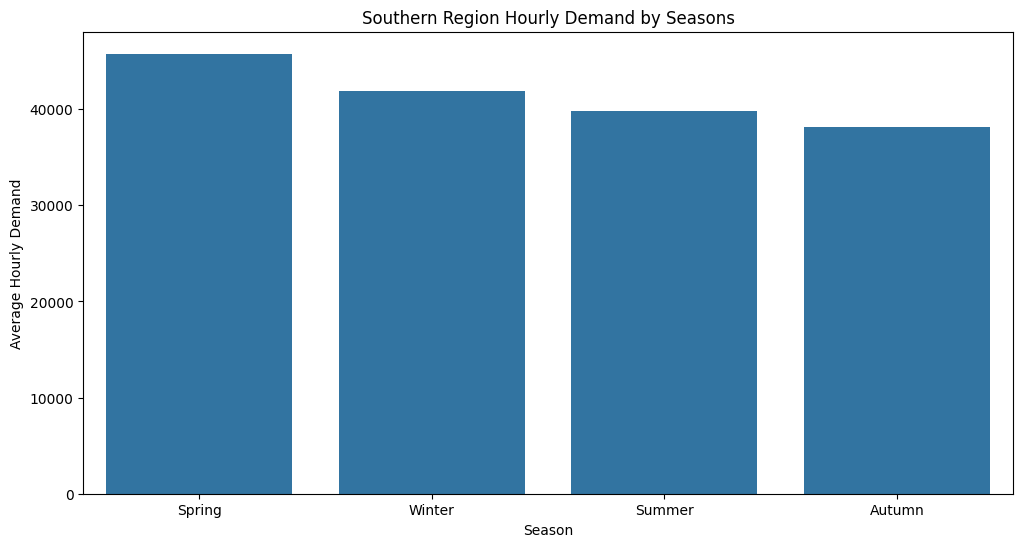

In [82]:
season_poll = df.groupby('Season')['Southern Region Hourly Demand'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=season_poll.index, y=season_poll.values)
plt.title('Southern Region Hourly Demand by Seasons')
plt.ylabel('Average Hourly Demand')
plt.show()


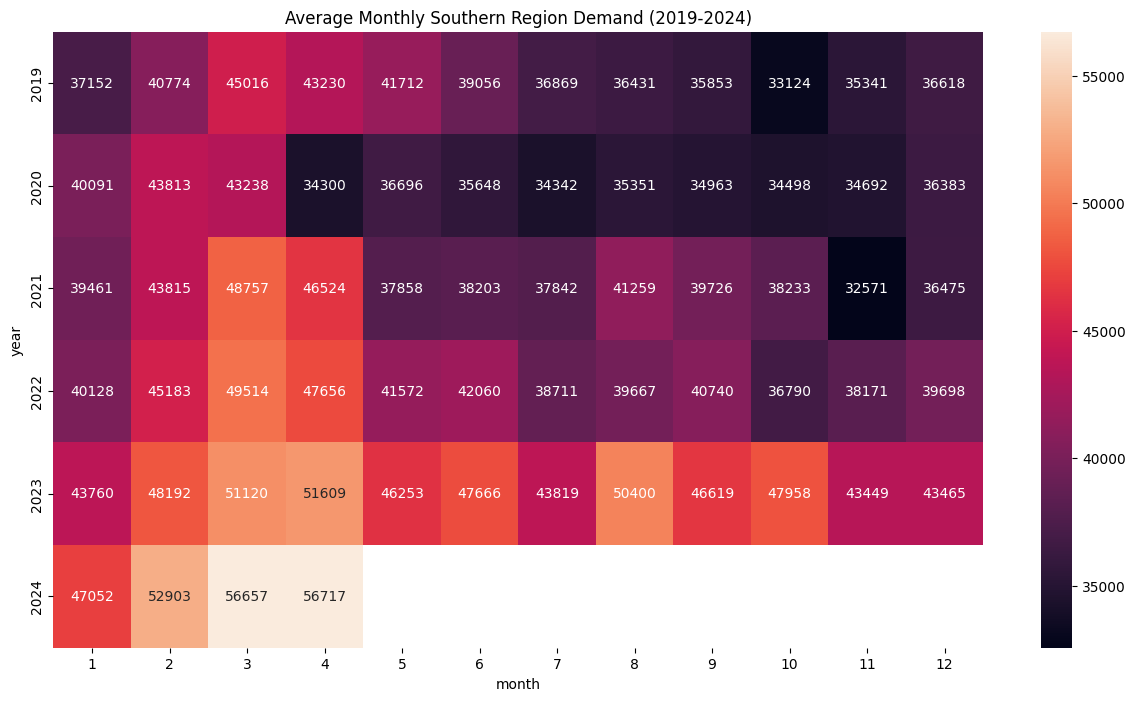

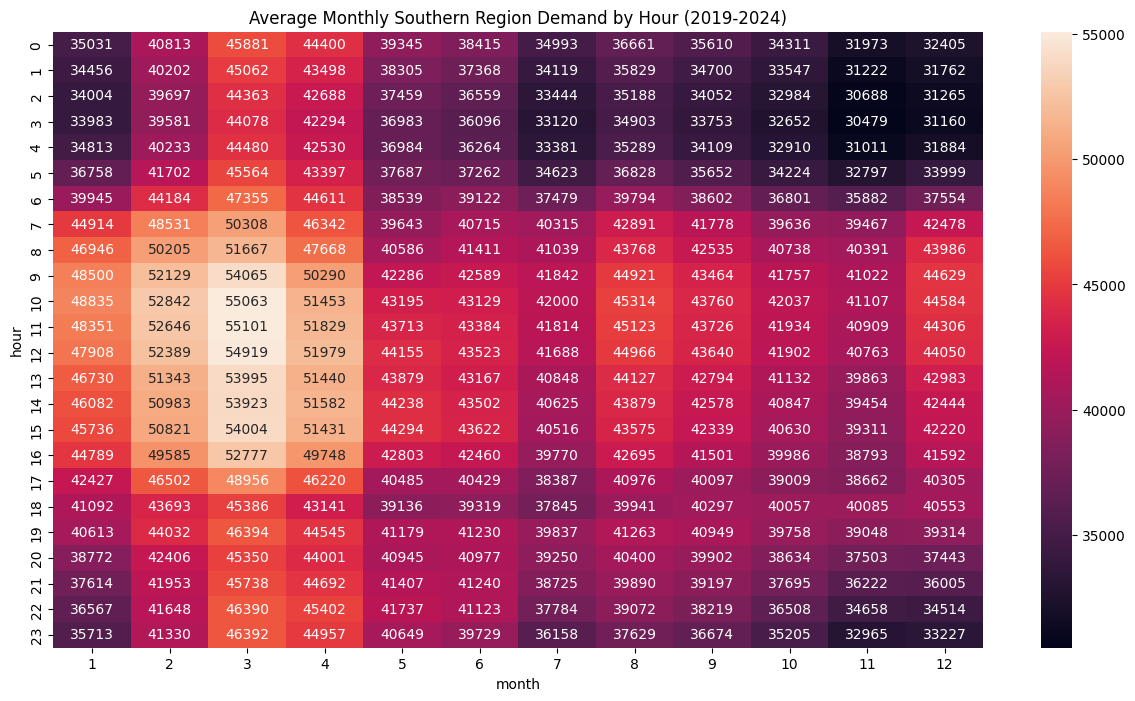

In [83]:
plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['year', 'month'])['Southern Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Southern Region Demand (2019-2024)')
plt.show()

plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['hour','month'])['Southern Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Southern Region Demand by Hour (2019-2024)')
plt.show()

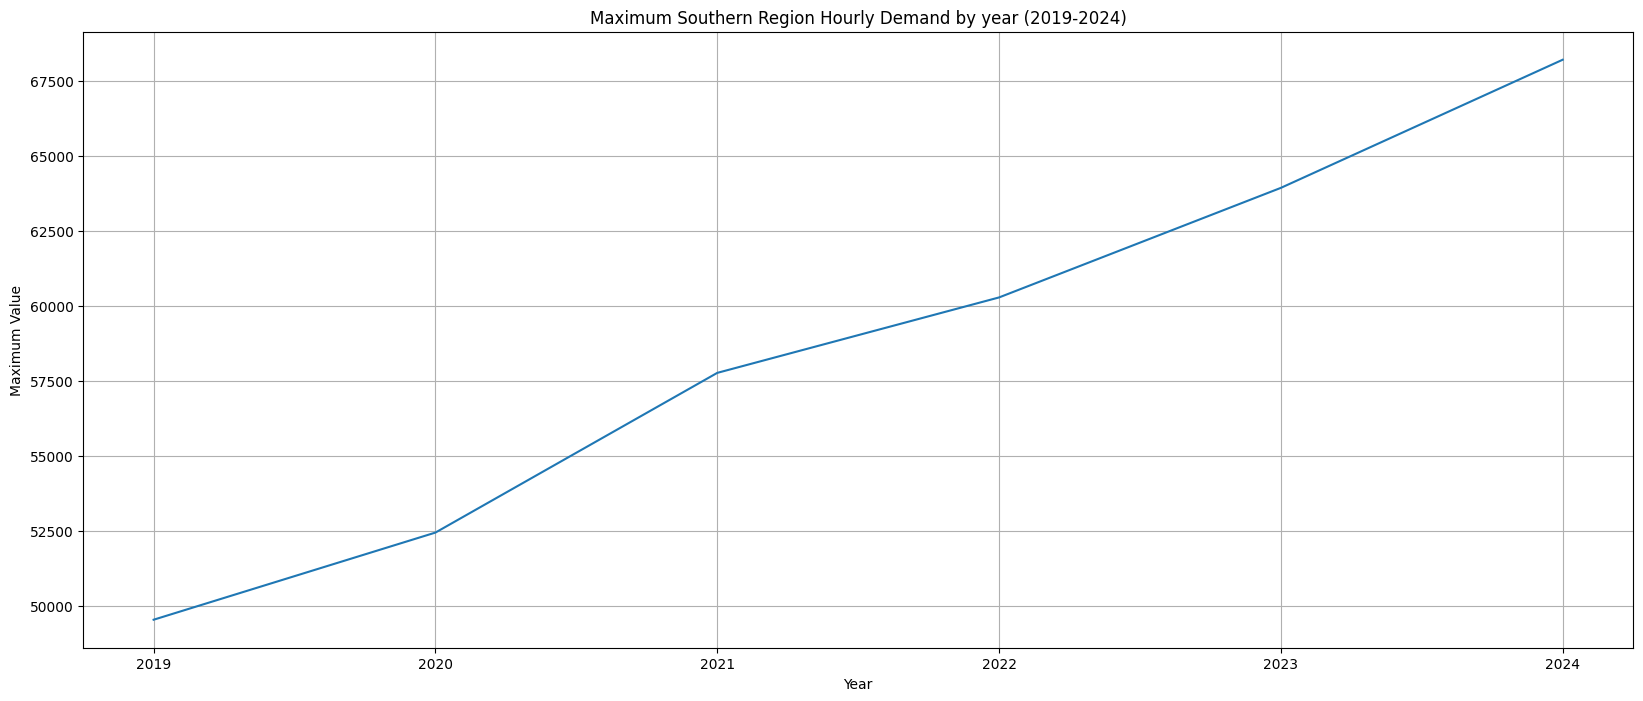

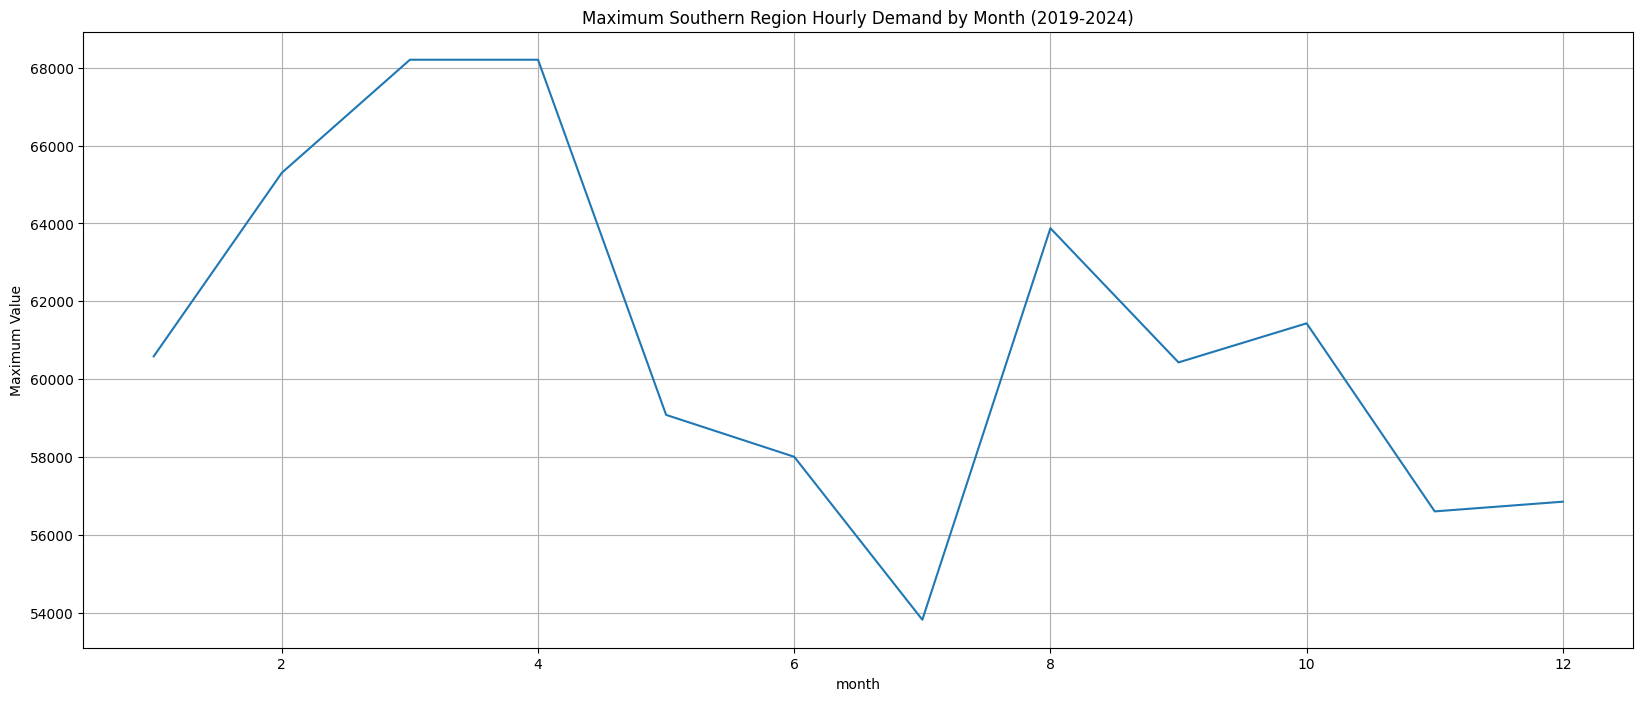

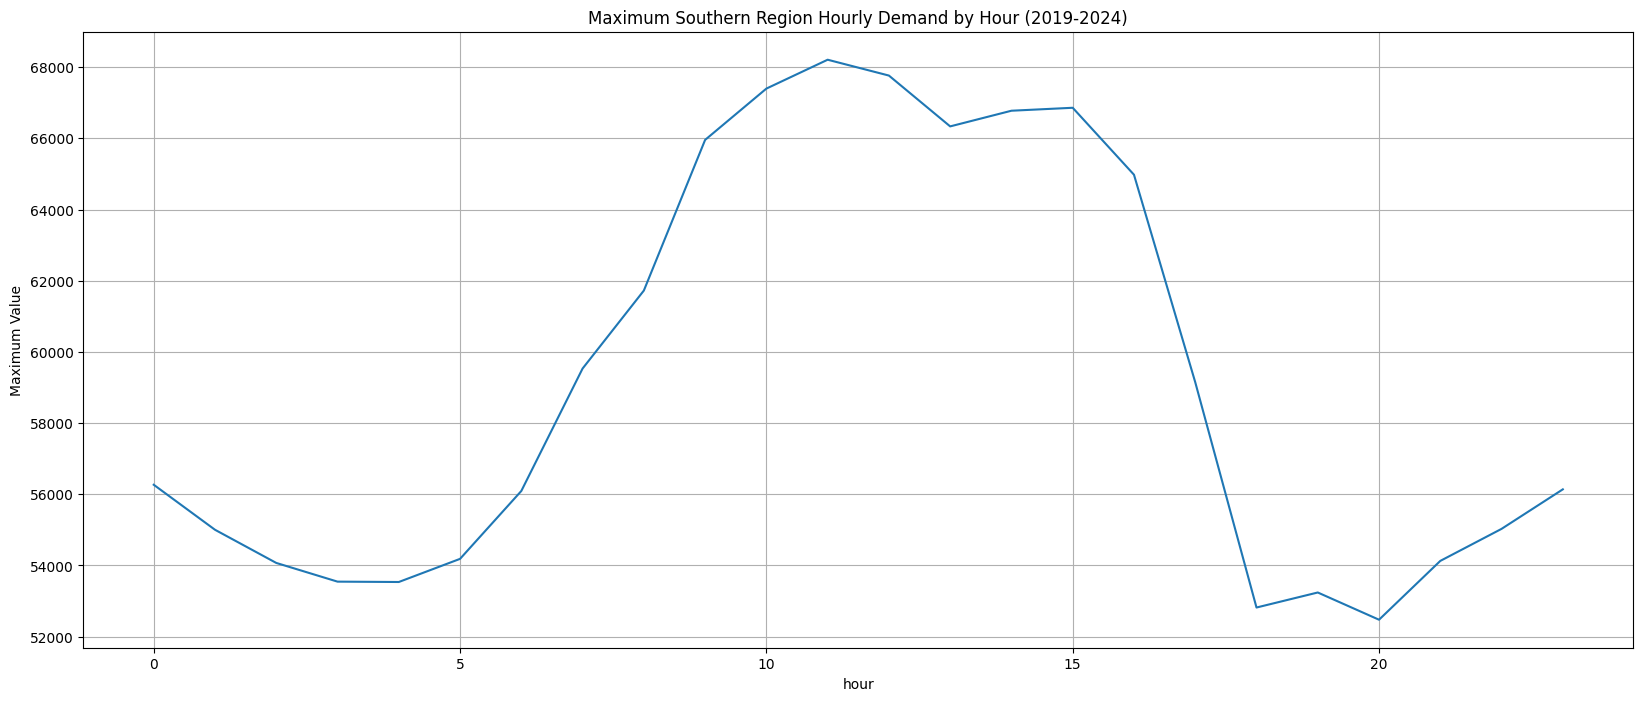

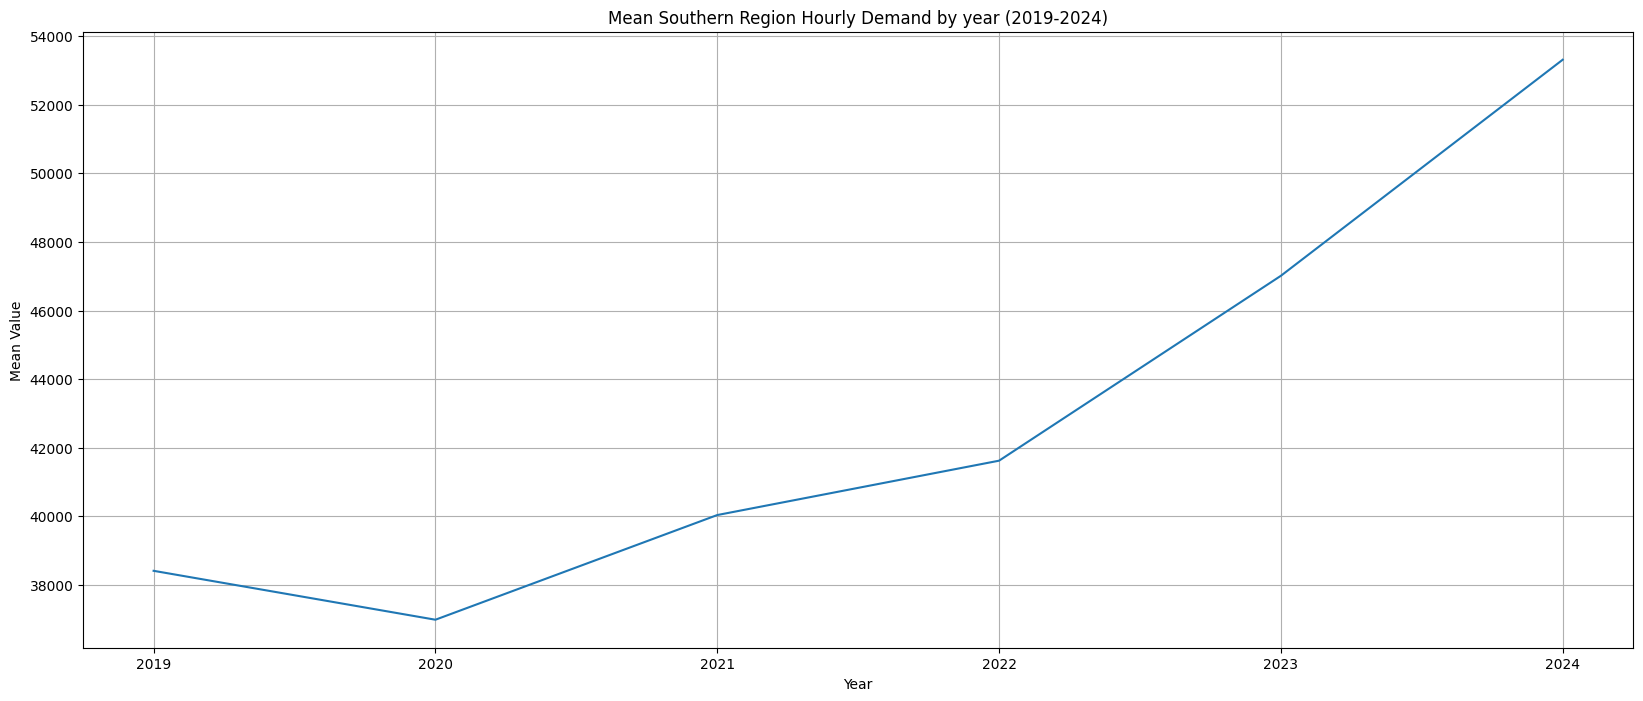

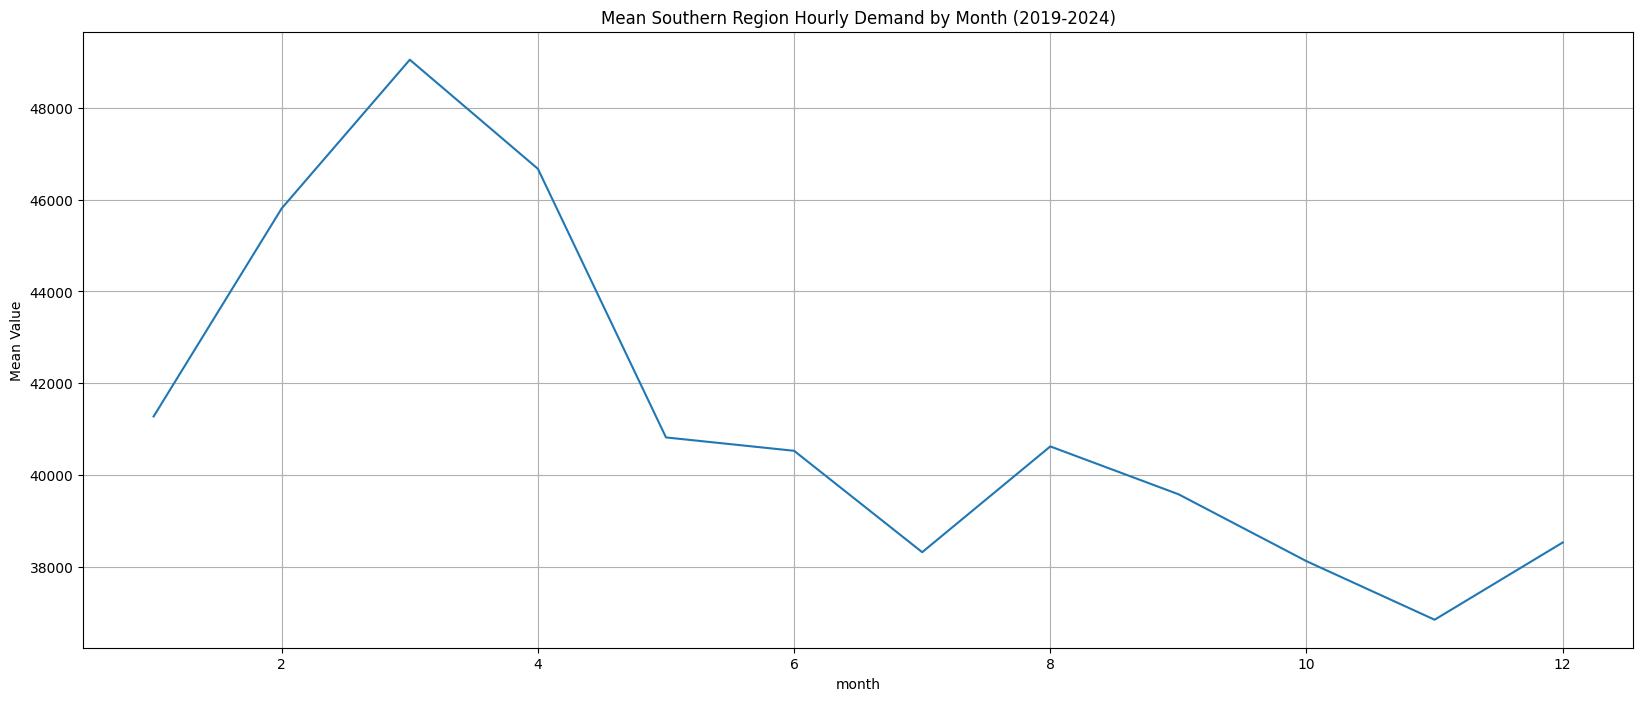

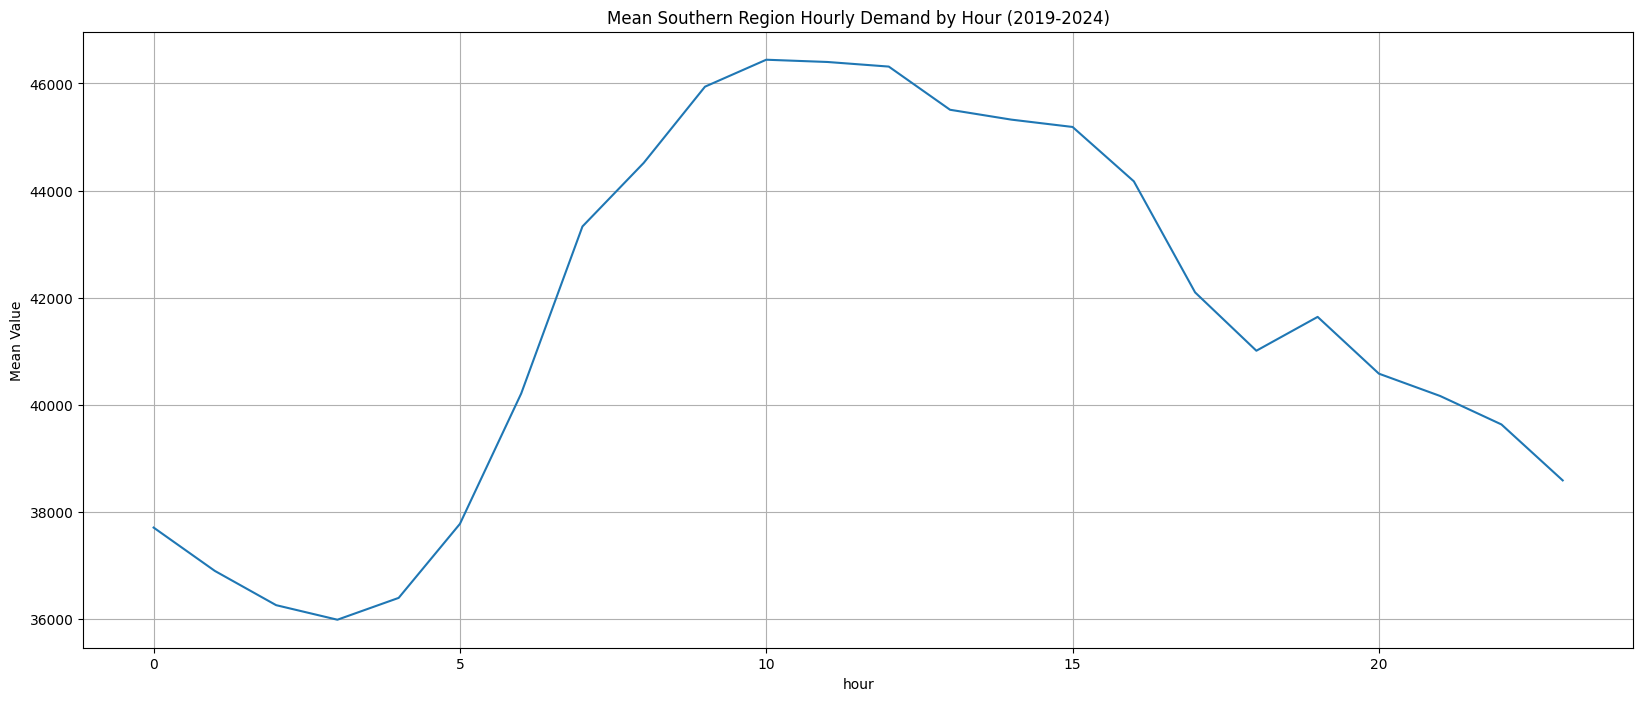

In [84]:
plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Southern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Maximum Value')
plt.title('Maximum Southern Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Southern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('month')
plt.ylabel('Maximum Value')
plt.title('Maximum Southern Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Southern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Maximum Value')
plt.title('Maximum Southern Region Hourly Demand by Hour (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Southern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.title('Mean Southern Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Southern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('month')
plt.ylabel('Mean Value')
plt.title('Mean Southern Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Southern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Mean Value')
plt.title('Mean Southern Region Hourly Demand by Hour (2019-2024)')
plt.show()



## **Western Region Trends**

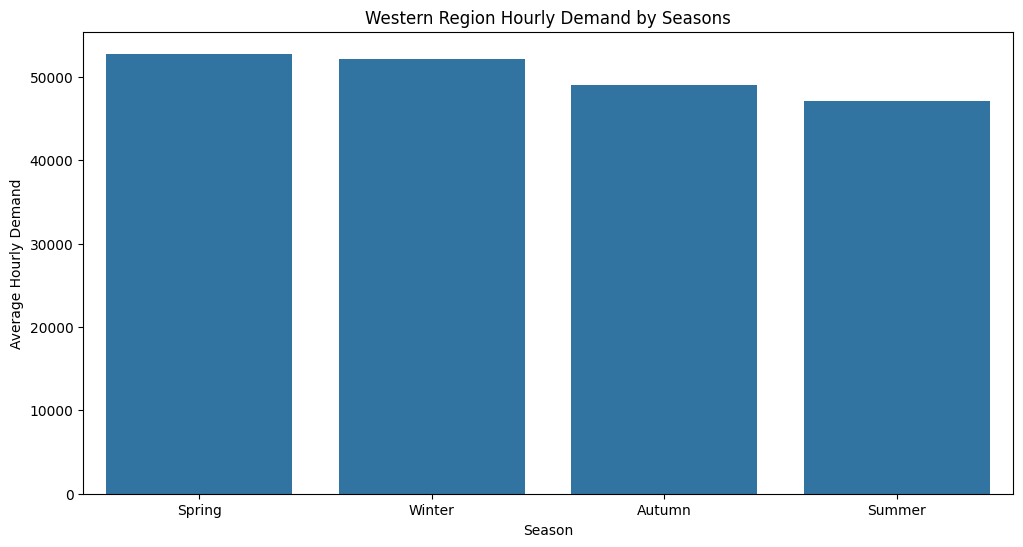

In [85]:
season_poll = df.groupby('Season')['Western Region Hourly Demand'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=season_poll.index, y=season_poll.values)
plt.title('Western Region Hourly Demand by Seasons')
plt.ylabel('Average Hourly Demand')
plt.show()


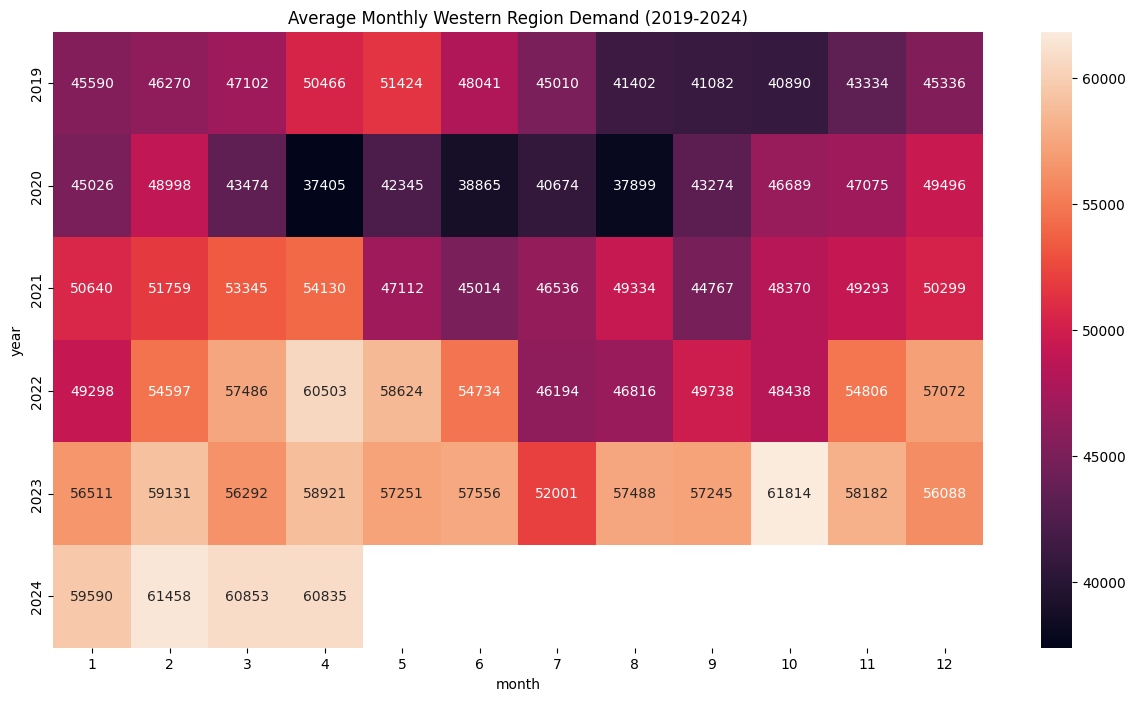

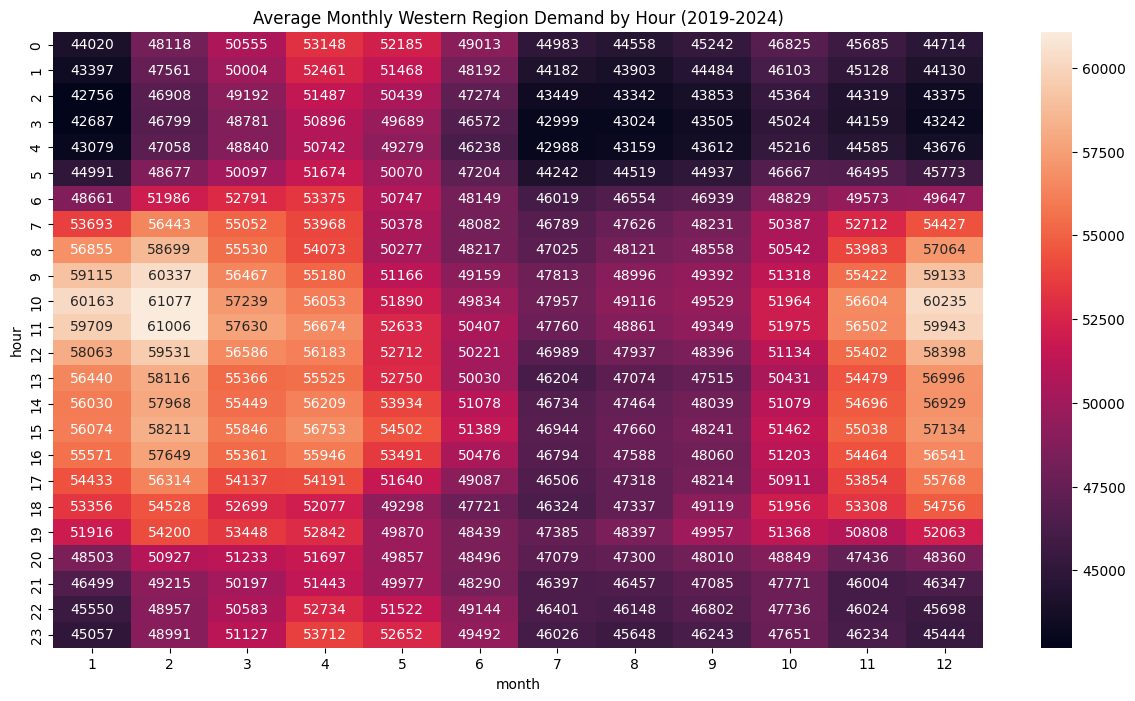

In [86]:
plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['year', 'month'])['Western Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Western Region Demand (2019-2024)')
plt.show()

plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['hour','month'])['Western Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Western Region Demand by Hour (2019-2024)')
plt.show()

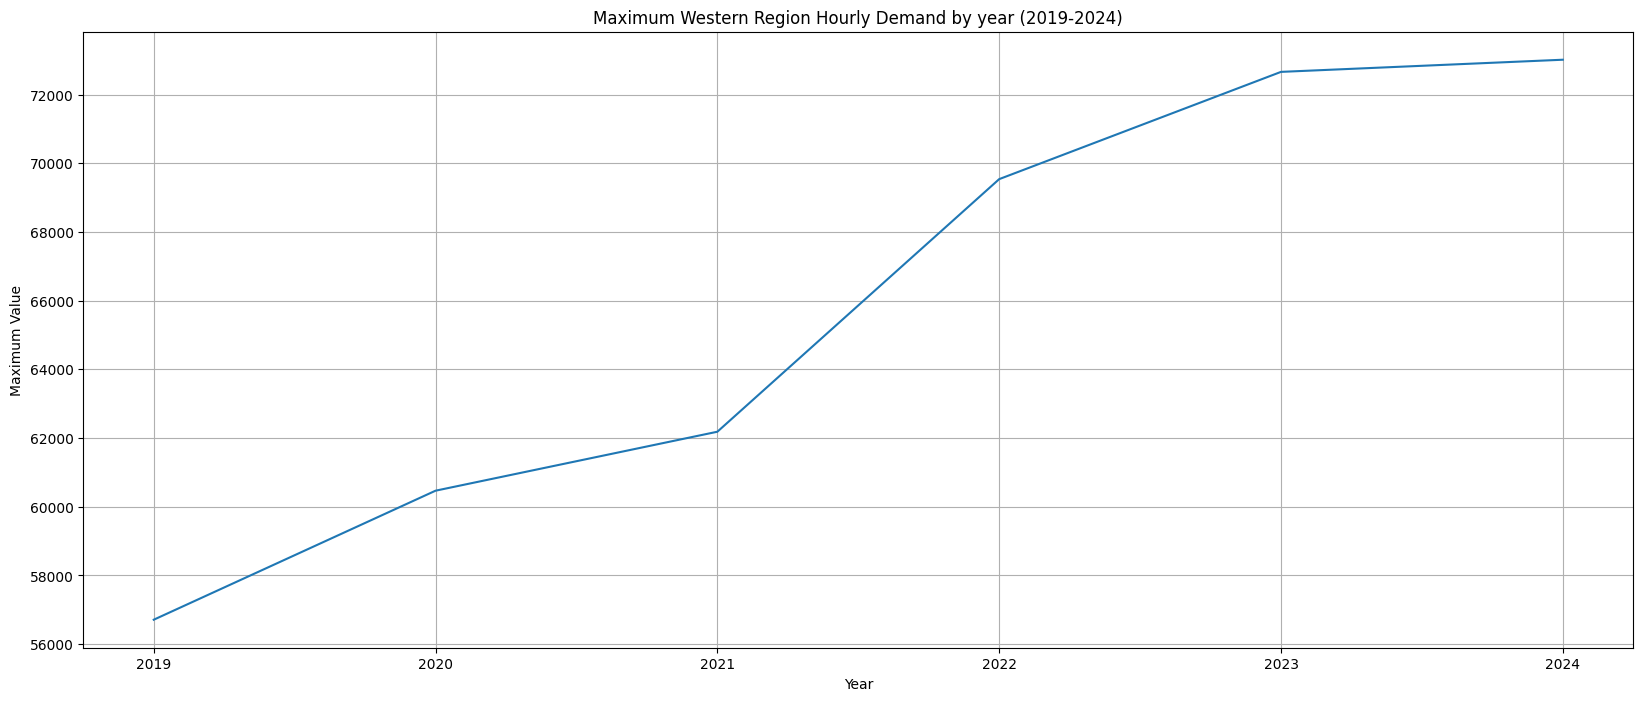

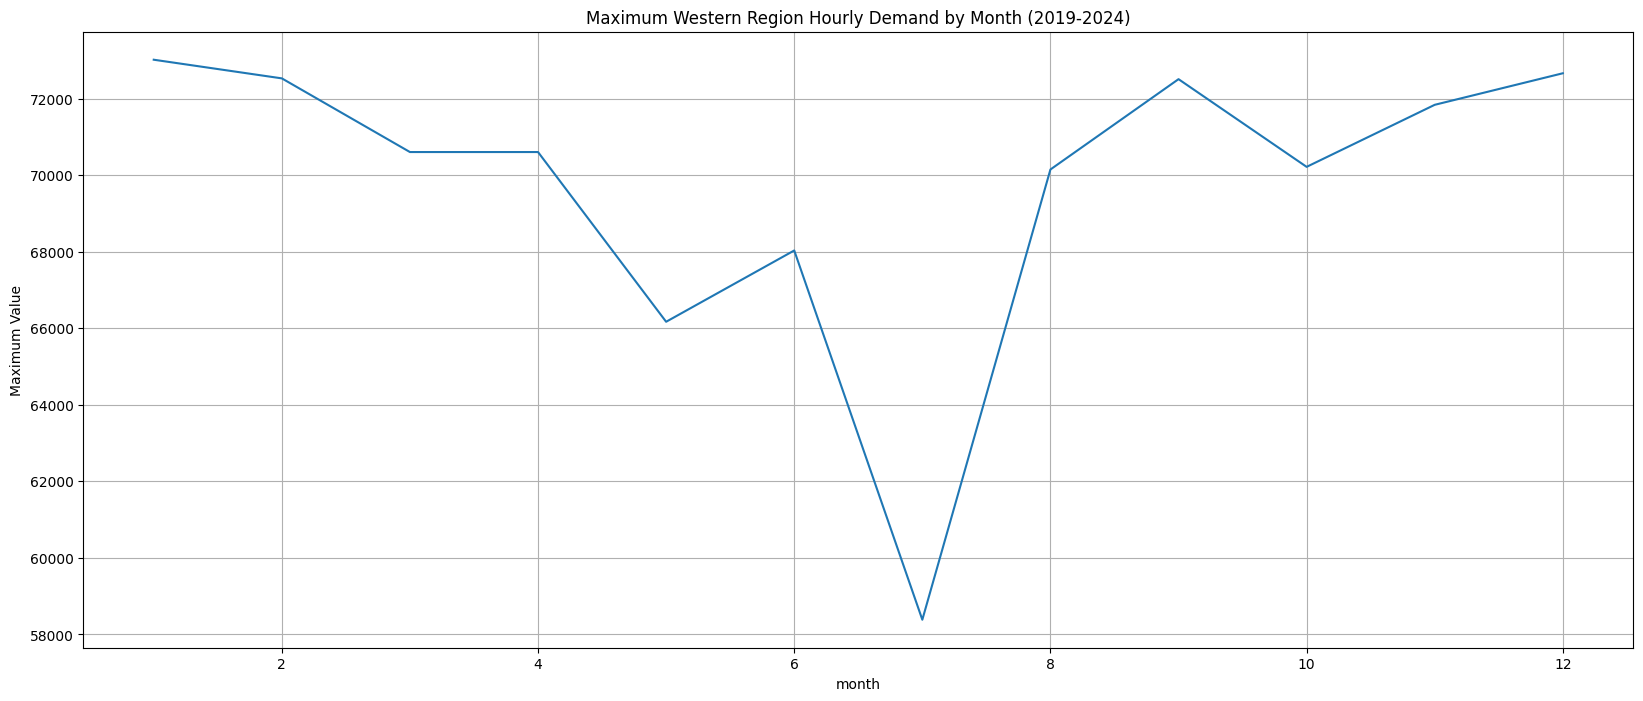

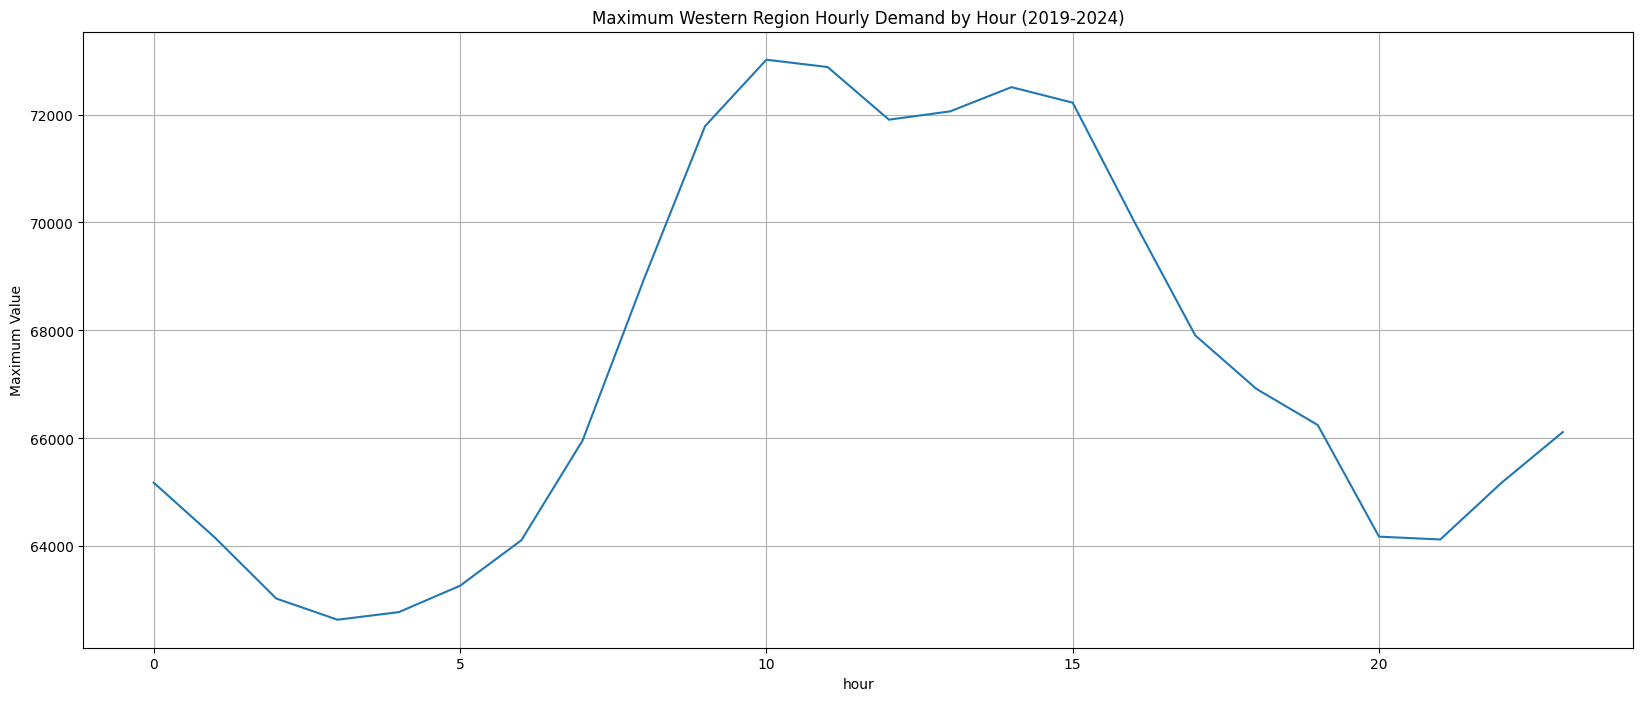

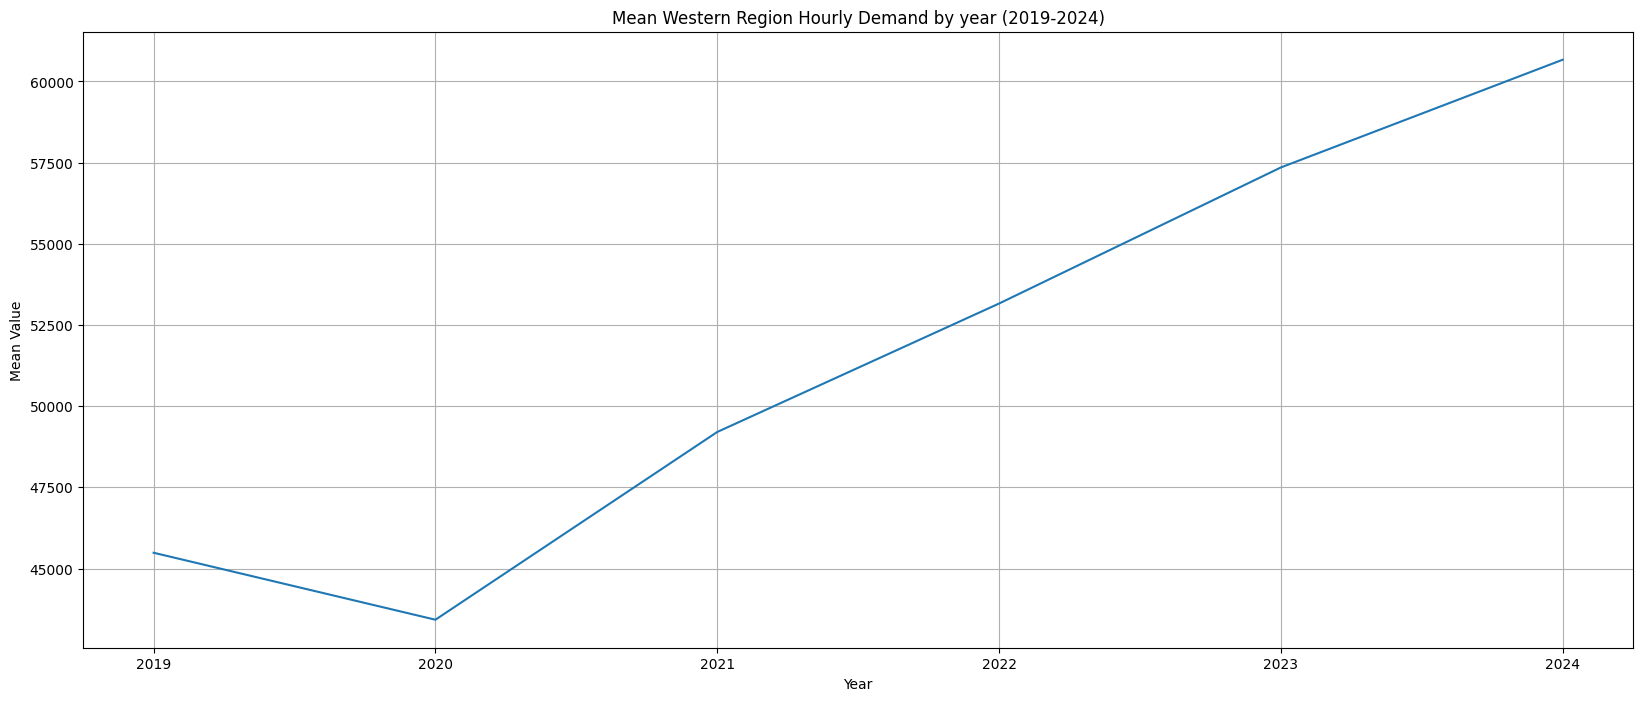

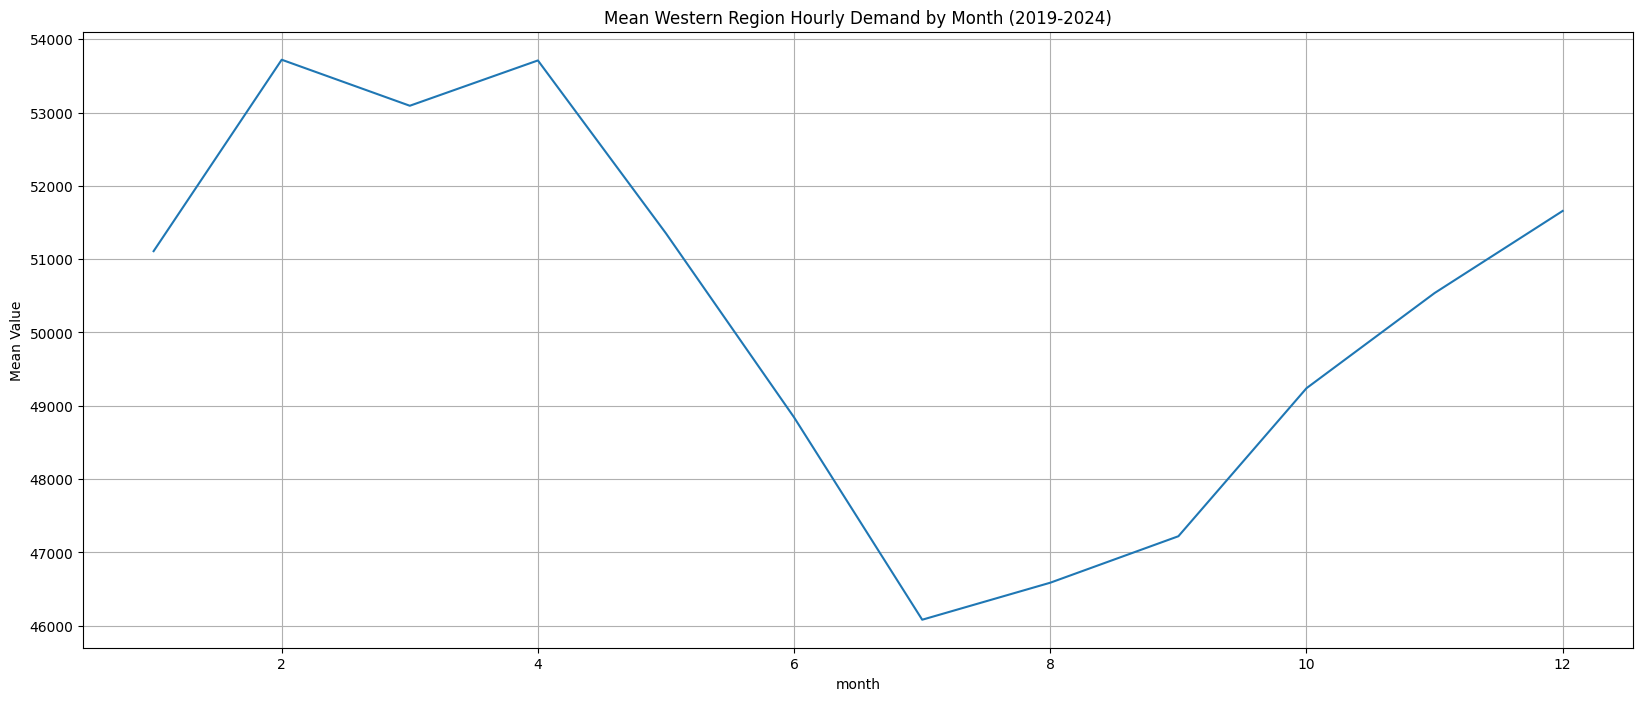

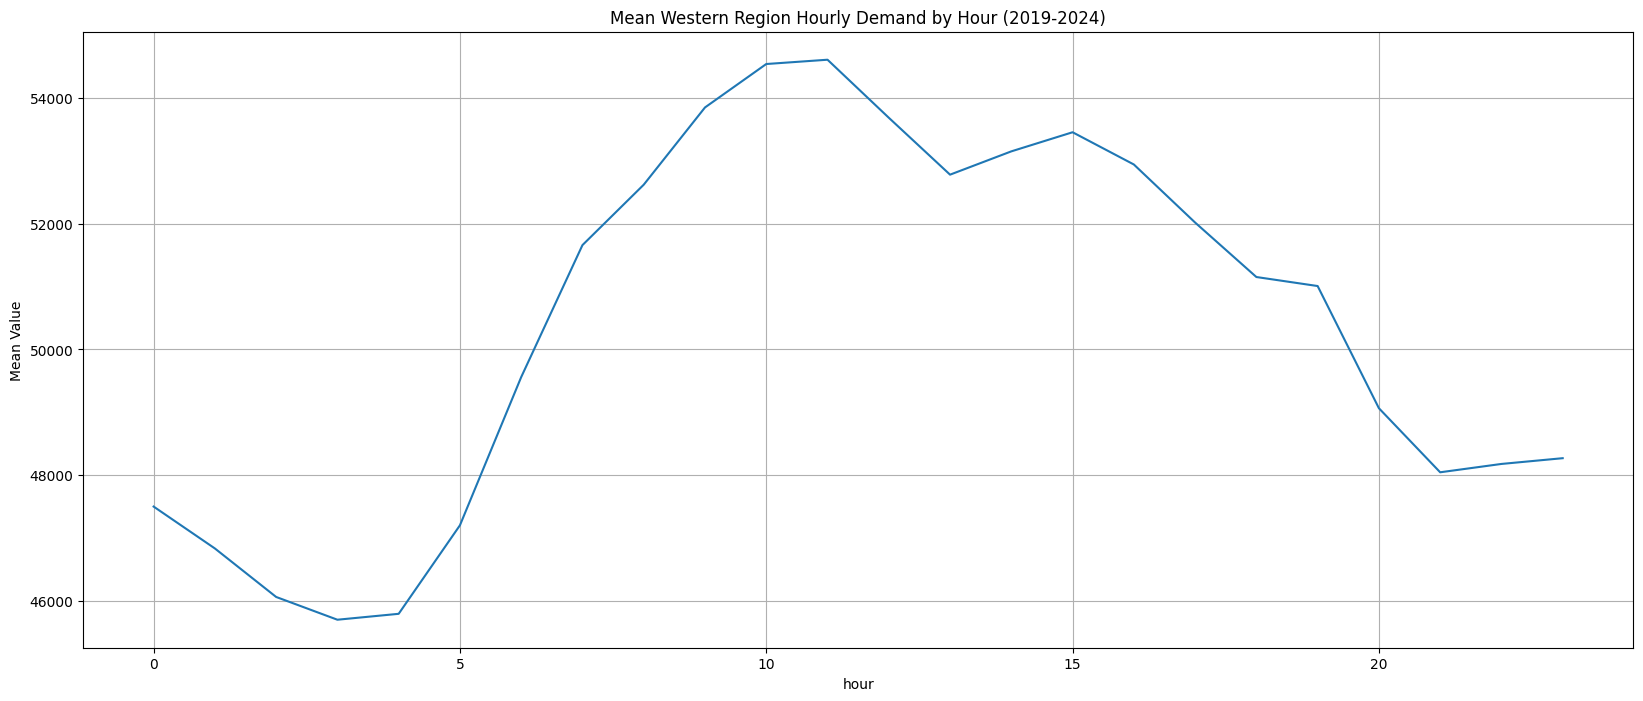

In [87]:
plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Western Region Hourly Demand'].max())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Maximum Value')
plt.title('Maximum Western Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Western Region Hourly Demand'].max())
plt.grid()
plt.xlabel('month')
plt.ylabel('Maximum Value')
plt.title('Maximum Western Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Western Region Hourly Demand'].max())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Maximum Value')
plt.title('Maximum Western Region Hourly Demand by Hour (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Western Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.title('Mean Western Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Western Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('month')
plt.ylabel('Mean Value')
plt.title('Mean Western Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Western Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Mean Value')
plt.title('Mean Western Region Hourly Demand by Hour (2019-2024)')
plt.show()



## **Eastern Region Trends**

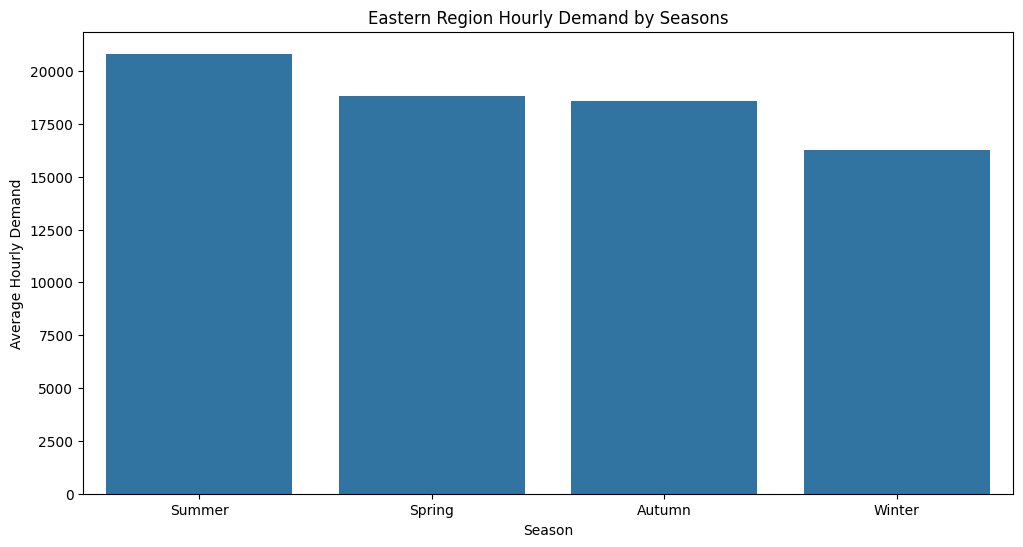

In [88]:
season_poll = df.groupby('Season')['Eastern Region Hourly Demand'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=season_poll.index, y=season_poll.values)
plt.title('Eastern Region Hourly Demand by Seasons')
plt.ylabel('Average Hourly Demand')
plt.show()


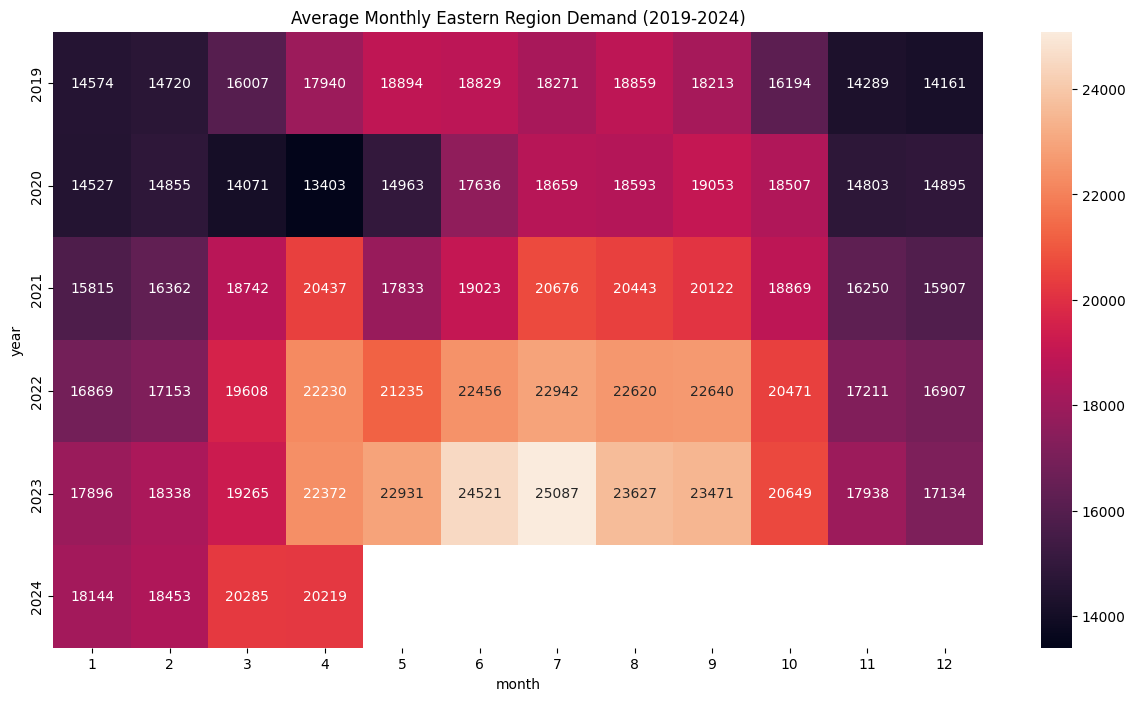

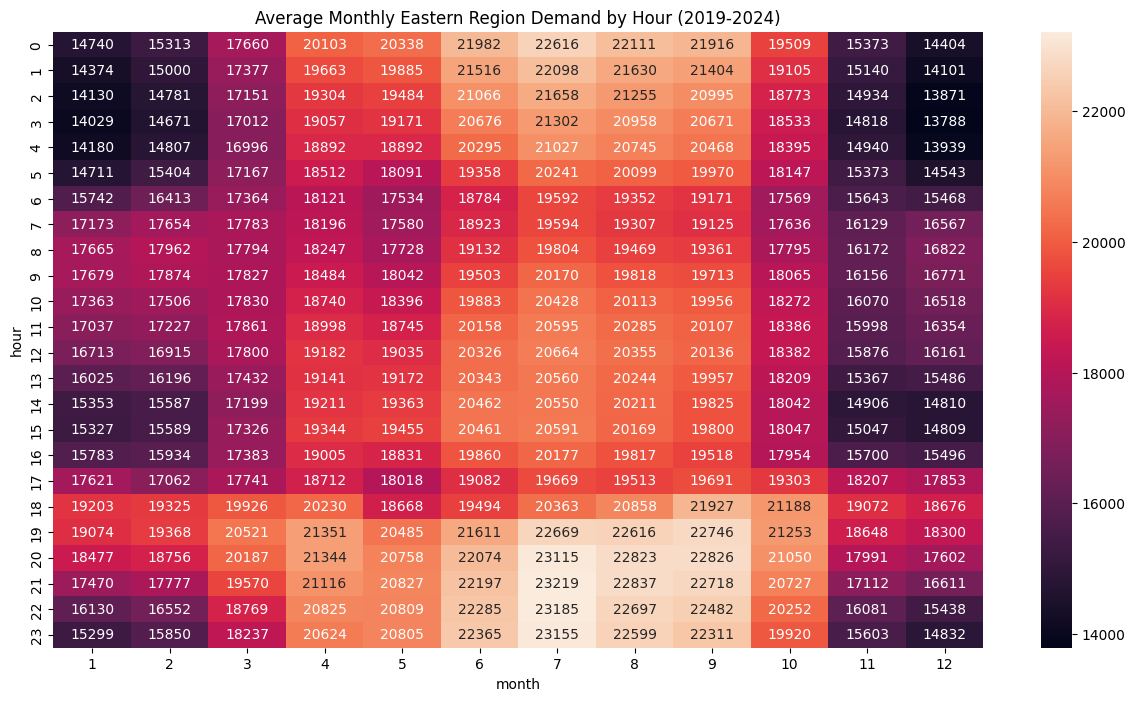

In [89]:
plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['year', 'month'])['Eastern Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Eastern Region Demand (2019-2024)')
plt.show()

plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['hour','month'])['Eastern Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly Eastern Region Demand by Hour (2019-2024)')
plt.show()

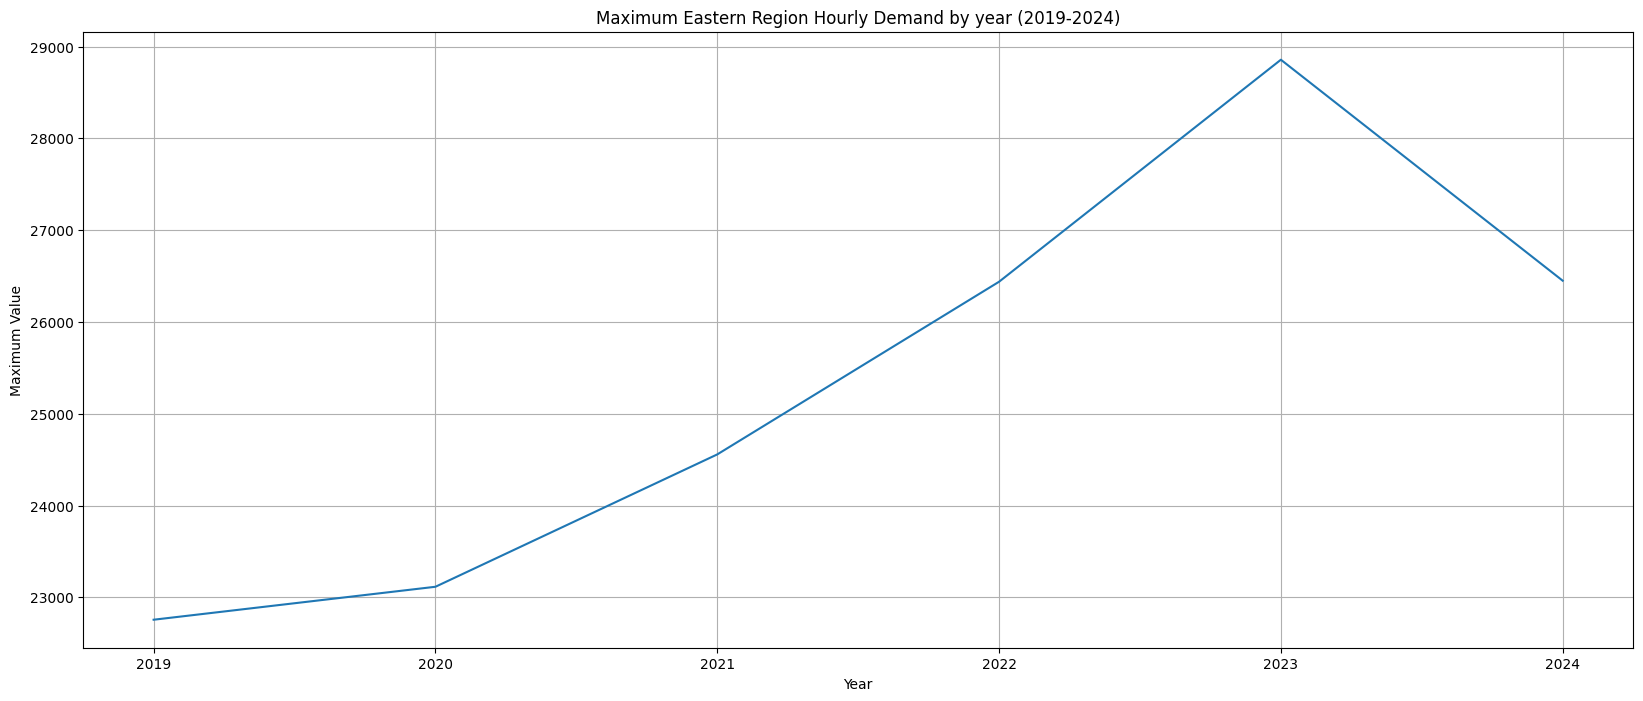

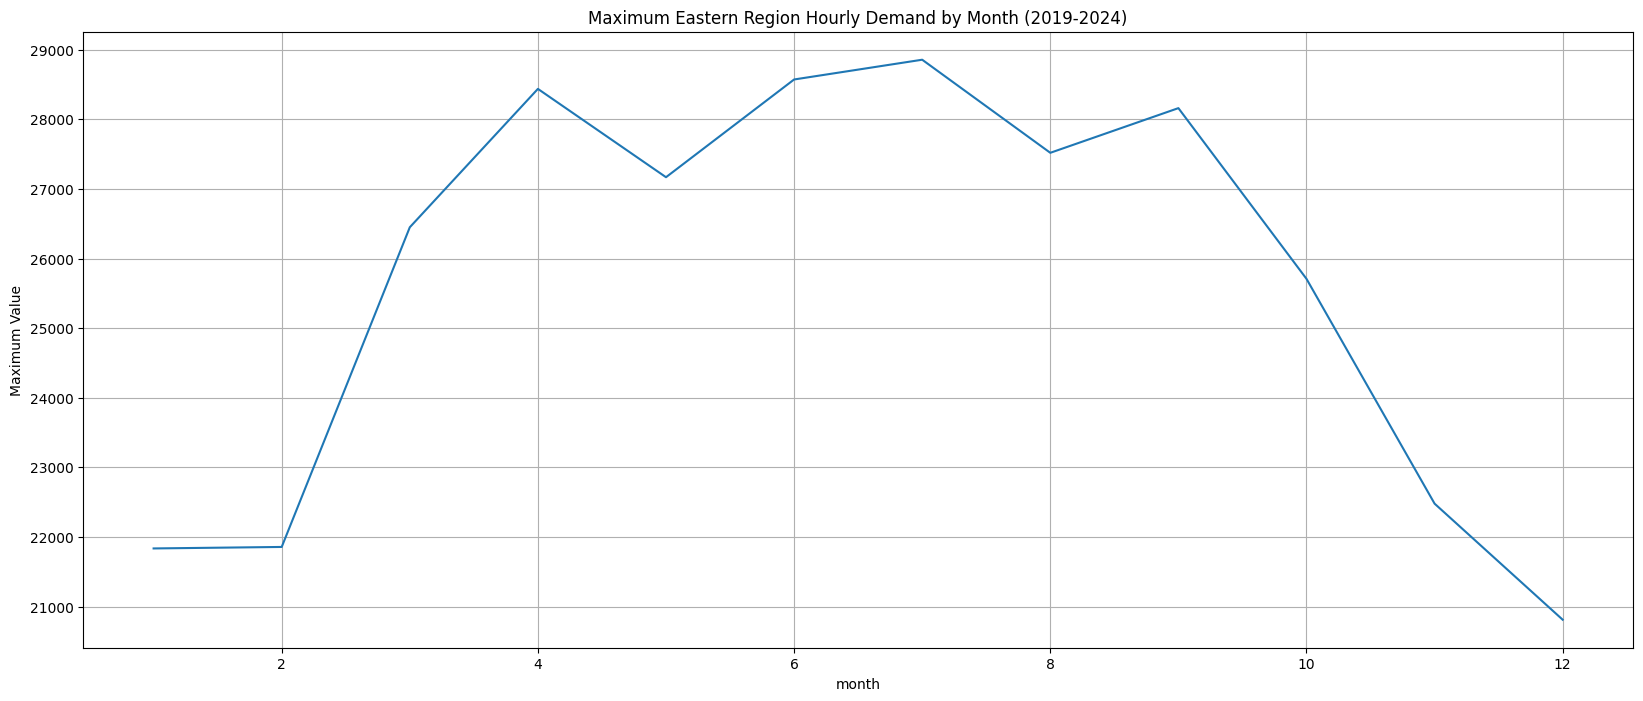

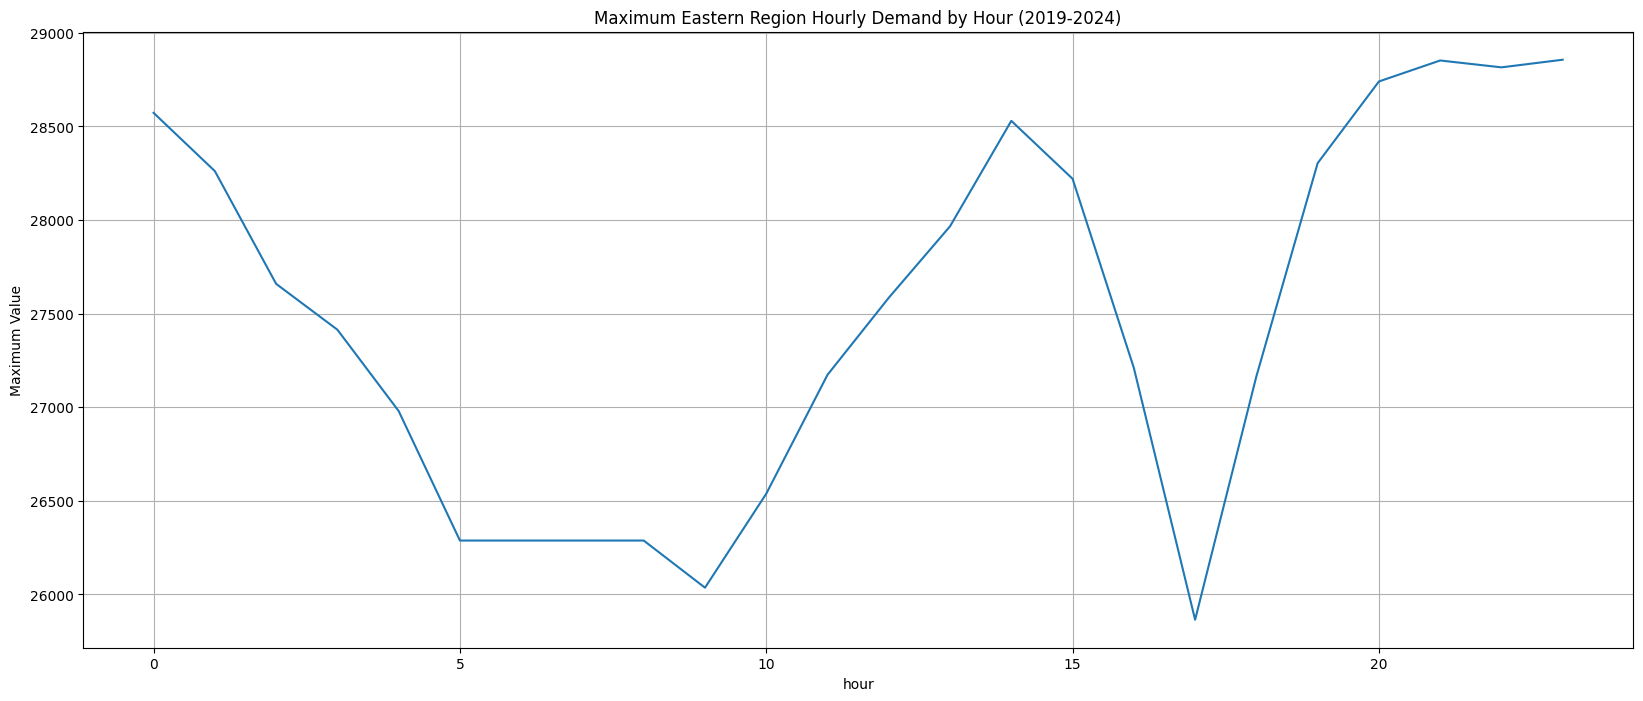

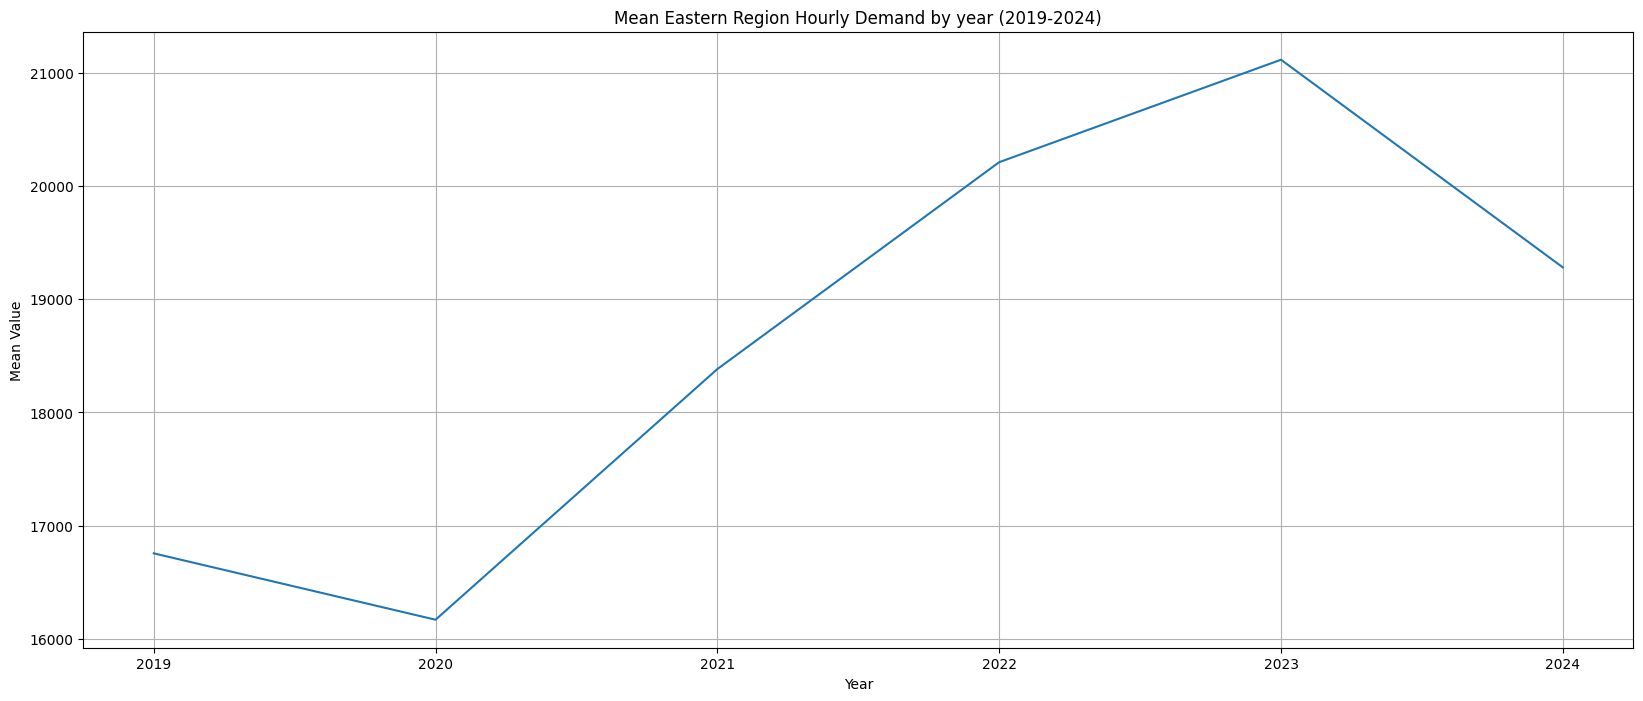

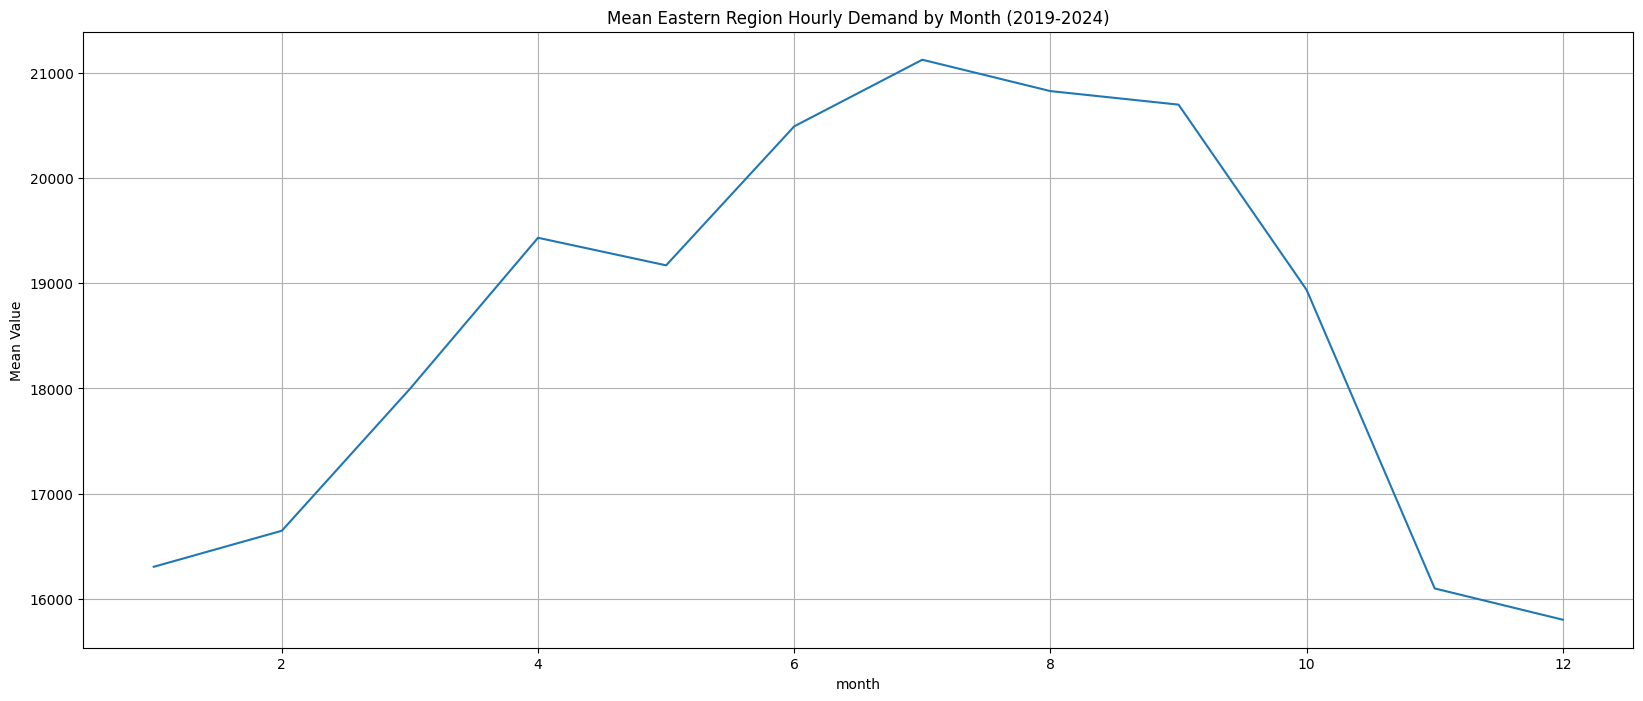

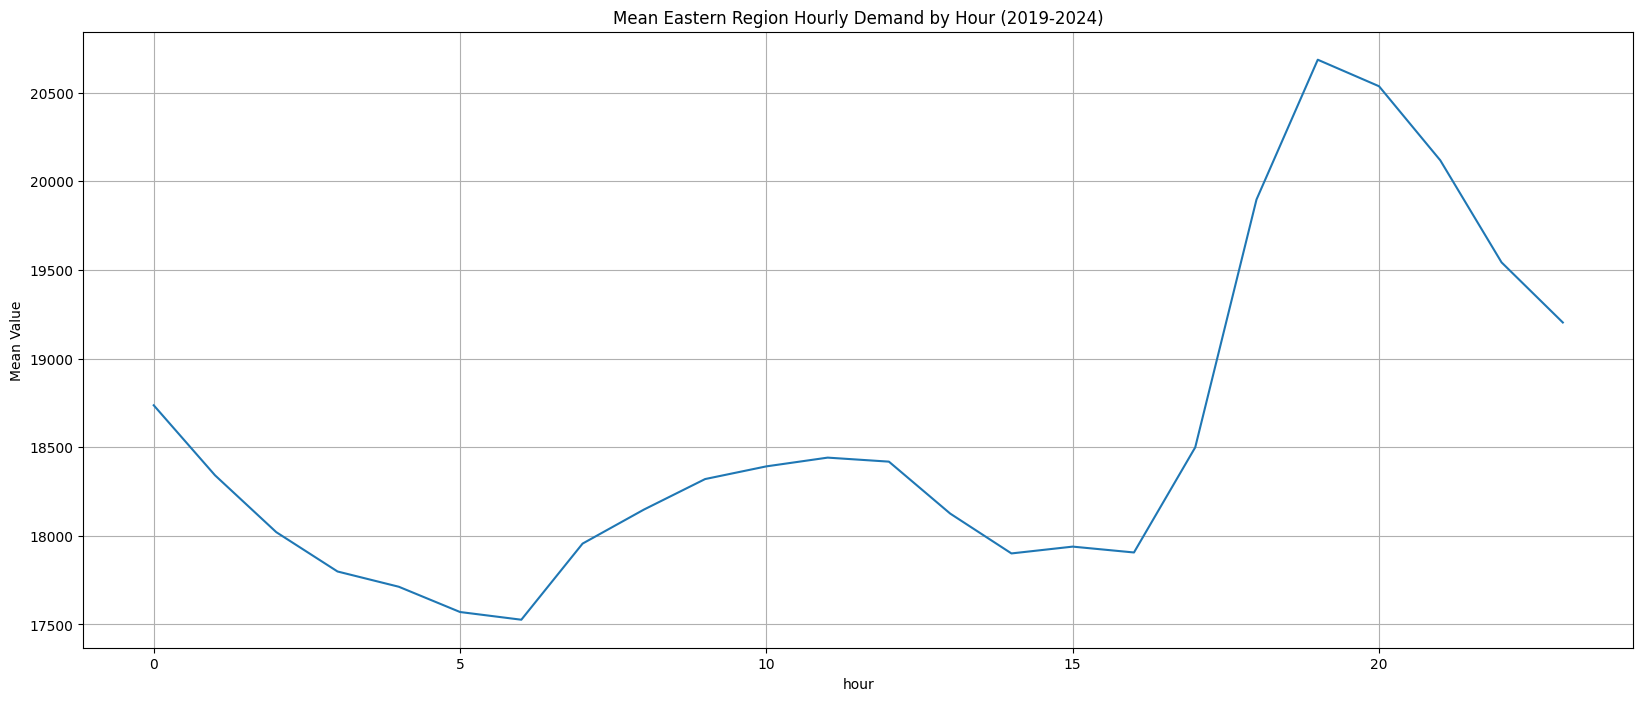

In [90]:
plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Eastern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Maximum Value')
plt.title('Maximum Eastern Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Eastern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('month')
plt.ylabel('Maximum Value')
plt.title('Maximum Eastern Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Eastern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Maximum Value')
plt.title('Maximum Eastern Region Hourly Demand by Hour (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['Eastern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.title('Mean Eastern Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['Eastern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('month')
plt.ylabel('Mean Value')
plt.title('Mean Eastern Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['Eastern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Mean Value')
plt.title('Mean Eastern Region Hourly Demand by Hour (2019-2024)')
plt.show()



## **North-Eastern Region Trends**

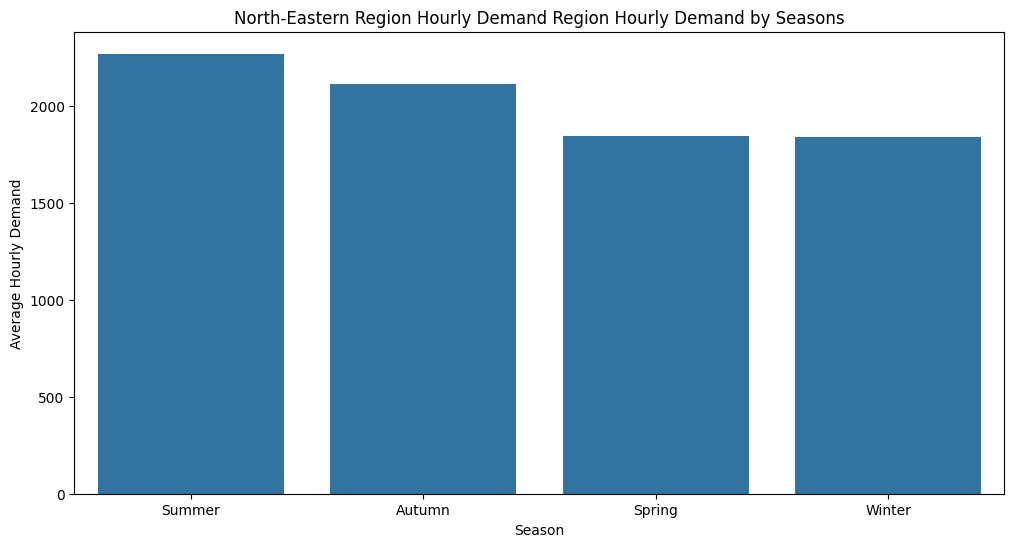

In [91]:
season_poll = df.groupby('Season')['North-Eastern Region Hourly Demand'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=season_poll.index, y=season_poll.values)
plt.title('North-Eastern Region Hourly Demand Region Hourly Demand by Seasons')
plt.ylabel('Average Hourly Demand')
plt.show()


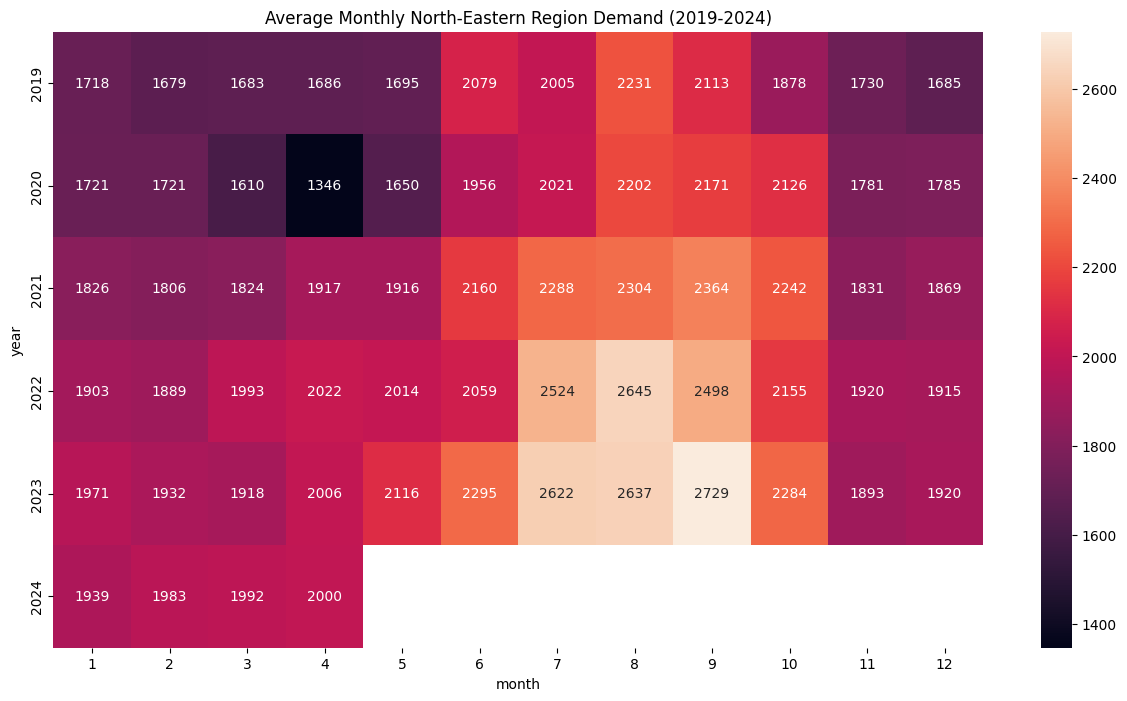

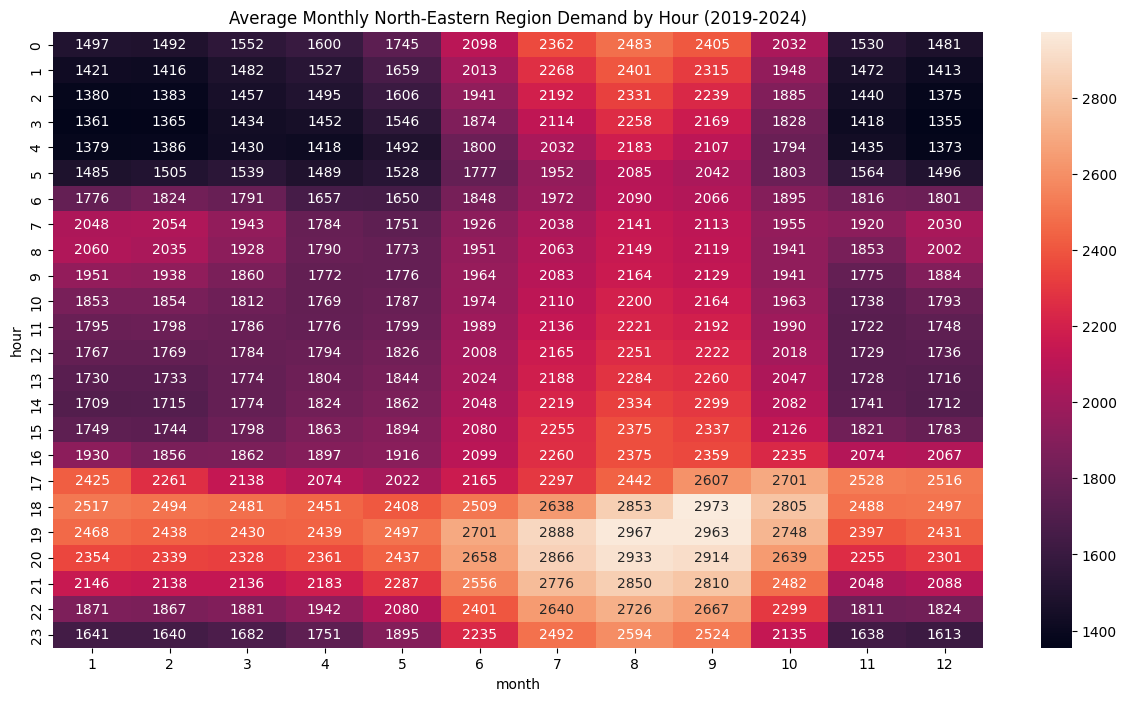

In [92]:
plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['year', 'month'])['North-Eastern Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly North-Eastern Region Demand (2019-2024)')
plt.show()

plt.figure(figsize=(15,8))
sns.heatmap(df.groupby(['hour','month'])['North-Eastern Region Hourly Demand'].mean().unstack(), annot=True, fmt='.0f')
plt.title('Average Monthly North-Eastern Region Demand by Hour (2019-2024)')
plt.show()

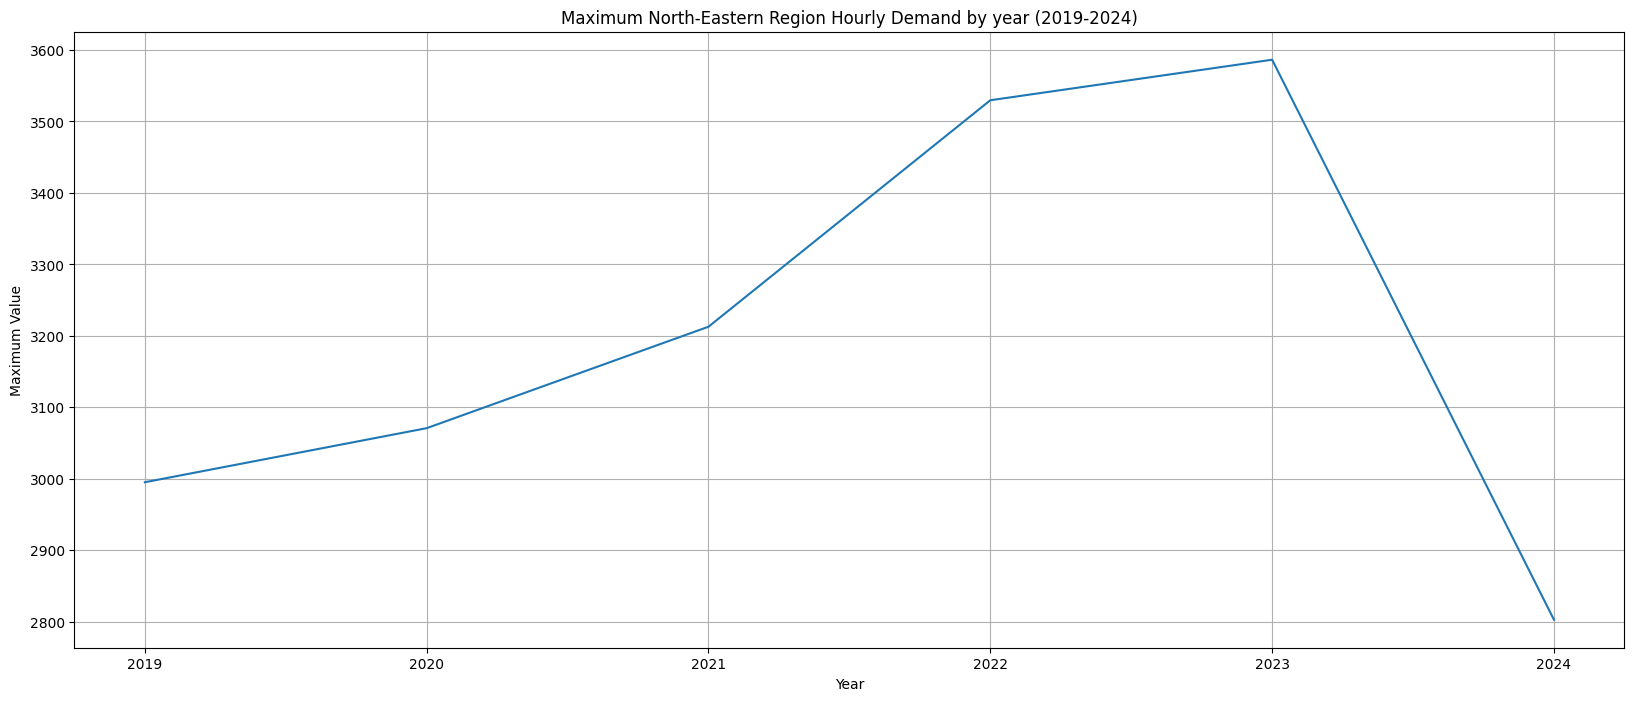

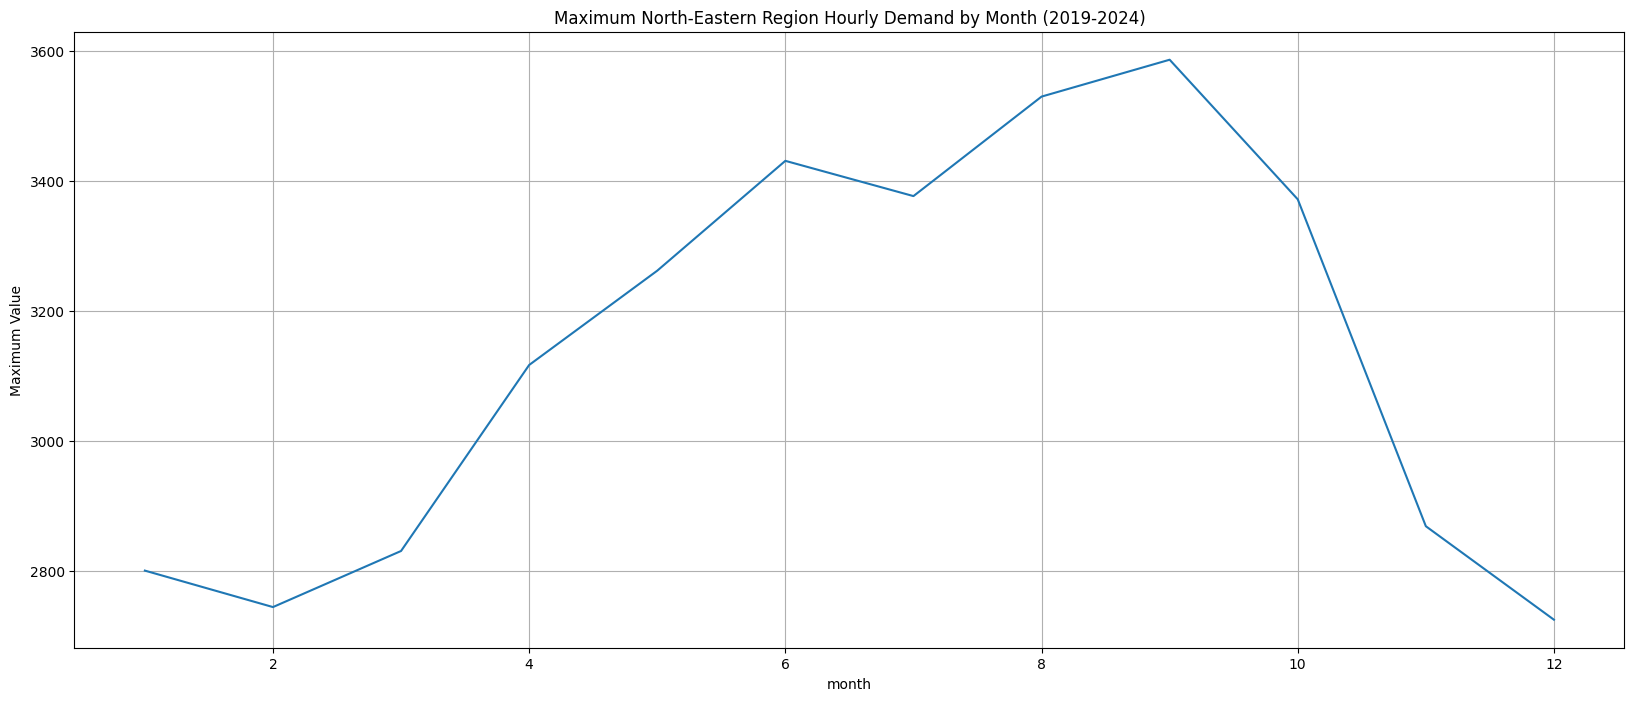

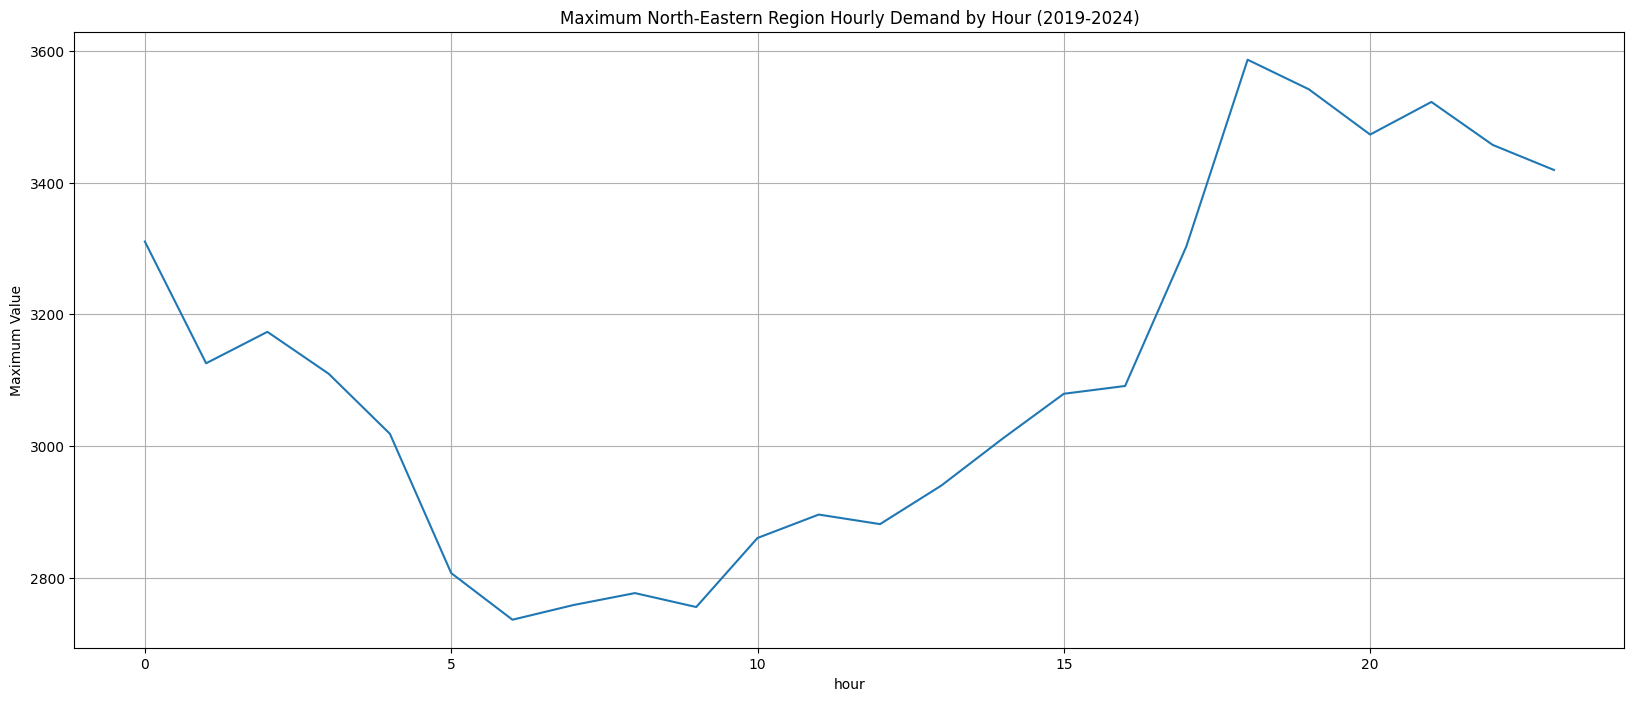

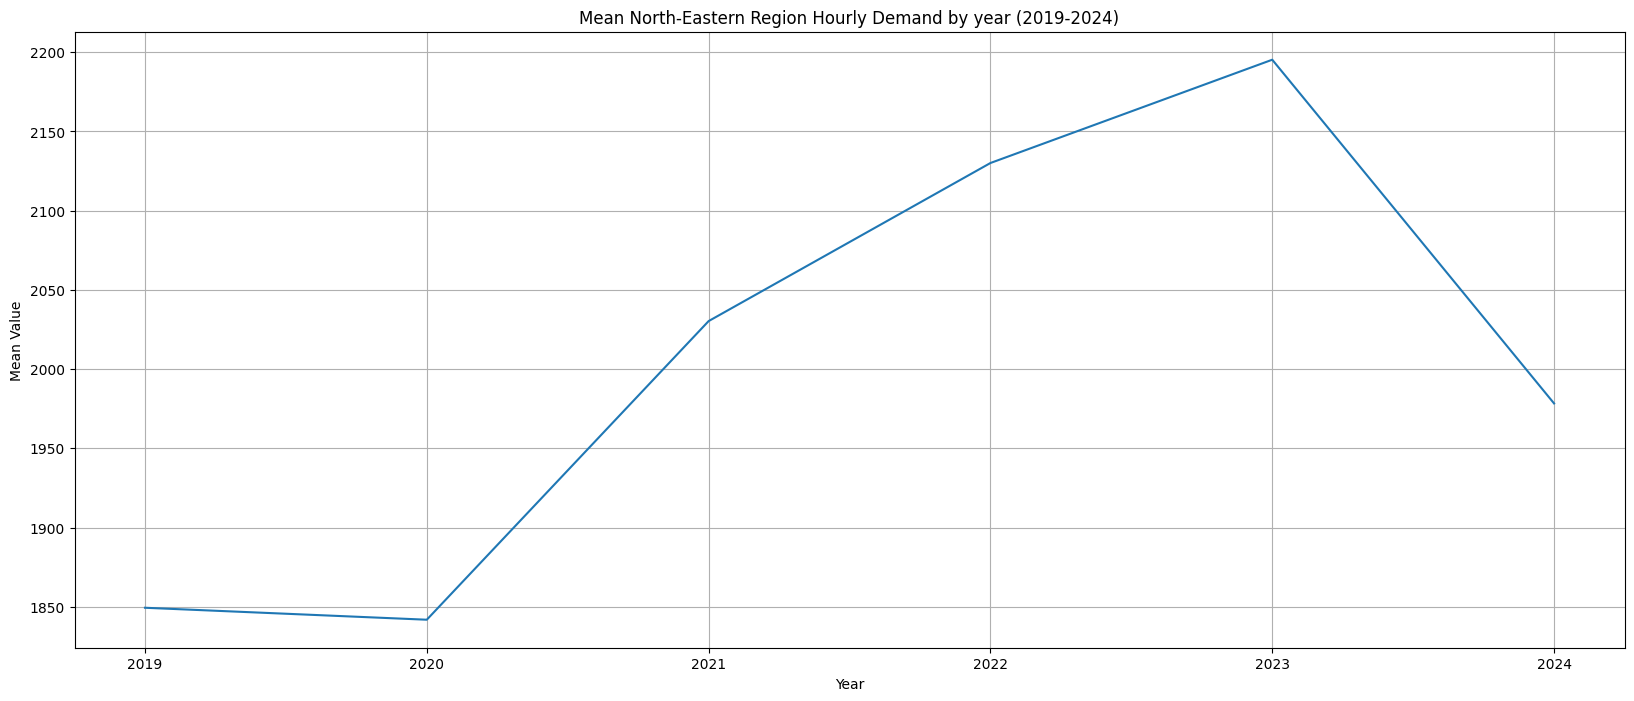

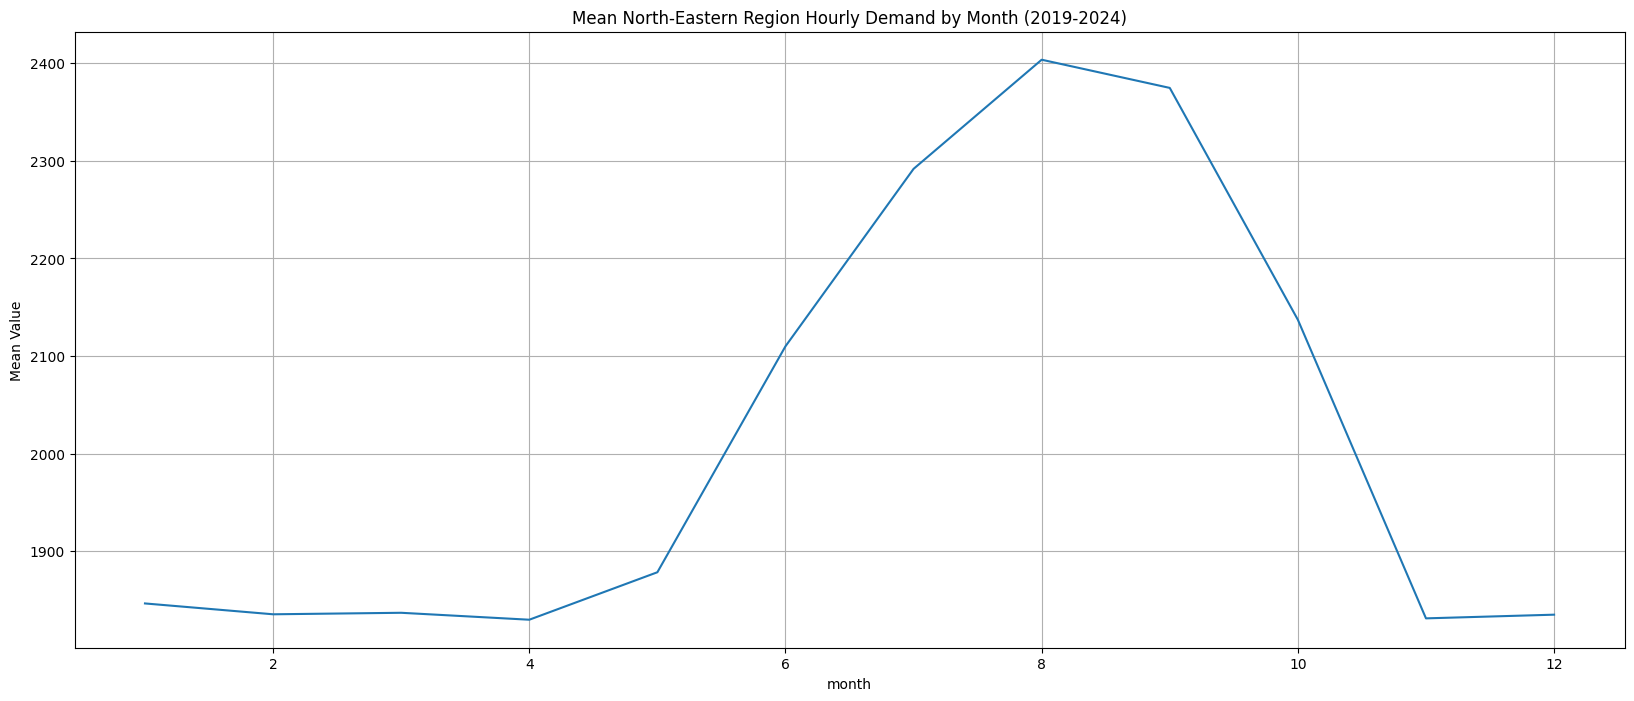

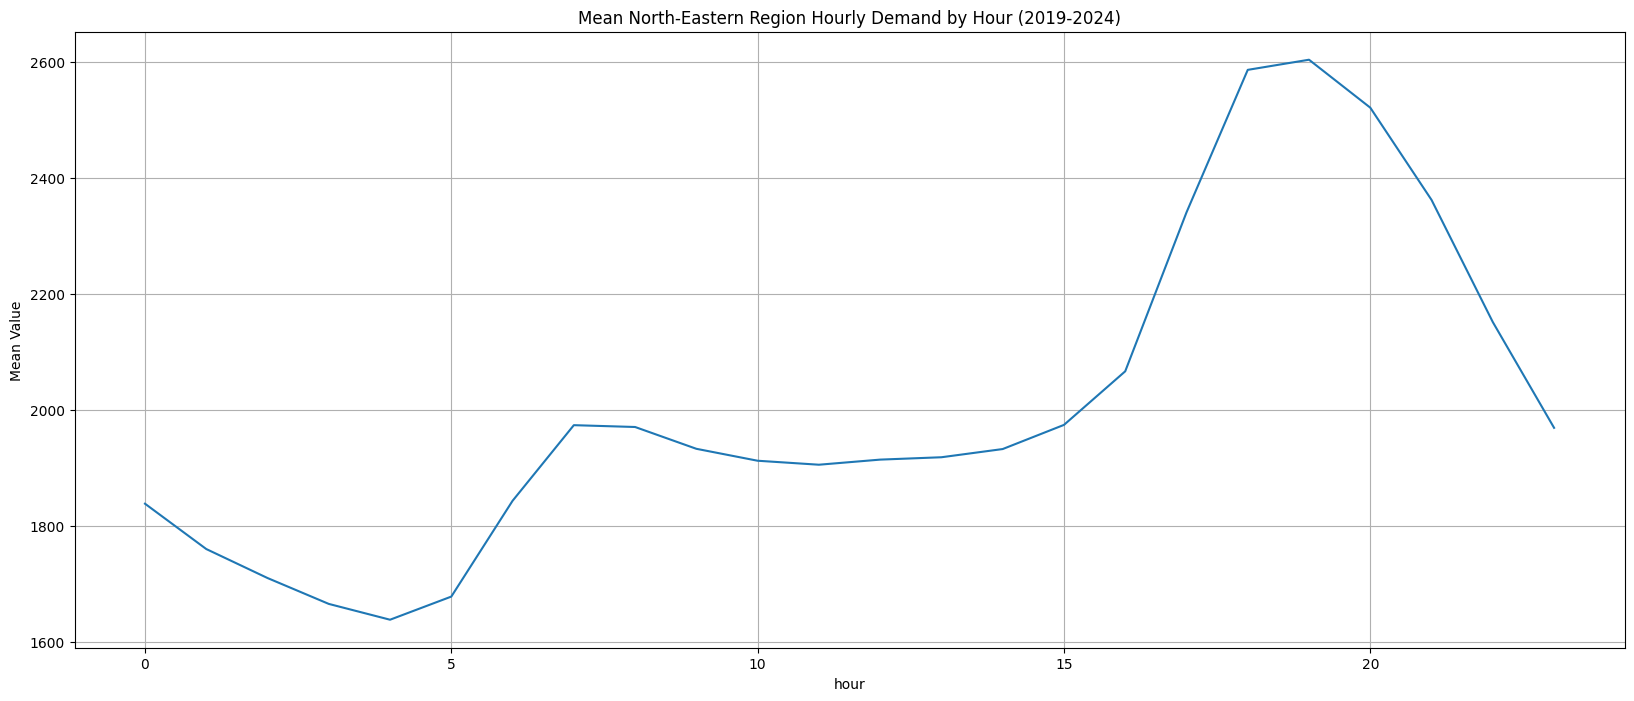

In [93]:
plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['North-Eastern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Maximum Value')
plt.title('Maximum North-Eastern Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['North-Eastern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('month')
plt.ylabel('Maximum Value')
plt.title('Maximum North-Eastern Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['North-Eastern Region Hourly Demand'].max())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Maximum Value')
plt.title('Maximum North-Eastern Region Hourly Demand by Hour (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['year'])['North-Eastern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.title('Mean North-Eastern Region Hourly Demand by year (2019-2024)')
plt.show()

plt.figure(figsize=(20,8))
plt.plot(df.groupby(['month'])['North-Eastern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('month')
plt.ylabel('Mean Value')
plt.title('Mean North-Eastern Region Hourly Demand by Month (2019-2024)')
plt.show()


plt.figure(figsize=(20,8))
plt.plot(df.groupby(['hour'])['North-Eastern Region Hourly Demand'].mean())
plt.grid()
plt.xlabel('hour')
plt.ylabel('Mean Value')
plt.title('Mean North-Eastern Region Hourly Demand by Hour (2019-2024)')
plt.show()



## **Summary of Trends**

In [94]:
def demand_summary(df, col):
    print(f"\n===== {col} =====")

    # Maximum demand
    yearly_max = df.groupby('year')[col].max()
    monthly_max = df.groupby('month')[col].max()
    hourly_max = df.groupby('hour')[col].max()

    print(
        f"maximum demand (by year): {yearly_max.idxmax()}, "
        f"minimum demand (by year): {yearly_max.idxmin()}"
    )

    print(
        f"maximum demand (by month): {monthly_max.idxmax()}, "
        f"minimum demand (by month): {monthly_max.idxmin()}"
    )

    print(
        f"maximum demand (by hour): {hourly_max.idxmax()}, "
        f"minimum demand (by hour): {hourly_max.idxmin()}"
    )

    # Mean demand
    yearly_mean = df.groupby('year')[col].mean()
    monthly_mean = df.groupby('month')[col].mean()
    hourly_mean = df.groupby('hour')[col].mean()

    print(
        f"mean demand (by year): max in {yearly_mean.idxmax()}, "
        f"min in {yearly_mean.idxmin()}"
    )

    print(
        f"mean demand (by month): max in {monthly_mean.idxmax()}, "
        f"min in {monthly_mean.idxmin()}"
    )

    print(
        f"mean demand (by hour): max at {hourly_mean.idxmax()}, "
        f"min at {hourly_mean.idxmin()}"
    )

demand_summary(df, 'National Hourly Demand')

demand_summary(df, 'Northen Region Hourly Demand')

demand_summary(df, 'Southern Region Hourly Demand')

demand_summary(df, 'Western Region Hourly Demand')

demand_summary(df, 'Eastern Region Hourly Demand')

demand_summary(df, 'North-Eastern Region Hourly Demand')


===== National Hourly Demand =====
maximum demand (by year): 2023, minimum demand (by year): 2020
maximum demand (by month): 9, minimum demand (by month): 11
maximum demand (by hour): 12, minimum demand (by hour): 5
mean demand (by year): max in 2024, min in 2020
mean demand (by month): max in 6, min in 11
mean demand (by hour): max at 11, min at 3

===== Northen Region Hourly Demand =====
maximum demand (by year): 2023, minimum demand (by year): 2019
maximum demand (by month): 9, minimum demand (by month): 11
maximum demand (by hour): 15, minimum demand (by hour): 7
mean demand (by year): max in 2023, min in 2020
mean demand (by month): max in 8, min in 11
mean demand (by hour): max at 19, min at 3

===== Southern Region Hourly Demand =====
maximum demand (by year): 2024, minimum demand (by year): 2019
maximum demand (by month): 3, minimum demand (by month): 7
maximum demand (by hour): 11, minimum demand (by hour): 20
mean demand (by year): max in 2024, min in 2020
mean demand (by mo

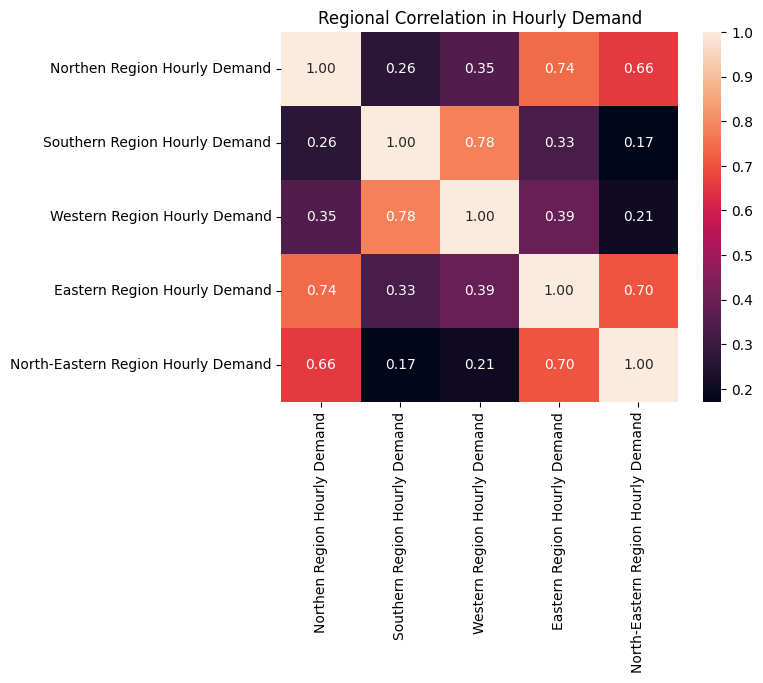

In [95]:
regions = [
    'Northen Region Hourly Demand',
    'Southern Region Hourly Demand',
    'Western Region Hourly Demand',
    'Eastern Region Hourly Demand',
    'North-Eastern Region Hourly Demand'
]

sns.heatmap(df[regions].corr(), fmt='1.2f', annot=True)
plt.title('Regional Correlation in Hourly Demand')
plt.show()


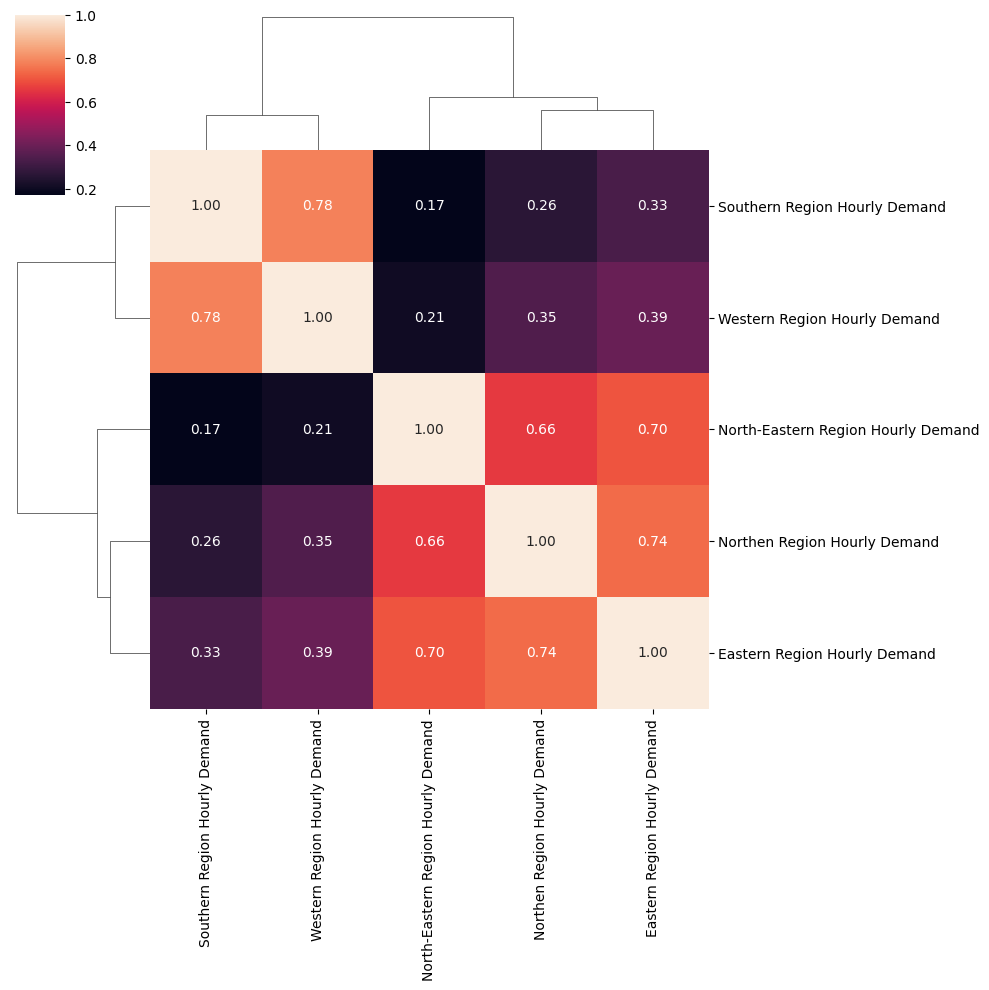

In [96]:
sns.clustermap(
    df[regions].corr(), fmt='1.2f', annot=True
)
plt.show()

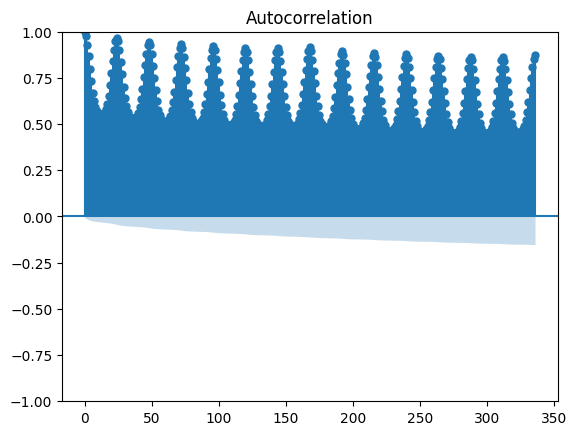

In [97]:
from statsmodels.graphics.tsaplots import plot_acf

series = df['National Hourly Demand']

plot_acf(
    series,
    lags=24*14
)
plt.show()

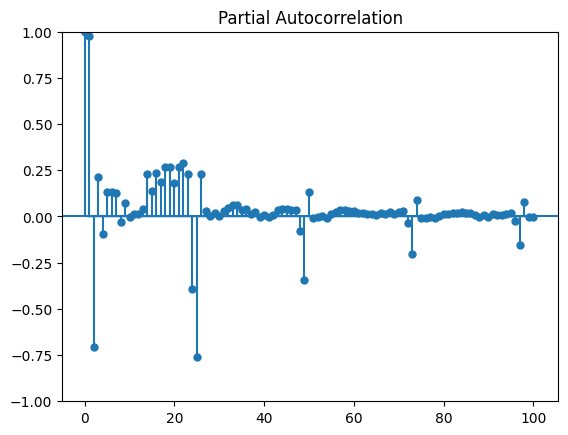

In [98]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(
    series,
    lags=100
)
plt.show()

# **Establishing a Baseline**

In [99]:
df = df.sort_values("datetime")

df["target"] = (df["National Hourly Demand"].shift(-24))

df = df.dropna(subset=["target"])

In [100]:
train_df = df[df["datetime"] < "2023-01-01"]

val_df = df[
    (df["datetime"] >= "2023-01-01") &
    (df["datetime"] < "2024-01-01")
]

test_df = df[df["datetime"] >= "2024-01-01"]



In [101]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [102]:
y_pred = val_df["National Hourly Demand"]
y_true = val_df["target"]

rmse = mean_squared_error(y_true, y_pred) ** 0.5
print(f"RMSE: {rmse:.2f} GW")

mae = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae:.2f} GW")

mape = mean_absolute_percentage_error(y_true, y_pred) * 100
print(f"MAPE: {mape:.2f}%")

r2 = r2_score(y_true, y_pred)
print(f"R2 Score: {r2:.2f}")

RMSE: 6420.70 GW
MAE: 4721.87 GW
MAPE: 2.66%
R2 Score: 0.90


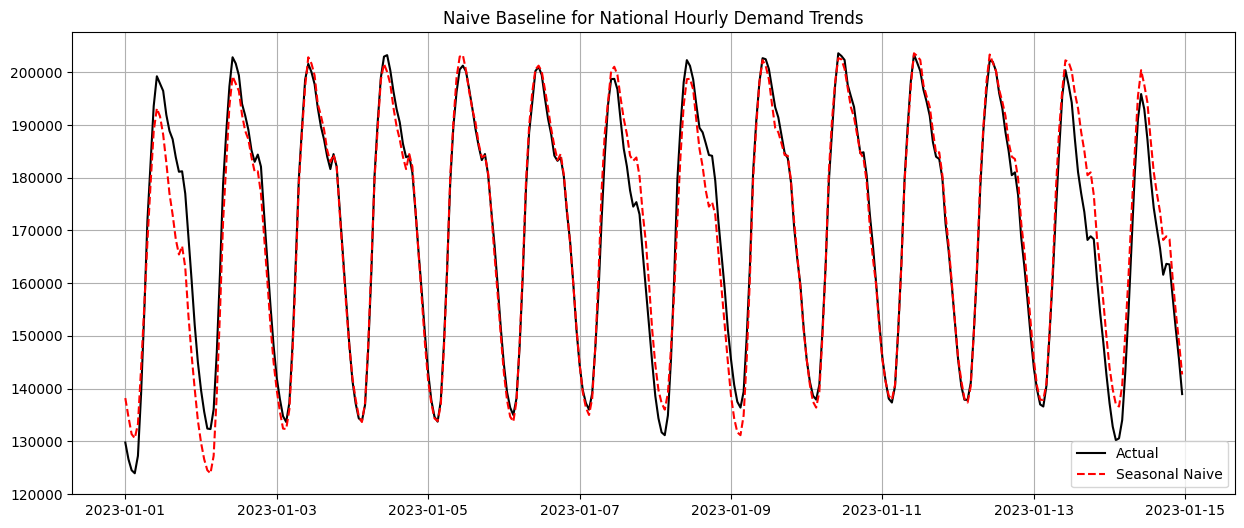

In [103]:
sample = val_df.iloc[:24*14]

plt.figure(figsize=(15,6))
plt.plot(sample["datetime"], sample["target"], label="Actual", color = 'black')
plt.plot(sample["datetime"], sample["National Hourly Demand"],label="Seasonal Naive", color='red', linestyle='--')
plt.legend()
plt.grid()
plt.title('Naive Baseline for National Hourly Demand Trends')
plt.show()

# **National Forecasts Using XGBoost**

In [104]:
!pip install mlflow


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [105]:
import mlflow
import mlflow.xgboost

In [106]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Energy Demand Forecasts")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1780329991844, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780329991844, lifecycle_stage='active', name='Energy Demand Forecasts', tags={}, trace_location=None, workspace='default'>

In [107]:
mlflow.end_run()

In [108]:
from xgboost import XGBRegressor

In [109]:
# Some feature engineering

df_x = df.copy()

df_x['lag_1'] = df_x["National Hourly Demand"].shift(1)
df_x['lag_24'] = df_x["National Hourly Demand"].shift(24)
df_x['lag_168'] = df_x["National Hourly Demand"].shift(168)
df_x["rolling_mean_24"] = (df_x["National Hourly Demand"].shift(1).rolling(24).mean())
df_x["rolling_mean_168"] = (df_x["National Hourly Demand"].shift(1).rolling(168).mean())
df_x["rolling_std_24"] = (df_x["National Hourly Demand"].shift(1).rolling(24).std())

In [110]:
df_x.dropna(inplace=True)

df_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46536 entries, 168 to 46703
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   datetime                            46536 non-null  datetime64[ns]
 1   National Hourly Demand              46536 non-null  float64       
 2   Northen Region Hourly Demand        46536 non-null  float64       
 3   Western Region Hourly Demand        46536 non-null  float64       
 4   Eastern Region Hourly Demand        46536 non-null  float64       
 5   Southern Region Hourly Demand       46536 non-null  float64       
 6   North-Eastern Region Hourly Demand  46536 non-null  float64       
 7   year                                46536 non-null  int32         
 8   month                               46536 non-null  int32         
 9   hour                                46536 non-null  int32         
 10  day of week              

In [111]:
train_dfx = df_x[df_x["datetime"] < "2023-01-01"]

val_dfx = df_x[
    (df_x["datetime"] >= "2023-01-01") &
    (df_x["datetime"] < "2024-01-01")
]

test_dfx = df_x[df_x["datetime"] >= "2024-01-01"]

In [112]:
X_train1 = train_dfx[['National Hourly Demand', 'hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]
X_val1 = val_dfx[['National Hourly Demand', 'hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]

y_train1 = train_dfx['target']
y_val1 = val_dfx['target']

In [113]:
with mlflow.start_run(run_name="model1_xgb_baseline"):

    model1 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model1.fit(X_train1, y_train1)

    # Predictions
    y_pred_val1 = model1.predict(X_val1)

    # Metrics
    rmse = mean_squared_error(y_val1, y_pred_val1) ** 0.5
    mae = mean_absolute_error(y_val1, y_pred_val1)
    mape = mean_absolute_percentage_error(y_val1, y_pred_val1) * 100
    r2 = r2_score(y_val1, y_pred_val1)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model1,
        artifact_path="model"
    )

2026/06/02 10:52:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model1_xgb_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/21dafec584f549b7b46428ef515fe903
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [114]:
X_train2 = train_dfx[['hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]
X_val2 = val_dfx[['hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]

y_train2 = train_dfx['target']
y_val2 = val_dfx['target']

with mlflow.start_run(run_name="model2_xgb_no_national_demand"):

    model2 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model2.fit(X_train2, y_train2)

    # Predictions
    y_pred_val2 = model2.predict(X_val2)

    # Metrics
    rmse = mean_squared_error(y_val2, y_pred_val2) ** 0.5
    mae = mean_absolute_error(y_val2, y_pred_val2)
    mape = mean_absolute_percentage_error(y_val2, y_pred_val2) * 100
    r2 = r2_score(y_val2, y_pred_val2)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model2,
        artifact_path="model"
    )


2026/06/02 10:52:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model2_xgb_no_national_demand at: http://127.0.0.1:5000/#/experiments/1/runs/30766ce808304fb08713159603fb5426
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# **Regional Forecasts using XGBoost** 

In [115]:
X_train3 = train_dfx[['National Hourly Demand','Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand','hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]
X_val3 = val_dfx[['National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand','hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]

y_train3 = train_dfx['target']
y_val3 = val_dfx['target']

with mlflow.start_run(run_name="model1_xgb_wRegions"):

    model3 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model3.fit(X_train3, y_train3)

    # Predictions
    y_pred_val3 = model3.predict(X_val3)

    # Metrics
    rmse = mean_squared_error(y_val3, y_pred_val3) ** 0.5
    mae = mean_absolute_error(y_val3, y_pred_val3)
    mape = mean_absolute_percentage_error(y_val3, y_pred_val3) * 100
    r2 = r2_score(y_val3, y_pred_val3)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model3,
        artifact_path="model"
    )


2026/06/02 10:52:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model1_xgb_wRegions at: http://127.0.0.1:5000/#/experiments/1/runs/f18b6f560c894b3bb11efbeb4248fb85
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [116]:
!pip install shap
import shap


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


/var/folders/qt/5thdfqr973x279tdqv5qnnhc0000gn/T/ipykernel_58057/2970670270.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val3)


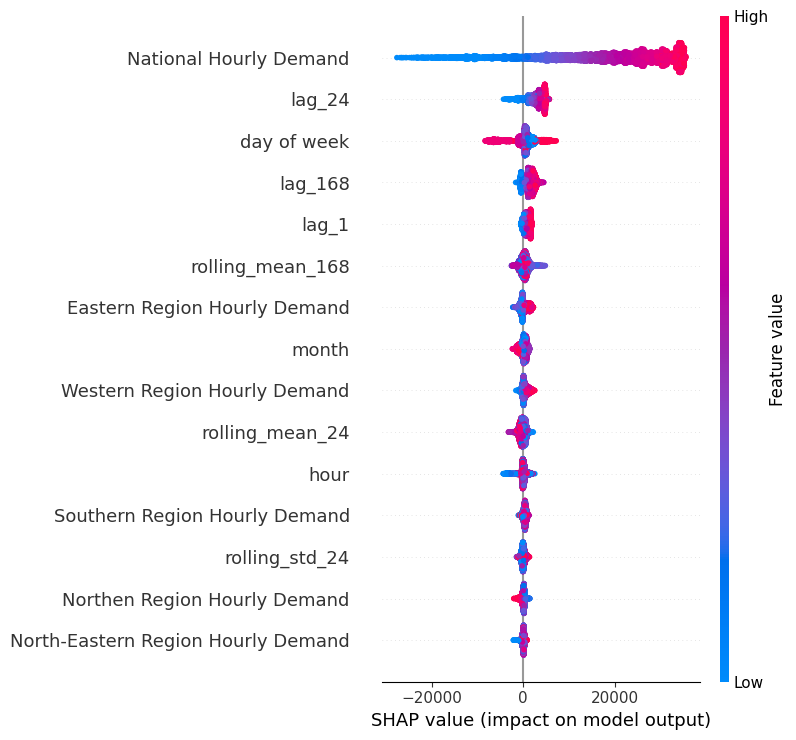

In [117]:
explainer = shap.TreeExplainer(model3)
shap_values = explainer.shap_values(X_val3)

shap.summary_plot(shap_values, X_val3)

In [118]:
X_train4 = train_dfx[['Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand','hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]
X_val4 = val_dfx[['Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand','hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']]

y_train4 = train_dfx['target']
y_val4 = val_dfx['target']

with mlflow.start_run(run_name="model2_xgb_wRegions"):

    model4 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model4.fit(X_train4, y_train4)

    # Predictions
    y_pred_val4 = model4.predict(X_val4)

    # Metrics
    rmse = mean_squared_error(y_val4, y_pred_val4) ** 0.5
    mae = mean_absolute_error(y_val4, y_pred_val4)
    mape = mean_absolute_percentage_error(y_val4, y_pred_val4) * 100
    r2 = r2_score(y_val4, y_pred_val4)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model4,
        artifact_path="model"
    )


2026/06/02 10:52:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model2_xgb_wRegions at: http://127.0.0.1:5000/#/experiments/1/runs/5a64197b22a64d0ab052185aaa17279f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# **Feature Engineering (Redux)**

In [119]:
import requests

def fetch_openmeteo(city_name, lat, lon, start="2019-01-01", end="2024-04-30"):
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "hourly": "temperature_2m",
        "timezone": "Asia/Kolkata"
    }

    r = requests.get(url, params=params)
    data = r.json()

    df = pd.DataFrame({
        "datetime": pd.to_datetime(data["hourly"]["time"]),
        f"temp_{city_name}": data["hourly"]["temperature_2m"]
    })

    return df


cities = {
    "delhi": (28.61, 77.20),
    "mumbai": (19.07, 72.88),
    "chennai": (13.08, 80.27),
    "kolkata": (22.57, 88.36),
    "guwahati": (26.18, 91.74)
}

dfs = []

for city, (lat, lon) in cities.items():
    df_city = fetch_openmeteo(city, lat, lon)
    dfs.append(df_city)

from functools import reduce

weather = reduce(lambda left, right: pd.merge(left, right, on="datetime", how="outer"), dfs)
weather = weather.sort_values("datetime")

print(weather.head())
print(weather.isna().sum())
print(weather.shape)

             datetime  temp_delhi  temp_mumbai  temp_chennai  temp_kolkata  \
0 2019-01-01 00:00:00         8.8         17.3          22.2          12.9   
1 2019-01-01 01:00:00         8.1         18.0          21.9          12.8   
2 2019-01-01 02:00:00         7.6         18.1          21.6          12.2   
3 2019-01-01 03:00:00         7.2         16.6          21.4          11.6   
4 2019-01-01 04:00:00         7.1         15.4          21.4          11.1   

   temp_guwahati  
0           12.6  
1           12.1  
2           11.1  
3           10.1  
4            9.6  
datetime         0
temp_delhi       0
temp_mumbai      0
temp_chennai     0
temp_kolkata     0
temp_guwahati    0
dtype: int64
(46728, 6)


In [120]:
df_x = df_x.merge(weather, on="datetime", how="left")

df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46536 entries, 0 to 46535
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   datetime                            46536 non-null  datetime64[ns]
 1   National Hourly Demand              46536 non-null  float64       
 2   Northen Region Hourly Demand        46536 non-null  float64       
 3   Western Region Hourly Demand        46536 non-null  float64       
 4   Eastern Region Hourly Demand        46536 non-null  float64       
 5   Southern Region Hourly Demand       46536 non-null  float64       
 6   North-Eastern Region Hourly Demand  46536 non-null  float64       
 7   year                                46536 non-null  int32         
 8   month                               46536 non-null  int32         
 9   hour                                46536 non-null  int32         
 10  day of week           

In [121]:
T_base = 18

# CDD (Cooling Degree Days): Measures how much and for how long the outdoor temperature climbs above the baseline. A higher CDD value indicates hotter weather and heavier air-conditioning usage.
for city in ["delhi", "mumbai", "chennai", "kolkata", "guwahati"]:
    col = f"temp_{city}"
    df_x[f"cdd_{city}"] = (df_x[col] - T_base).clip(lower=0)

# HDD (Heating Degree Days): Measures how much and for how long the outdoor temperature drops below the baseline. A higher HDD value indicates colder weather and increased furnace/heater usage to maintain indoor comfort.
for city in ["delhi", "mumbai", "chennai", "kolkata", "guwahati"]:
    col = f"temp_{city}"
    df_x[f"hdd_{city}"] = (T_base - df_x[col]).clip(lower=0)

In [122]:
# cyclic variables for periodic features
df_x['hour_sin'] = np.sin(2 * np.pi * df_x['hour']/24.0)
df_x['hour_cos'] = np.cos(2 * np.pi * df_x['hour']/24.0)

df_x['day_sin'] = np.sin(2 * np.pi * df_x['day of week']/7.0)
df_x['day_cos'] = np.cos(2 * np.pi * df_x['day of week']/7.0)

df_x['month_sin'] = np.sin(2 * np.pi * df_x['month']/12.0)
df_x['month_cos'] = np.cos(2 * np.pi * df_x['month']/12.0)

In [123]:
# weighted HDD/CDD by population + industrialization of different regions

weights = {
    "delhi": 0.25,
    "mumbai": 0.25,
    "chennai": 0.20,
    "kolkata": 0.20,
    "guwahati": 0.10
}

df_x["india_cdd"] = sum(
    df_x[f"cdd_{city}"] * w
    for city, w in weights.items()
)

df_x["india_hdd"] = sum(
    df_x[f"hdd_{city}"] * w
    for city, w in weights.items()
)

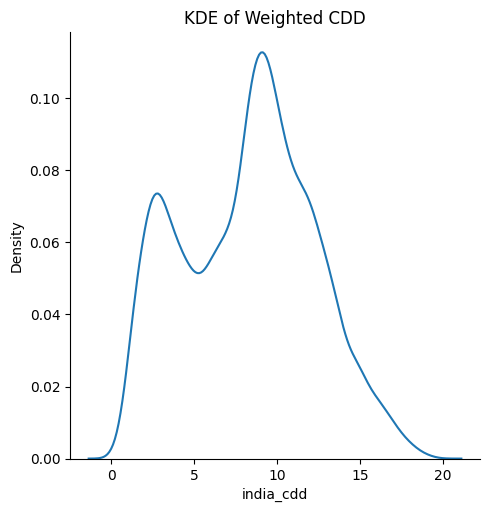

In [124]:
sns.displot(x='india_cdd', data=df_x, kind='kde')
plt.title('KDE of Weighted CDD')
plt.show()

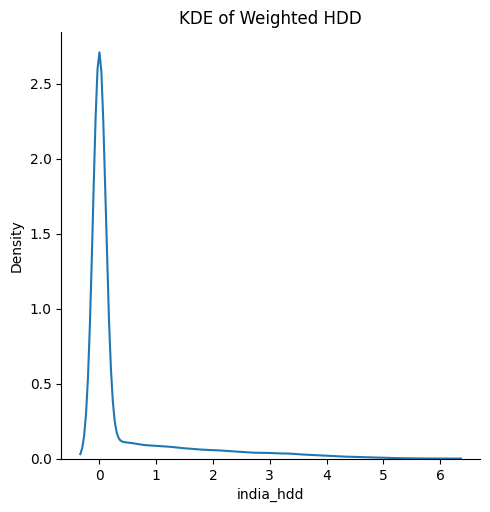

In [125]:
sns.displot(x='india_hdd', data=df_x, kind='kde')
plt.title('KDE of Weighted HDD')
plt.show()

In [126]:
df_x["india_cdd_sq"] = df_x["india_cdd"] ** 2

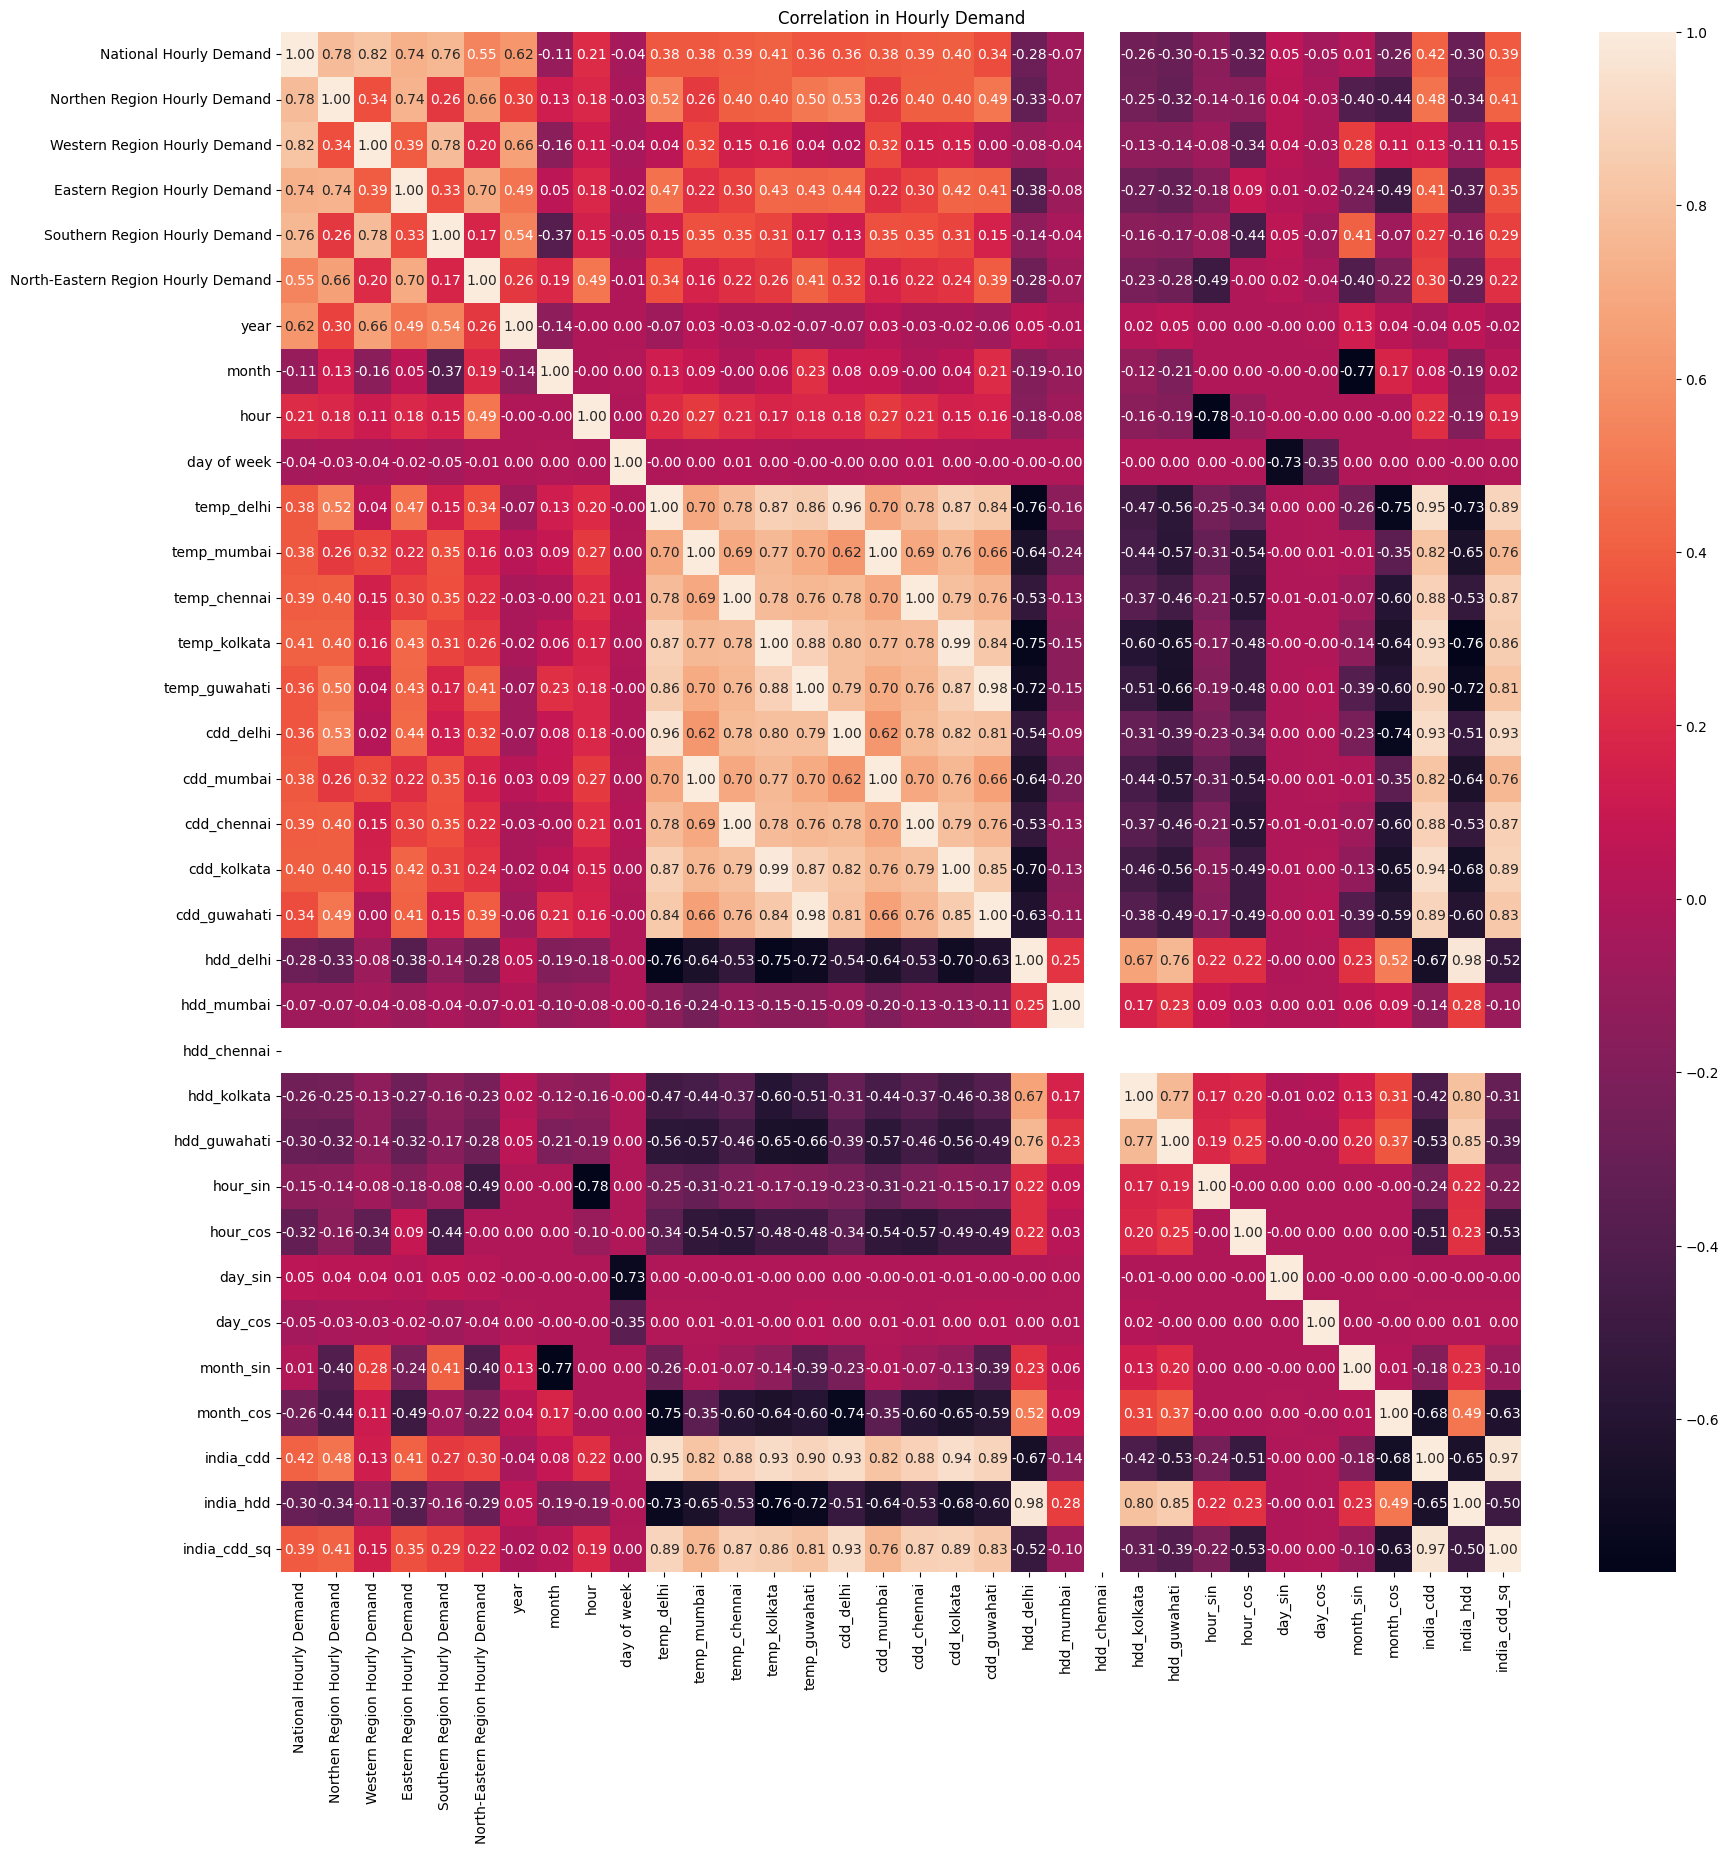

In [127]:
plt.figure(figsize = (20,20))
sns.heatmap((df_x.drop({'datetime','Season','target','lag_1', 'lag_24', 'lag_168','rolling_mean_24', 'rolling_mean_168', 'rolling_std_24'},axis=1)).corr(), fmt='1.2f', annot=True)
plt.title('Correlation in Hourly Demand')
plt.show()


In [128]:
df_x.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'year', 'month', 'hour', 'day of week', 'Season', 'target', 'lag_1',
       'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168',
       'rolling_std_24', 'temp_delhi', 'temp_mumbai', 'temp_chennai',
       'temp_kolkata', 'temp_guwahati', 'cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'india_cdd',
       'india_hdd', 'india_cdd_sq'],
      dtype='object')

# **National Forecasts (Raw Weather)**

In [129]:
df_rw = df_x.copy()

df_rw.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'year', 'month', 'hour', 'day of week', 'Season', 'target', 'lag_1',
       'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168',
       'rolling_std_24', 'temp_delhi', 'temp_mumbai', 'temp_chennai',
       'temp_kolkata', 'temp_guwahati', 'cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'india_cdd',
       'india_hdd', 'india_cdd_sq'],
      dtype='object')

In [130]:
df_rw.drop({'year', 'month', 'hour', 'day of week', 'Season','cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'india_hdd', 'india_cdd','india_cdd_sq'},inplace=True,axis=1)

df_rw.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'target', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
       'rolling_mean_168', 'rolling_std_24', 'temp_delhi', 'temp_mumbai',
       'temp_chennai', 'temp_kolkata', 'temp_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos'],
      dtype='object')

In [131]:
train_dfrw = df_rw[df_rw["datetime"] < "2023-01-01"]

val_dfrw = df_rw[
    (df_rw["datetime"] >= "2023-01-01") &
    (df_rw["datetime"] < "2024-01-01")
]

test_dfrw = df_rw[df_rw["datetime"] >= "2024-01-01"]

In [132]:
X_train5 = train_dfrw.drop({'target','datetime'},axis=1)
X_val5 = val_dfrw.drop({'target','datetime'},axis=1)

y_train5 = train_dfrw.target
y_val5 = val_dfrw.target

with mlflow.start_run(run_name="model3_xgb_wRawWeather"):

    model5 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model5.fit(X_train5, y_train5)

    # Predictions
    y_pred_val5 = model5.predict(X_val5)

    # Metrics
    rmse = mean_squared_error(y_val5, y_pred_val5) ** 0.5
    mae = mean_absolute_error(y_val5, y_pred_val5)
    mape = mean_absolute_percentage_error(y_val5, y_pred_val5) * 100
    r2 = r2_score(y_val5, y_pred_val5)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model5,
        artifact_path="model"
    )

2026/06/02 10:52:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model3_xgb_wRawWeather at: http://127.0.0.1:5000/#/experiments/1/runs/3eba9aa9ce4e45ee8ff634d586a4291d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# **National Forecasts (Engineered Features)**

In [133]:
df_ef = df_x.copy()

df_ef.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'year', 'month', 'hour', 'day of week', 'Season', 'target', 'lag_1',
       'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168',
       'rolling_std_24', 'temp_delhi', 'temp_mumbai', 'temp_chennai',
       'temp_kolkata', 'temp_guwahati', 'cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'india_cdd',
       'india_hdd', 'india_cdd_sq'],
      dtype='object')

In [134]:
df_ef.drop({'year', 'month', 'hour', 'day of week', 'Season','temp_delhi', 'temp_mumbai', 'temp_chennai',
       'temp_kolkata', 'temp_guwahati'},inplace=True,axis=1)

df_ef.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'target', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
       'rolling_mean_168', 'rolling_std_24', 'cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'india_cdd',
       'india_hdd', 'india_cdd_sq'],
      dtype='object')

In [135]:
train_dfef = df_ef[df_ef["datetime"] < "2023-01-01"]

val_dfef = df_ef[
    (df_ef["datetime"] >= "2023-01-01") &
    (df_ef["datetime"] < "2024-01-01")
]

test_dfef = df_ef[df_ef["datetime"] >= "2024-01-01"]

In [136]:
X_train6 = train_dfef.drop({'target','datetime'},axis=1)
X_val6 = val_dfef.drop({'target','datetime'},axis=1)

y_train6 = train_dfef.target
y_val6 = val_dfef.target

with mlflow.start_run(run_name="model4_xgb_wEngineeredFeatures"):

    model6 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model6.fit(X_train6, y_train6)

    # Predictions
    y_pred_val6 = model6.predict(X_val6)

    # Metrics
    rmse = mean_squared_error(y_val6, y_pred_val6) ** 0.5
    mae = mean_absolute_error(y_val6, y_pred_val6)
    mape = mean_absolute_percentage_error(y_val6, y_pred_val6) * 100
    r2 = r2_score(y_val6, y_pred_val6)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model6,
        artifact_path="model"
    )

2026/06/02 10:52:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model4_xgb_wEngineeredFeatures at: http://127.0.0.1:5000/#/experiments/1/runs/6634c006b3884e94b3f7a463ebbed60b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# **National Forecasts (Featured Weather)**

In [137]:
df_fw = df_x.copy()

df_fw.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'year', 'month', 'hour', 'day of week', 'Season', 'target', 'lag_1',
       'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168',
       'rolling_std_24', 'temp_delhi', 'temp_mumbai', 'temp_chennai',
       'temp_kolkata', 'temp_guwahati', 'cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'india_cdd',
       'india_hdd', 'india_cdd_sq'],
      dtype='object')

In [138]:
df_fw.drop({'year', 'month', 'hour', 'day of week', 'Season','temp_delhi', 'temp_mumbai', 'temp_chennai',
       'temp_kolkata', 'temp_guwahati','cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati'},inplace=True,axis=1)

df_fw.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'target', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
       'rolling_mean_168', 'rolling_std_24', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'india_cdd', 'india_hdd',
       'india_cdd_sq'],
      dtype='object')

In [139]:
train_dffw = df_fw[df_fw["datetime"] < "2023-01-01"]

val_dffw = df_fw[
    (df_fw["datetime"] >= "2023-01-01") &
    (df_fw["datetime"] < "2024-01-01")
]

test_dffw = df_fw[df_fw["datetime"] >= "2024-01-01"]

In [140]:
X_train7 = train_dffw.drop({'target','datetime'},axis=1)
X_val7 = val_dffw.drop({'target','datetime'},axis=1)

y_train7 = train_dffw.target
y_val7 = val_dffw.target

with mlflow.start_run(run_name="model5_xgb_wFeaturedWeather"):

    model7 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model7.fit(X_train7, y_train7)

    # Predictions
    y_pred_val7 = model7.predict(X_val7)

    # Metrics
    rmse = mean_squared_error(y_val7, y_pred_val7) ** 0.5
    mae = mean_absolute_error(y_val7, y_pred_val7)
    mape = mean_absolute_percentage_error(y_val7, y_pred_val7) * 100
    r2 = r2_score(y_val7, y_pred_val7)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model7,
        artifact_path="model"
    )

2026/06/02 10:52:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model5_xgb_wFeaturedWeather at: http://127.0.0.1:5000/#/experiments/1/runs/dd2710d5703b446c891625098da3e806
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# **National Forecasts (Full Diagnostics)**

In [141]:
df_full = df_x.copy()

df_full.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'year', 'month', 'hour', 'day of week', 'Season', 'target', 'lag_1',
       'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168',
       'rolling_std_24', 'temp_delhi', 'temp_mumbai', 'temp_chennai',
       'temp_kolkata', 'temp_guwahati', 'cdd_delhi', 'cdd_mumbai',
       'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi', 'hdd_mumbai',
       'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'india_cdd',
       'india_hdd', 'india_cdd_sq'],
      dtype='object')

In [142]:
df_full.drop({'year', 'month', 'hour', 'day of week', 'Season'},inplace=True,axis=1)

df_full.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'target', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
       'rolling_mean_168', 'rolling_std_24', 'temp_delhi', 'temp_mumbai',
       'temp_chennai', 'temp_kolkata', 'temp_guwahati', 'cdd_delhi',
       'cdd_mumbai', 'cdd_chennai', 'cdd_kolkata', 'cdd_guwahati', 'hdd_delhi',
       'hdd_mumbai', 'hdd_chennai', 'hdd_kolkata', 'hdd_guwahati', 'hour_sin',
       'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'india_cdd',
       'india_hdd', 'india_cdd_sq'],
      dtype='object')

In [143]:
train_full = df_full[df_full["datetime"] < "2023-01-01"]

val_full = df_full[
    (df_full["datetime"] >= "2023-01-01") &
    (df_full["datetime"] < "2024-01-01")
]

test_full = df_full[df_full["datetime"] >= "2024-01-01"]

In [144]:
X_train8 = train_full.drop({'target','datetime'},axis=1)
X_val8 = val_full.drop({'target','datetime'},axis=1)

y_train8 = train_full.target
y_val8 = val_full.target

with mlflow.start_run(run_name="model6_xgb_Full"):

    model8 = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )

    model8.fit(X_train8, y_train8)

    # Predictions
    y_pred_val8 = model8.predict(X_val8)

    # Metrics
    rmse = mean_squared_error(y_val8, y_pred_val8) ** 0.5
    mae = mean_absolute_error(y_val8, y_pred_val8)
    mape = mean_absolute_percentage_error(y_val8, y_pred_val8) * 100
    r2 = r2_score(y_val8, y_pred_val8)

    # Log parameters
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    # Log metrics
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.xgboost.log_model(
        xgb_model=model8,
        artifact_path="model"
    )

2026/06/02 10:53:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run model6_xgb_Full at: http://127.0.0.1:5000/#/experiments/1/runs/83cd57398d7c45378b9667679741e8d0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# **Summary & Diagnostics** 

In [145]:
importance = pd.DataFrame({
    "feature": X_val3.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(importance.head(15))

                               feature  mean_abs_shap
0               National Hourly Demand   20823.529297
9                               lag_24    3250.940674
7                          day of week    1873.143555
11                             lag_168    1446.331177
10                               lag_1     841.518066
13                    rolling_mean_168     687.168396
3         Eastern Region Hourly Demand     639.916870
8                                month     542.108276
2         Western Region Hourly Demand     535.926514
12                     rolling_mean_24     505.001892
6                                 hour     427.808441
4        Southern Region Hourly Demand     411.224915
14                      rolling_std_24     287.327026
1         Northen Region Hourly Demand     278.351318
5   North-Eastern Region Hourly Demand     207.363739


In [146]:
pred = model3.predict(test_dfx[['National Hourly Demand','Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand','hour', 'day of week', 'month', 'lag_24', 'lag_1', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_std_24']])

In [147]:
actual = test_dfx.target

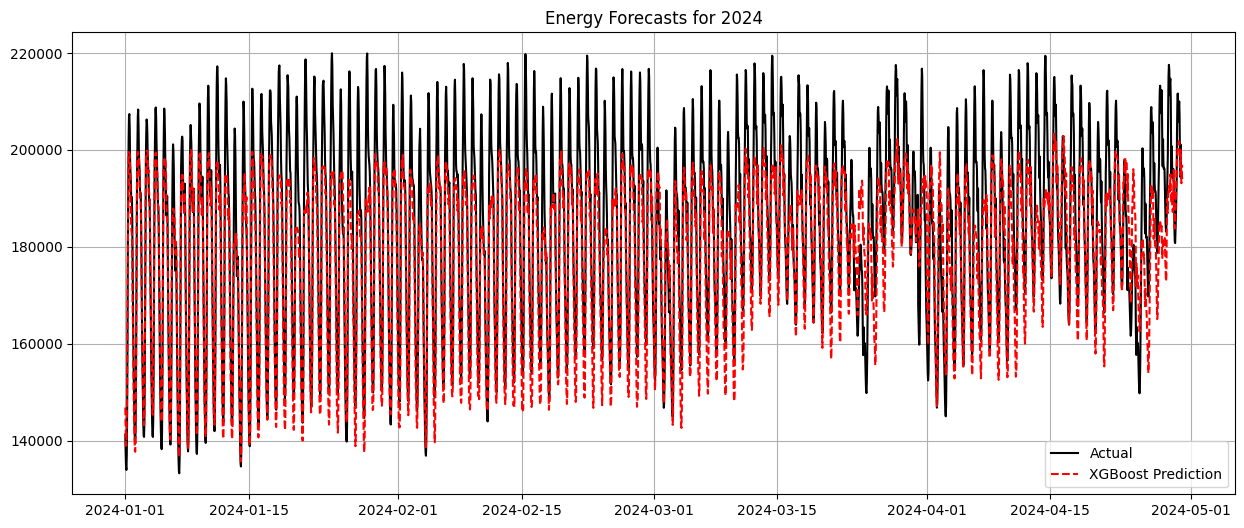

In [148]:
plt.figure(figsize=(15,6))
plt.plot(test_dfx["datetime"], actual, label="Actual", color = 'black')
plt.plot(test_dfx["datetime"], pred,label="XGBoost Prediction", color='red', linestyle='--')
plt.legend()
plt.grid()
plt.title('Energy Forecasts for 2024')
plt.show()

In [149]:
mape = mean_absolute_percentage_error(actual, pred) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 3.87%


In [150]:
pred_raw = model5.predict(test_dfrw.drop({'target','datetime'},axis=1))

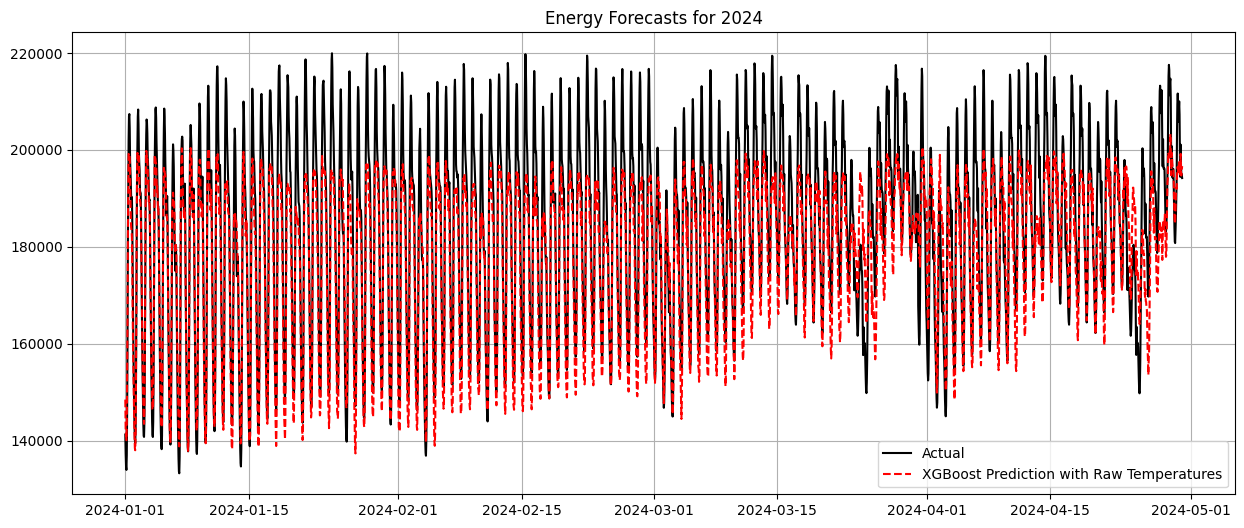

In [151]:
plt.figure(figsize=(15,6))
plt.plot(test_dfx["datetime"], actual, label="Actual", color = 'black')
plt.plot(test_dfx["datetime"], pred_raw,label="XGBoost Prediction with Raw Temperatures", color='red', linestyle='--')
plt.legend()
plt.grid()
plt.title('Energy Forecasts for 2024')
plt.show()

In [152]:
mape = mean_absolute_percentage_error(actual, pred_raw) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 3.92%


# **Scenario Aware Modelling**

## **Heatwave: +2°C/+0°C/+4°C**

In [235]:
df_rw.columns

Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand',
       'target', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
       'rolling_mean_168', 'rolling_std_24', 'temp_delhi', 'temp_mumbai',
       'temp_chennai', 'temp_kolkata', 'temp_guwahati', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos'],
      dtype='object')

In [250]:
def build_features(df):
    df = df.copy()

    df["lag_1"] = df["National Hourly Demand"].shift(1)
    df["lag_24"] = df["National Hourly Demand"].shift(24)
    df["lag_168"] = df["National Hourly Demand"].shift(168)

    df["rolling_mean_24"] = df["National Hourly Demand"].rolling(24).mean()
    df["rolling_mean_168"] = df["National Hourly Demand"].rolling(168).mean()
    df["rolling_std_24"] = df["National Hourly Demand"].rolling(24).std()

    return df


def add_time_features(df):
    df = df.copy()

    dt = df["datetime"]

    df["hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)

    df["day_sin"] = np.sin(2 * np.pi * dt.dt.dayofweek / 7)
    df["day_cos"] = np.cos(2 * np.pi * dt.dt.dayofweek / 7)

    df["month_sin"] = np.sin(2 * np.pi * dt.dt.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * dt.dt.month / 12)

    return df

In [251]:
def run_simulation(df_base, delta_temp):

    df = df_base.copy().sort_values("datetime").reset_index(drop=True)

    # apply scenario shock
    df[temp_cols] = df[temp_cols] + delta_temp

    preds = []

    for t in range(HORIZON):

        df_feat = add_time_features(df)
        df_feat = build_features(df_feat)

        X = df_feat.iloc[-1][feature_cols].values.reshape(1, -1)
        y_hat = model5.predict(X)[0]

        new_row = df.iloc[-1].copy()
        new_row["National Hourly Demand"] = y_hat
        new_row["datetime"] = new_row["datetime"] + pd.Timedelta(hours=1)

        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

        preds.append(y_hat)

    return df, preds

In [252]:
df_sim, predictions_2 = run_simulation(df_rw, delta_temp=2)
df_simno, predictions_0 = run_simulation(df_rw, delta_temp=0)
df_simmax, predictions_4 = run_simulation(df_rw, delta_temp=4)

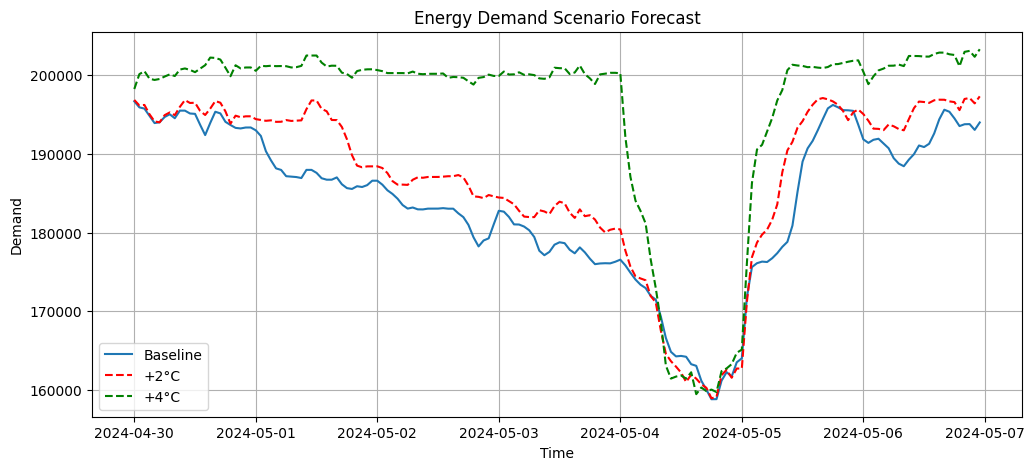

In [255]:
plt.figure(figsize=(12,5))

plt.plot(df_simno["datetime"].iloc[-168:], df_simno["National Hourly Demand"].iloc[-168:], label="Baseline")

plt.plot(df_sim["datetime"].iloc[-168:], df_sim["National Hourly Demand"].iloc[-168:], label="+2°C", color='red', linestyle="--")

plt.plot(df_simmax["datetime"].iloc[-168:], df_simmax["National Hourly Demand"].iloc[-168:], label="+4°C", color='green',linestyle="--")

plt.legend()
plt.title("Energy Demand Scenario Forecast")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.grid()
plt.show()

In [259]:
def compare_scenarios(df_base, df_2, df_4):
    
    base = df_base["National Hourly Demand"].values[-HORIZON:]
    s2 = df_2["National Hourly Demand"].values[-HORIZON:]
    s4 = df_4["National Hourly Demand"].values[-HORIZON:]

    results = pd.DataFrame({
        "metric": [
            "mean_demand",
            "peak_demand",
            "min_demand",
            "peak_to_mean_ratio"
        ],
        "baseline": [
            base.mean(),
            base.max(),
            base.min(),
            base.max() / base.mean()
        ],
        "+2C": [
            s2.mean(),
            s2.max(),
            s2.min(),
            s2.max() / s2.mean()
        ],
        "+4C": [
            s4.mean(),
            s4.max(),
            s4.min(),
            s4.max() / s4.mean()
        ]
    })

    return results

print(compare_scenarios(df_simno, df_sim, df_simmax))

               metric       baseline            +2C            +4C
0         mean_demand  183871.111421  186868.947452  195627.443266
1         peak_demand  196662.250000  197294.171875  203274.546875
2          min_demand  158846.500000  158965.671875  159488.859375
3  peak_to_mean_ratio       1.069566       1.055789       1.039090


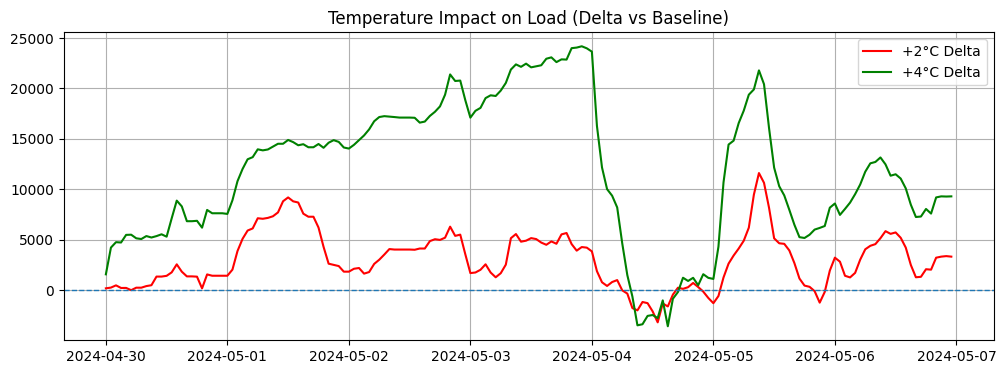

In [262]:
plt.figure(figsize=(12,4))

plt.plot(
    df_sim["datetime"].iloc[-168:],
    df_sim["National Hourly Demand"].iloc[-168:] - df_simno["National Hourly Demand"].iloc[-168:],
    label="+2°C Delta", color='red'
)

plt.plot(
    df_simmax["datetime"].iloc[-168:],
    df_simmax["National Hourly Demand"].iloc[-168:] - df_simno["National Hourly Demand"].iloc[-168:],
    label="+4°C Delta", color='green'
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.title("Temperature Impact on Load (Delta vs Baseline)")
plt.grid()
plt.show()

## **Coldwave: -2°C/+0°C/-4°C**

In [256]:
df_sim2, predictions_2neg = run_simulation(df_rw, delta_temp=-2)
df_simno2, predictions_0neg = run_simulation(df_rw, delta_temp=0)
df_simmax2, predictions_4neg = run_simulation(df_rw, delta_temp=-4)

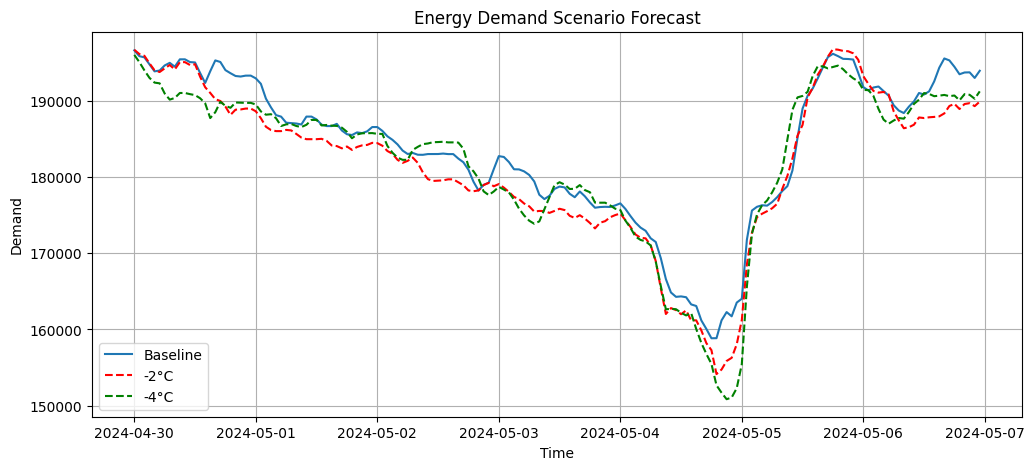

In [257]:
plt.figure(figsize=(12,5))

plt.plot(df_simno2["datetime"].iloc[-168:], df_simno2["National Hourly Demand"].iloc[-168:], label="Baseline")

plt.plot(df_sim2["datetime"].iloc[-168:], df_sim2["National Hourly Demand"].iloc[-168:], label="-2°C", color='red', linestyle="--")

plt.plot(df_simmax2["datetime"].iloc[-168:], df_simmax2["National Hourly Demand"].iloc[-168:], label="-4°C", color='green',linestyle="--")

plt.legend()
plt.title("Energy Demand Scenario Forecast")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.grid()
plt.show()

In [263]:
print(compare_scenarios(df_simno2, df_sim2, df_simmax2))

               metric       baseline            +2C            +4C
0         mean_demand  183871.111421  181744.668899  182252.740978
1         peak_demand  196662.250000  196806.062500  196061.656250
2          min_demand  158846.500000  154139.968750  150839.875000
3  peak_to_mean_ratio       1.069566       1.082871       1.075768


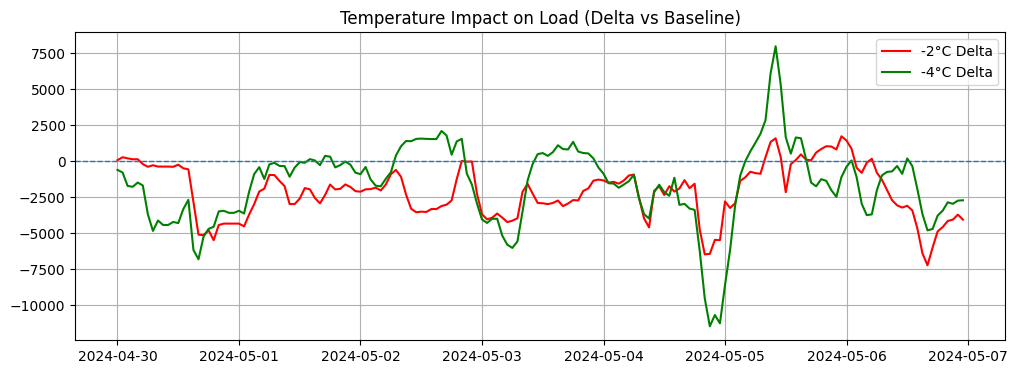

In [264]:
plt.figure(figsize=(12,4))

plt.plot(
    df_sim2["datetime"].iloc[-168:],
    df_sim2["National Hourly Demand"].iloc[-168:] - df_simno2["National Hourly Demand"].iloc[-168:],
    label="-2°C Delta", color='red'
)

plt.plot(
    df_simmax2["datetime"].iloc[-168:],
    df_simmax2["National Hourly Demand"].iloc[-168:] - df_simno2["National Hourly Demand"].iloc[-168:],
    label="-4°C Delta", color='green'
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.title("Temperature Impact on Load (Delta vs Baseline)")
plt.grid()
plt.show()